In [35]:
import os, sys, json, shutil, traceback, subprocess, re, gzip
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import signal

from pathlib import Path
from pprint import pprint
from spm import spm_file_split

In [4]:
## Pre-Defs

WORK_NAME = "M01_ds003768"

DATA_ROOT = Path("/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768")
RESULTS_ROOT = DATA_ROOT.parent / "rsCVR_Results"
WORK_ROOT = RESULTS_ROOT / WORK_NAME

INDEX_DIR = WORK_ROOT / "index"
LOG_DIR = WORK_ROOT / "logs"
QC_DIR = WORK_ROOT / "qc"
RAPIDTIDE_DIR = WORK_ROOT / "rapidtide"
SPM_DIR = WORK_ROOT / "spm_preproc"
SUMMARY_DIR = WORK_ROOT / "summary"
MANIFEST_DIR = WORK_ROOT / "manifests"

for d in [RESULTS_ROOT, WORK_ROOT, INDEX_DIR, LOG_DIR, QC_DIR, RAPIDTIDE_DIR, SPM_DIR, SUMMARY_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT   :", DATA_ROOT)
print("WORK_ROOT   :", WORK_ROOT)

DATA_ROOT   : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768
WORK_ROOT   : /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768


In [5]:
# Defs
def load_json_safe(p):
    p = Path(p)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj, p):
    p = Path(p)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def nifti_info(p):
    img = nib.load(str(p))
    shape = img.shape
    zooms = img.header.get_zooms()
    return {
        "shape": shape,
        "zooms": zooms,
        "ndim": len(shape),
    }

# Defs for QC
def save_mean_bold(bold_path, out_path):
    img = nib.load(str(bold_path))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim == 4:
        mean_data = data.mean(axis=-1)
    else:
        mean_data = data

    out_img = nib.Nifti1Image(mean_data, img.affine, img.header)
    nib.save(out_img, str(out_path))
    return out_path

def middle_slices(vol3d):
    x, y, z = vol3d.shape
    return vol3d[x//2, :, :], vol3d[:, y//2, :], vol3d[:, :, z//2]

def plot_orthogonal(vol3d, title="", out_png=None):
    sag, cor, axi = middle_slices(vol3d)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.rot90(sag), cmap="gray")
    axes[0].set_title("Sagittal")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(cor), cmap="gray")
    axes[1].set_title("Coronal")
    axes[1].axis("off")

    axes[2].imshow(np.rot90(axi), cmap="gray")
    axes[2].set_title("Axial")
    axes[2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

def plot_before_after_orthogonal(before_img_path, after_img_path, title="", out_png=None):
    before = nib.load(str(before_img_path)).get_fdata()
    after = nib.load(str(after_img_path)).get_fdata()

    b_sag, b_cor, b_axi = middle_slices(before)
    a_sag, a_cor, a_axi = middle_slices(after)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].imshow(np.rot90(b_sag), cmap="gray")
    axes[0, 0].set_title("Before - Sagittal")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(np.rot90(b_cor), cmap="gray")
    axes[0, 1].set_title("Before - Coronal")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(np.rot90(b_axi), cmap="gray")
    axes[0, 2].set_title("Before - Axial")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(np.rot90(a_sag), cmap="gray")
    axes[1, 0].set_title("After - Sagittal")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(np.rot90(a_cor), cmap="gray")
    axes[1, 1].set_title("After - Coronal")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(np.rot90(a_axi), cmap="gray")
    axes[1, 2].set_title("After - Axial")
    axes[1, 2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)


In [6]:
ALL_SUBJECTS = sorted([p.name for p in DATA_ROOT.glob("sub-*") if p.is_dir()])
TARGET_RUNS = ["run-1", "run-2"]

all_run_specs = []
missing_rows = []

for subject in ALL_SUBJECTS:
    subj_dir = DATA_ROOT / subject
    anat_dir = subj_dir / "anat"
    func_dir = subj_dir / "func"

    t1_nii = anat_dir / f"{subject}_T1w.nii.gz"
    t1_json = anat_dir / f"{subject}_T1w.json"

    for run in TARGET_RUNS:
        bold_nii = func_dir / f"{subject}_task-rest_{run}_bold.nii.gz"
        bold_json = func_dir / f"{subject}_task-rest_{run}_bold.json"

        missing = []
        if not t1_nii.exists():
            missing.append("t1_nii")
        if not t1_json.exists():
            missing.append("t1_json")
        if not bold_nii.exists():
            missing.append("bold_nii")
        if not bold_json.exists():
            missing.append("bold_json")

        if missing:
            missing_rows.append({
                "subject": subject,
                "run": run,
                "missing": ",".join(missing)
            })
            continue

        meta = load_json_safe(bold_json)

        spm_subject_root = SPM_DIR / subject
        spm_anat_dir = spm_subject_root / "anat"
        spm_run_dir = spm_subject_root / run

        rapidtide_subject_root = RAPIDTIDE_DIR / subject
        rapidtide_run_dir = rapidtide_subject_root / run

        qc_subject_root = QC_DIR / subject
        qc_run_dir = qc_subject_root / run

        for d in [spm_subject_root, spm_anat_dir, spm_run_dir,
                  rapidtide_subject_root, rapidtide_run_dir,
                  qc_subject_root, qc_run_dir]:
            d.mkdir(parents=True, exist_ok=True)

        spec = {
            "subject": subject,
            "run": run,
            "inputs": {
                "t1_nii": str(t1_nii),
                "t1_json": str(t1_json),
                "bold_nii": str(bold_nii),
                "bold_json": str(bold_json),
                "TR": float(meta.get("RepetitionTime")),
            },
            "outputs": {
                "spm_subject_root": str(spm_subject_root),
                "spm_anat_dir": str(spm_anat_dir),
                "spm_run_dir": str(spm_run_dir),
                "spm_preproc_bold": str(spm_run_dir / f"{subject}_{run}_preproc_bold.nii.gz"),
                "spm_motion_tsv": str(spm_run_dir / f"{subject}_{run}_motion.tsv"),
                "spm_brainmask": str(spm_run_dir / f"{subject}_{run}_brainmask.nii.gz"),
                "rapidtide_run_dir": str(rapidtide_run_dir),
                "rapidtide_output_root": str(rapidtide_run_dir / f"{subject}_{run}"),
                "qc_run_dir": str(qc_run_dir),
                "qc_summary_json": str(qc_run_dir / f"{subject}_{run}_qc_summary.json"),
                "t1_qc_png": str(qc_run_dir / f"{subject}_{run}_t1_orth.png"),
                "mean_bold_qc_png": str(qc_run_dir / f"{subject}_{run}_meanbold_orth.png"),
            },
            "derived_inputs": {
                "mean_bold": str(spm_run_dir / f"{subject}_{run}_mean_bold.nii.gz"),
            },
            "nifti_info": nifti_info(bold_nii),
        }
        all_run_specs.append(spec)

df_missing_specs = pd.DataFrame(missing_rows)
print("Total subjects:", len(ALL_SUBJECTS))
print("Total valid runs:", len(all_run_specs))
print("Missing rows:", len(df_missing_specs))
df_missing_specs

Total subjects: 33
Total valid runs: 66
Missing rows: 0


""


In [14]:
# Prepare BOLD imgs

def prepare_bold_for_spm(spec):
    spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
    src_gz = Path(spec["inputs"]["bold_nii"])

    local_gz = spm_run_dir / src_gz.name
    local_nii = spm_run_dir / src_gz.name.replace(".nii.gz", ".nii")

    shutil.copy2(src_gz, local_gz)

    if local_nii.exists():
        local_nii.unlink()

    with gzip.open(local_gz, "rb") as f_in, open(local_nii, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

    return {
        "local_gz": str(local_gz),
        "local_nii": str(local_nii),
    }

def split_4d_to_3d(local_nii: Path, out_dir: Path):
    local_nii = Path(local_nii)
    out_dir = Path(out_dir)

    stem = local_nii.stem
    for p in out_dir.glob(f"{stem}_*.nii"):
        p.unlink()

    spm_file_split(str(local_nii), str(out_dir))

    split_files = sorted(out_dir.glob(f"{stem}_*.nii"))
    if not split_files:
        raise RuntimeError(f"No split 3D files created from {local_nii}")

    return [str(p) for p in split_files]


# Batch writer
def write_spm_realign_estwrite_job(split_scans, job_m_path):
    split_scans = [str(Path(p)).replace("\\", "/") for p in split_scans]
    job_m_path = Path(job_m_path)

    scan_block = "\n".join([f"    '{p},1'" for p in split_scans])

    job_txt = f"""
matlabbatch{{1}}.spm.spatial.realign.estwrite.data{{1}} = {{
{scan_block}
}};

matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.quality = 0.9;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.sep = 4;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.fwhm = 5;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.rtm = 1;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.interp = 2;
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.wrap = [0 0 0];
matlabbatch{{1}}.spm.spatial.realign.estwrite.eoptions.weight = '';

matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.which = [2 1];
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.interp = 4;
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.wrap = [0 0 0];
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.mask = 1;
matlabbatch{{1}}.spm.spatial.realign.estwrite.roptions.prefix = 'r';

spm('defaults', 'fmri');
spm_jobman('initcfg');
spm_jobman('run', matlabbatch);
"""
    job_m_path.write_text(job_txt.strip() + "\n", encoding="utf-8")
    return job_m_path

# CLI Runner
def run_spm_job_via_cli(job_m_path, cwd=None):
    import os, sys, shutil
    from pathlib import Path

    job_m_path = Path(job_m_path)

    spm_exe = shutil.which("spm")

    if spm_exe is None:
        env_bin = Path(sys.executable).parent
        candidate = env_bin / "spm"
        if candidate.exists():
            spm_exe = str(candidate)

    if spm_exe is None:
        raise FileNotFoundError(
            f"SPM CLI executable not found. "
            f"sys.executable={sys.executable}, PATH={os.environ.get('PATH', '')}"
        )

    cmd = [spm_exe, "script", str(job_m_path)]

    out = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        cwd=cwd,
        check=False
    )
    return {
        "cmd": cmd,
        "spm_exe": spm_exe,
        "returncode": out.returncode,
        "stdout": out.stdout,
        "stderr": out.stderr,
    }

# 3D to 4D merging
def merge_3d_to_4d_nifti(realigned_files, out_path):
    realigned_files = [str(Path(p)) for p in realigned_files]
    imgs = [nib.load(p) for p in realigned_files]
    data = np.stack([img.get_fdata(dtype=np.float32) for img in imgs], axis=-1)

    out_path = Path(out_path)
    affine = imgs[0].affine
    header = imgs[0].header.copy()

    img4d = nib.Nifti1Image(data, affine, header=header)
    nib.save(img4d, str(out_path))
    return out_path

In [15]:
# Cleansing
def cleanup_spm_run_outputs(spec):
    run_dir = Path(spec["outputs"]["spm_run_dir"])

    for pattern in ["rp_*.txt", "r*.nii", "mean*.nii", "*_000*.nii", "*.mat", "*realign_estwrite_job.m"]:
        for p in run_dir.glob(pattern):
            try:
                p.unlink()
            except Exception:
                pass

    for p in [
        Path(spec["outputs"]["spm_motion_tsv"]),
        Path(spec["outputs"]["spm_preproc_bold"]),
    ]:
        if p.exists():
            try:
                p.unlink()
            except Exception:
                pass

In [16]:
# Execution

def run_spm_realign_trial(spec: dict, execute: bool = False, show_qc: bool = True):
    result = {
        "subject": spec["subject"],
        "run": spec["run"],
        "execute": execute,
        "success": False,
        "prepared_local_files": None,
        "generated_files": {},
        "qc_files": {},
        "error": None,
    }

    try:
        spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
        qc_run_dir = Path(spec["outputs"]["qc_run_dir"])
        qc_run_dir.mkdir(parents=True, exist_ok=True)

        prepared = prepare_bold_for_spm(spec)
        local_nii = Path(prepared["local_nii"])
        local_gz = Path(prepared["local_gz"])
        result["prepared_local_files"] = prepared

        pre_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_before_realign.nii.gz"
        save_mean_bold(local_nii, pre_mean_path)

        if not execute:
            img = nib.load(str(local_nii))
            result["generated_files"] = {
                "local_gz": str(local_gz),
                "local_nii": str(local_nii),
                "n_scans": int(img.shape[3]),
                "mean_before_realign": str(pre_mean_path),
            }
            result["success"] = True
            return result

        split_scans = split_4d_to_3d(local_nii, spm_run_dir)

        job_m_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_realign_estwrite_job.m"
        write_spm_realign_estwrite_job(split_scans, job_m_path)

        job_result = run_spm_job_via_cli(job_m_path, cwd=spm_run_dir)

        generated = {}
        generated["local_gz"] = str(local_gz)
        generated["local_nii"] = str(local_nii)
        generated["split_scans"] = split_scans
        generated["spm_job_m"] = str(job_m_path)
        generated["spm_job_returncode"] = job_result["returncode"]
        generated["spm_job_stdout_tail"] = job_result["stdout"][-3000:]
        generated["spm_job_stderr_tail"] = job_result["stderr"][-3000:]

        if job_result["returncode"] != 0:
            raise RuntimeError(
                f"SPM batch job failed\nSTDOUT:\n{job_result['stdout']}\nSTDERR:\n{job_result['stderr']}"
            )

        generated["realigned_files"] = sorted([str(p) for p in spm_run_dir.glob("r*.nii")])
        generated["mean_files"] = sorted([str(p) for p in spm_run_dir.glob("mean*.nii")])

        if len(generated["realigned_files"]) >= 1:
            dst_4d = Path(spec["outputs"]["spm_preproc_bold"])
            merge_3d_to_4d_nifti(generated["realigned_files"], dst_4d)
            generated["standard_preproc_bold"] = str(dst_4d)
        else:
            generated["standard_preproc_bold"] = None

        rp_candidates = sorted(spm_run_dir.glob("rp_*.txt"))
        generated["motion_files_txt"] = [str(p) for p in rp_candidates]

        motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
        if len(rp_candidates) == 1:
            df_motion = pd.read_csv(rp_candidates[0], sep=r"\s+", header=None)
            df_motion.columns = ["x", "y", "z", "pitch", "roll", "yaw"]
            df_motion.to_csv(motion_tsv, sep="\t", index=False)

            generated["standard_motion_tsv"] = str(motion_tsv)
            generated["motion_n_rows"] = int(df_motion.shape[0])
        else:
            generated["standard_motion_tsv"] = None
            generated["motion_n_rows"] = 0
            generated["motion_error"] = f"Expected exactly 1 rp_*.txt file, found {len(rp_candidates)}"

        qc_files = {}

        if len(generated["mean_files"]) == 1:
            post_mean_path = Path(generated["mean_files"][0])
            realign_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_realign_before_after.png"

            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_mean_path,
                title=f"{spec['subject']} {spec['run']} - Realign: Before vs After",
                out_png=realign_compare_png
            )
            qc_files["realign_before_after_png"] = str(realign_compare_png)

        if generated.get("standard_preproc_bold"):
            standard_preproc_bold = Path(generated["standard_preproc_bold"])
            post_reslice_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_after_reslice.nii.gz"
            save_mean_bold(standard_preproc_bold, post_reslice_mean_path)

            reslice_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_reslice_before_after.png"
            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_reslice_mean_path,
                title=f"{spec['subject']} {spec['run']} - Reslice: Before vs After",
                out_png=reslice_compare_png
            )
            qc_files["mean_after_reslice"] = str(post_reslice_mean_path)
            qc_files["reslice_before_after_png"] = str(reslice_compare_png)

        if show_qc:
            if pre_mean_path.exists():
                plot_orthogonal(
                    nib.load(str(pre_mean_path)).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean Before Realign"
                )

            if len(generated["mean_files"]) == 1:
                plot_orthogonal(
                    nib.load(generated["mean_files"][0]).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean After Realign"
                )

        result["generated_files"] = generated
        result["qc_files"] = qc_files

        result["success"] = (
            generated["spm_job_returncode"] == 0
            and len(generated["realigned_files"]) >= 1
            and len(generated["mean_files"]) == 1
            and len(generated["motion_files_txt"]) == 1
            and generated.get("motion_n_rows", 0) > 1
        )

        if not result["success"] and "motion_error" not in generated:
            generated["motion_error"] = "Run completed, but output structure did not match expected final form."

        return result

    except Exception:
        result["error"] = traceback.format_exc()
        return result

[1/66] sub-01 run-1
Initializing Matlab Runtime...


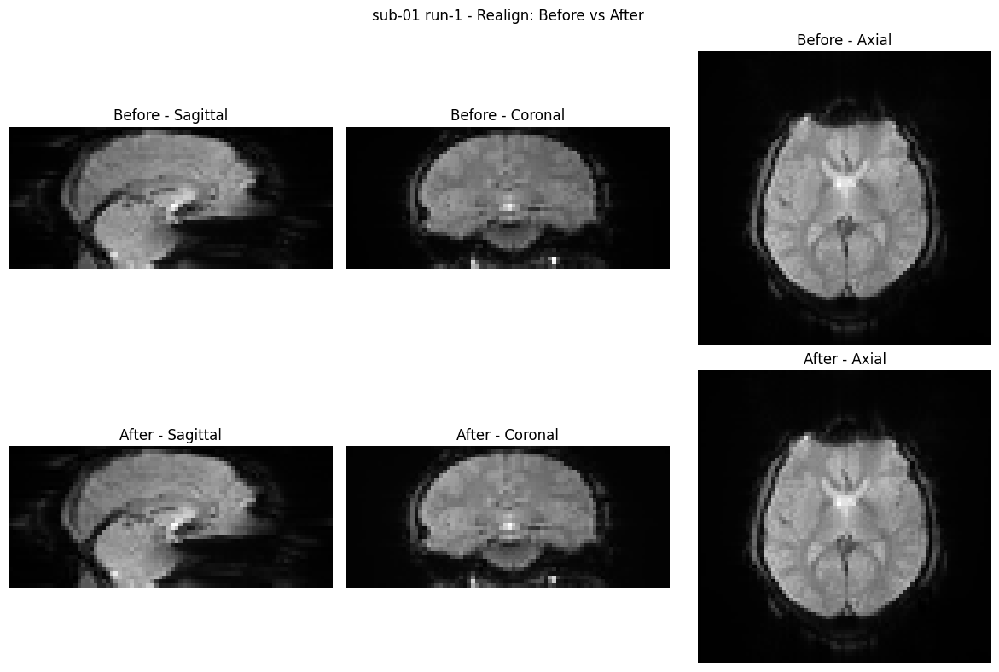

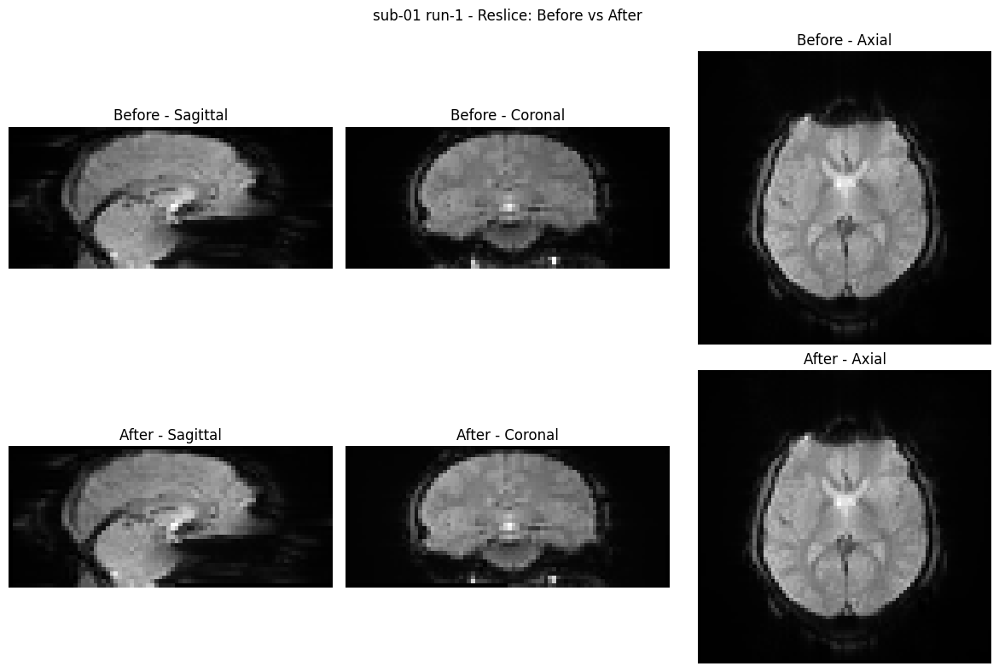

[2/66] sub-01 run-2


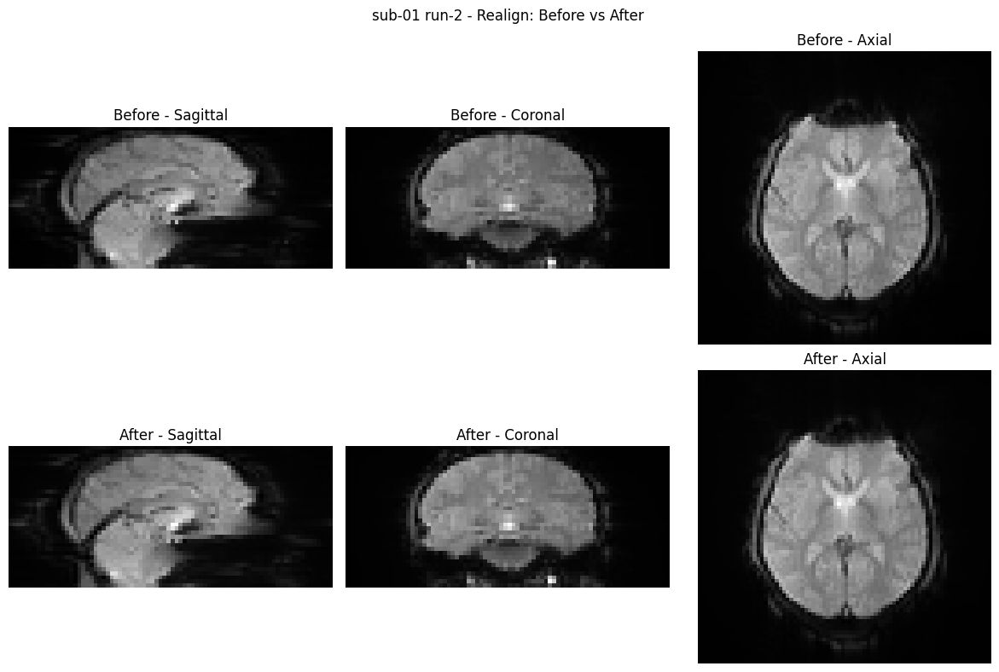

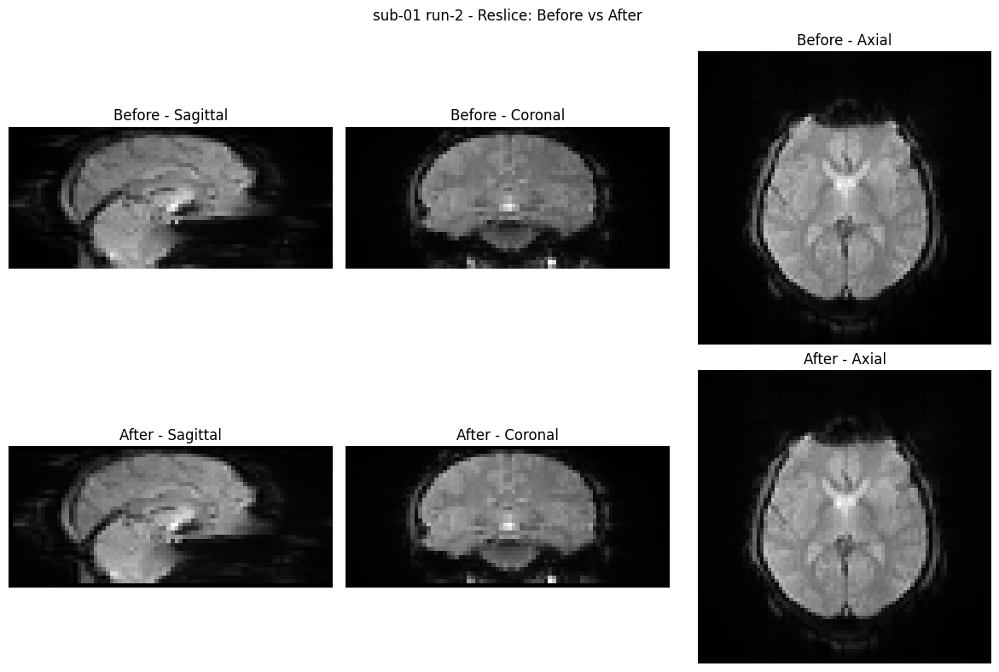

[3/66] sub-02 run-1


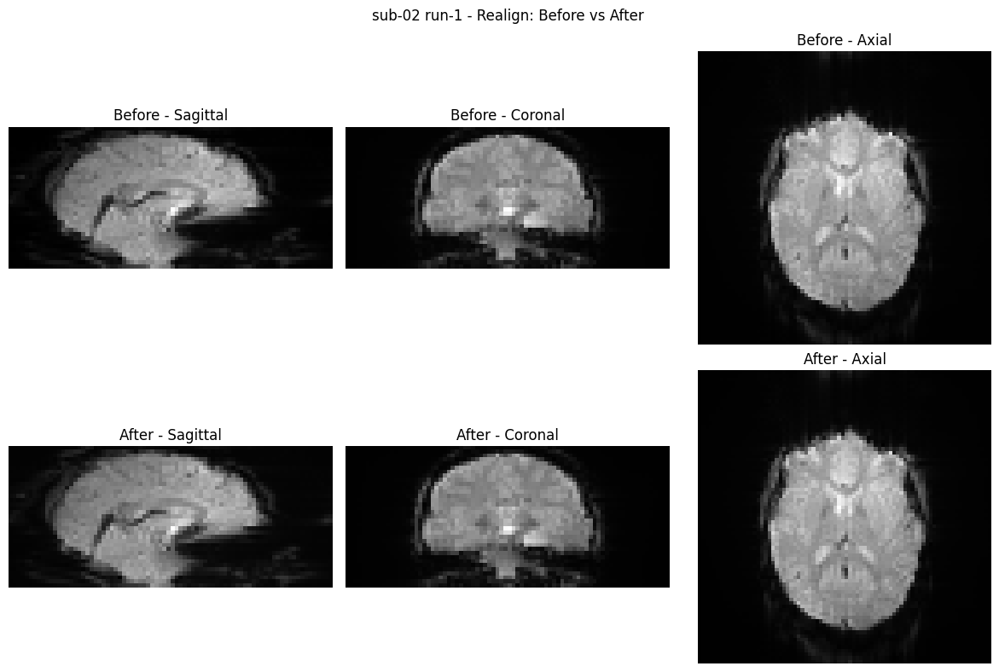

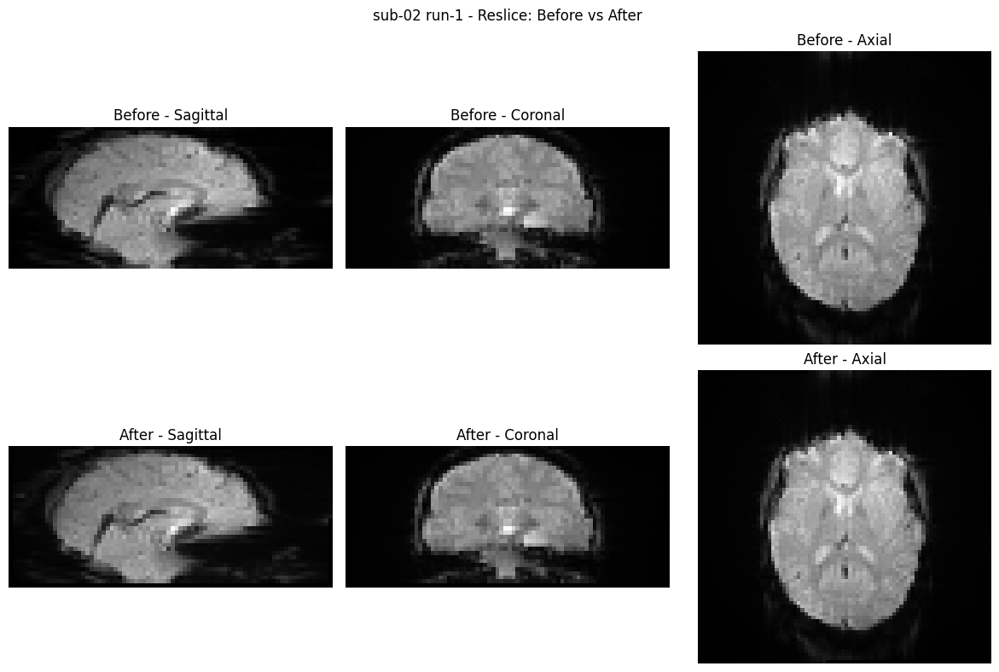

[4/66] sub-02 run-2


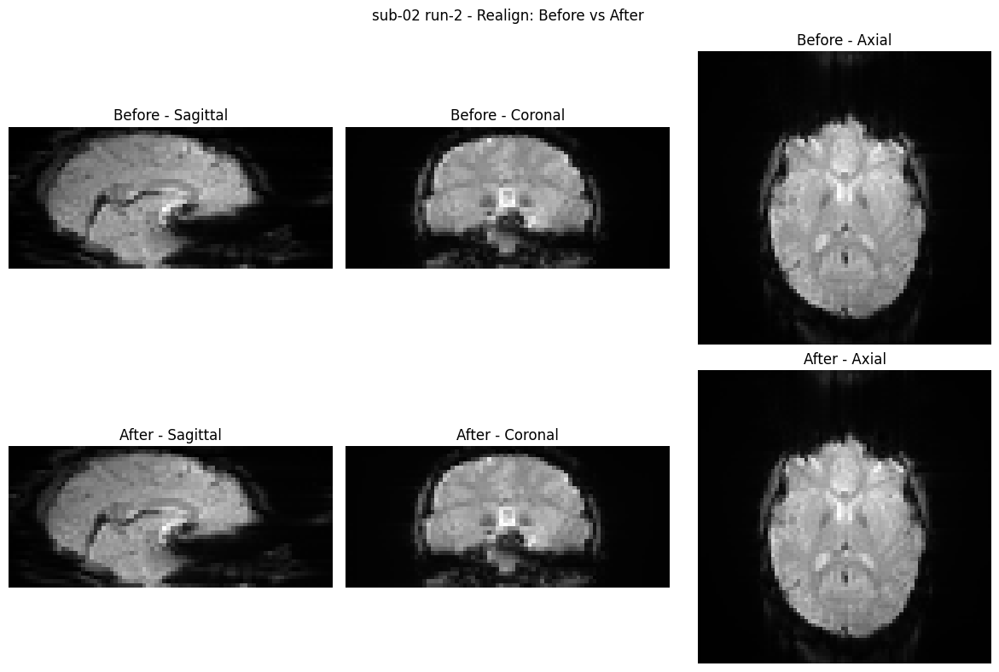

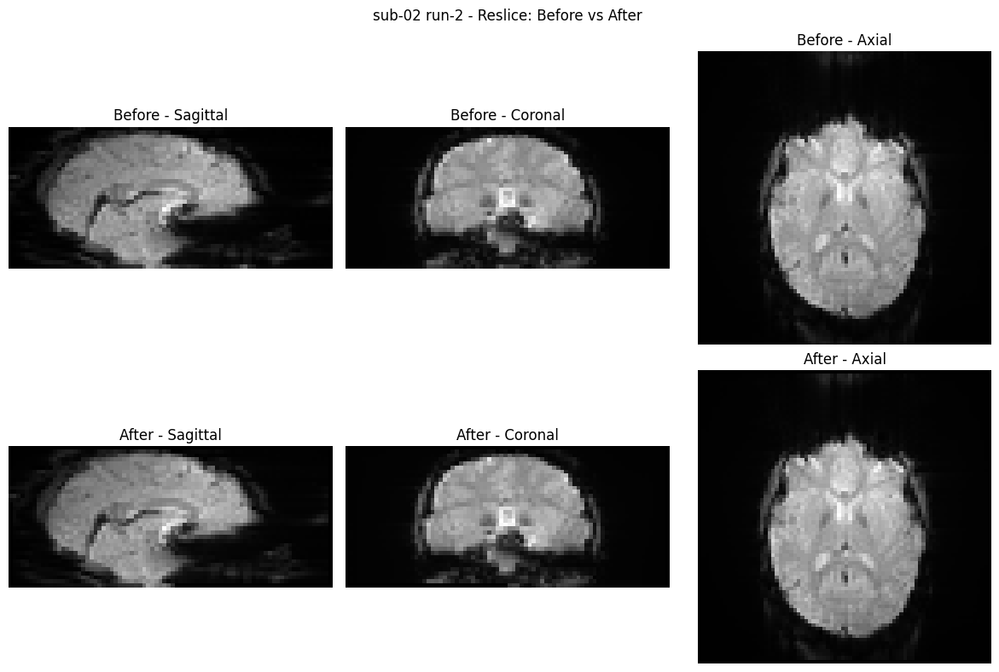

[5/66] sub-03 run-1


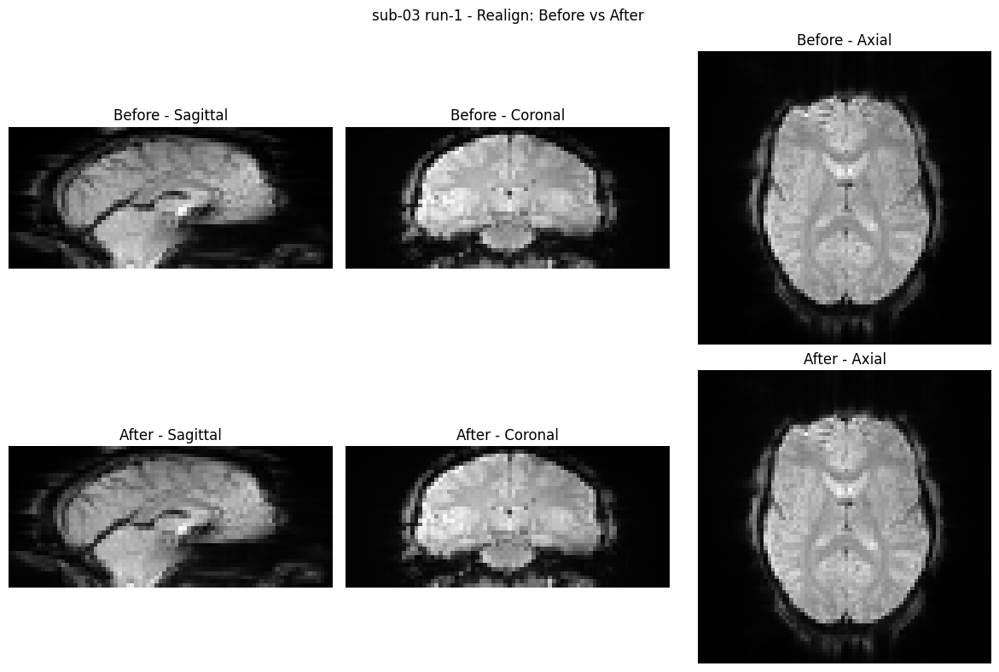

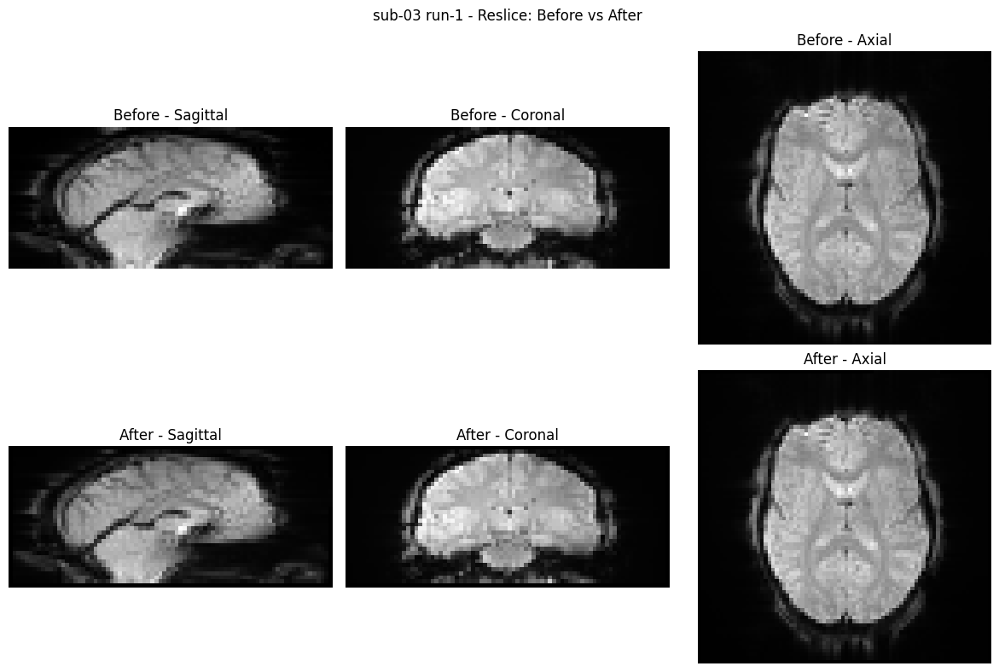

[6/66] sub-03 run-2


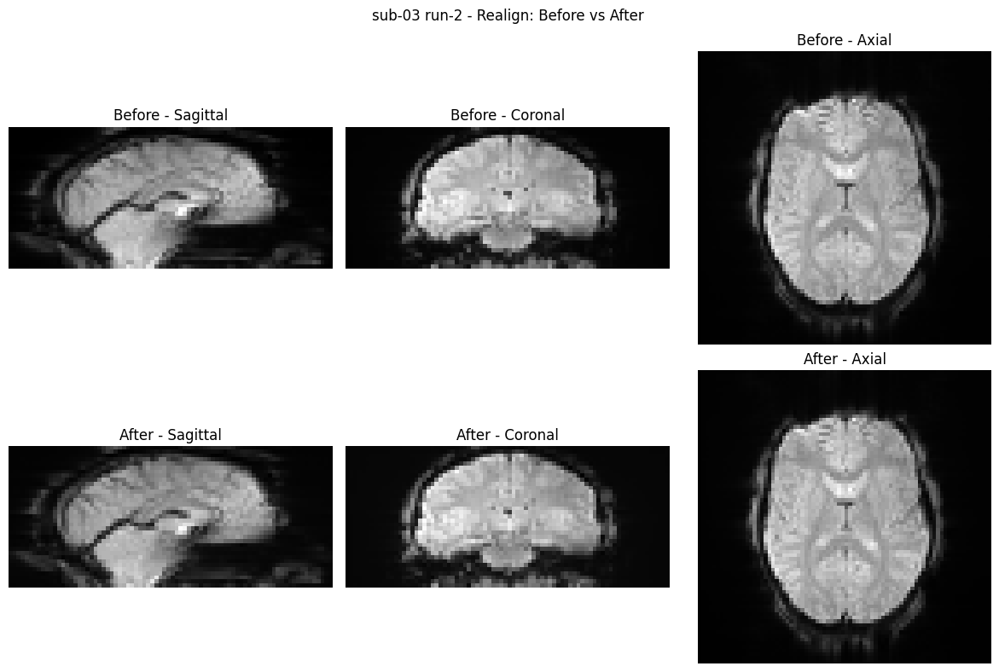

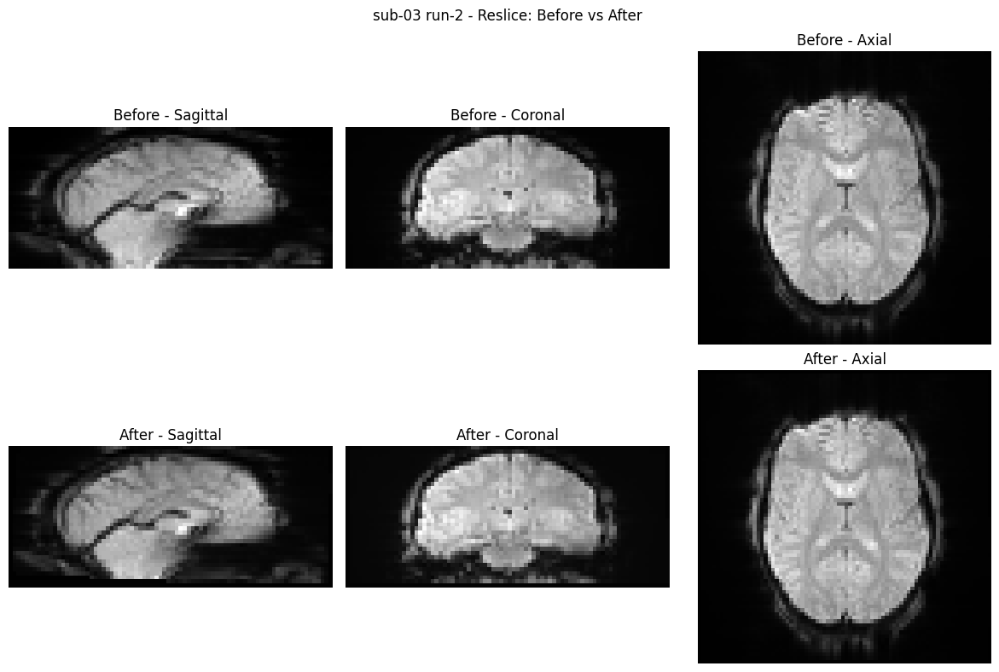

[7/66] sub-04 run-1


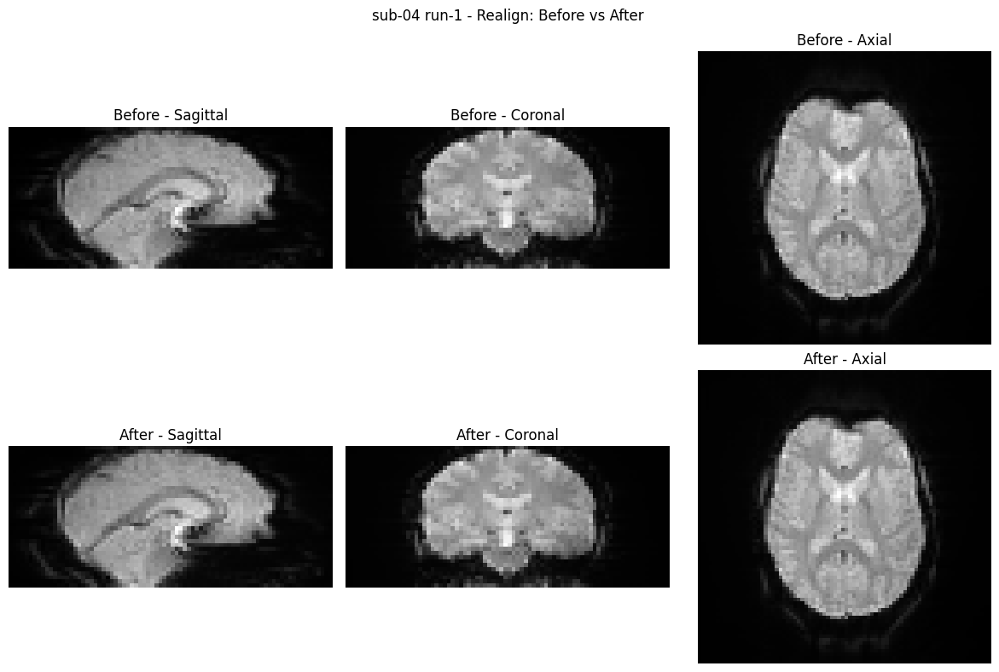

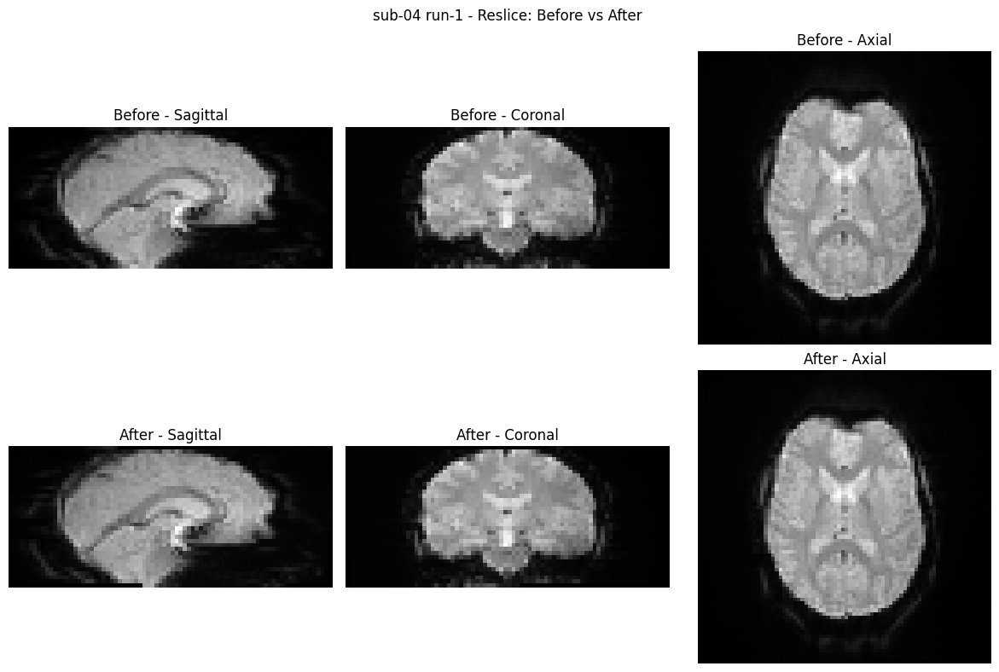

[8/66] sub-04 run-2


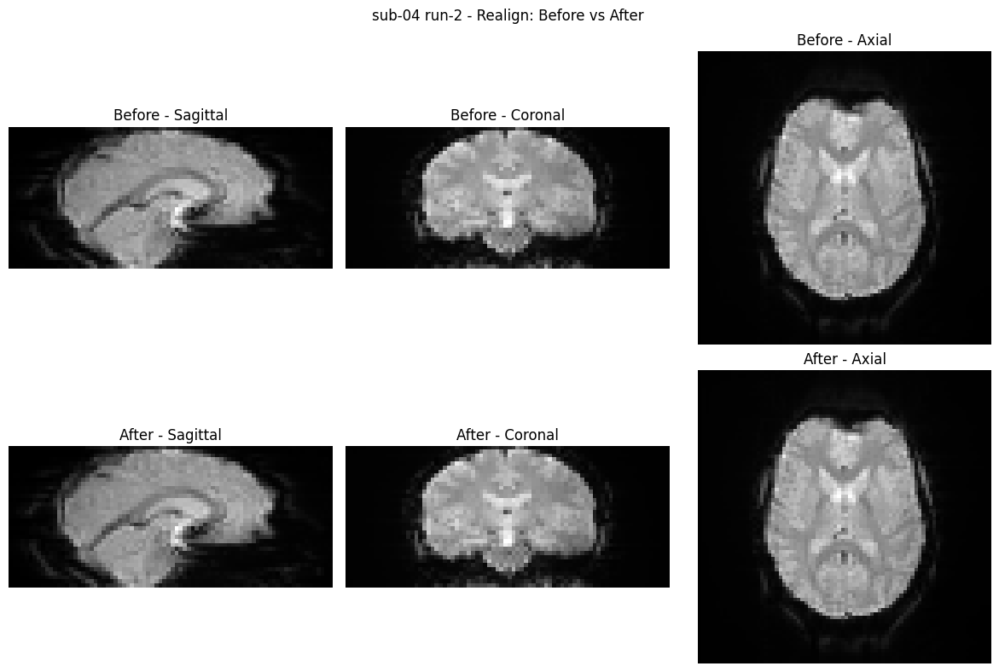

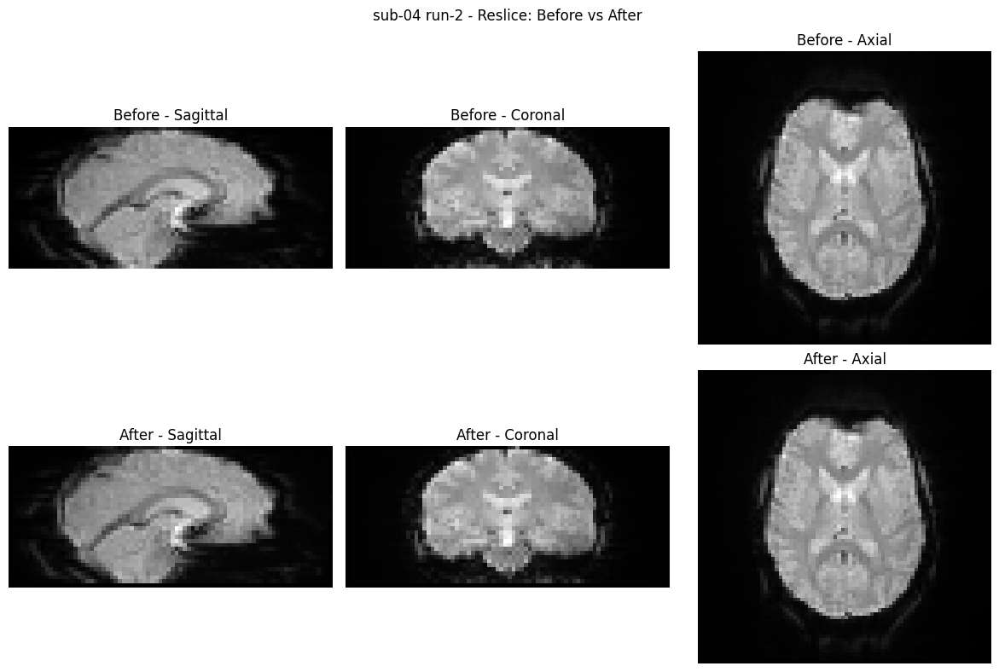

[9/66] sub-05 run-1


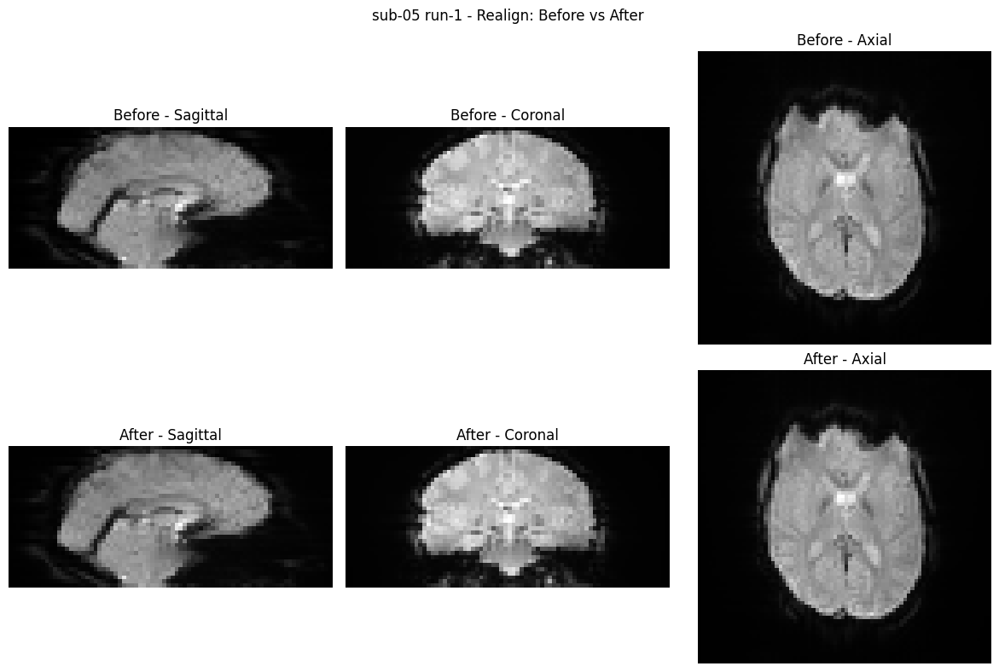

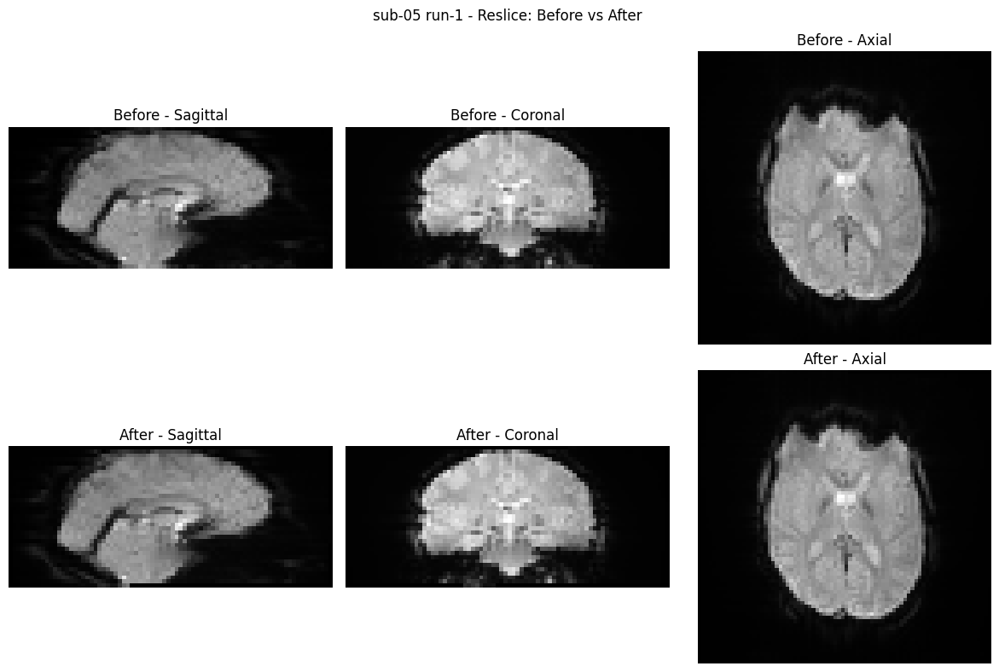

[10/66] sub-05 run-2


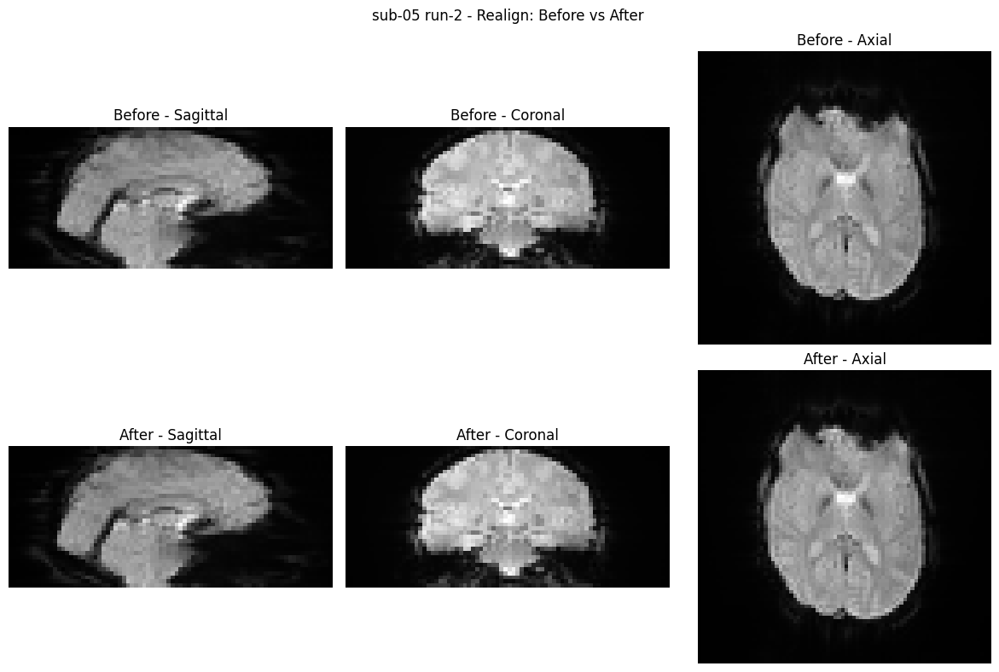

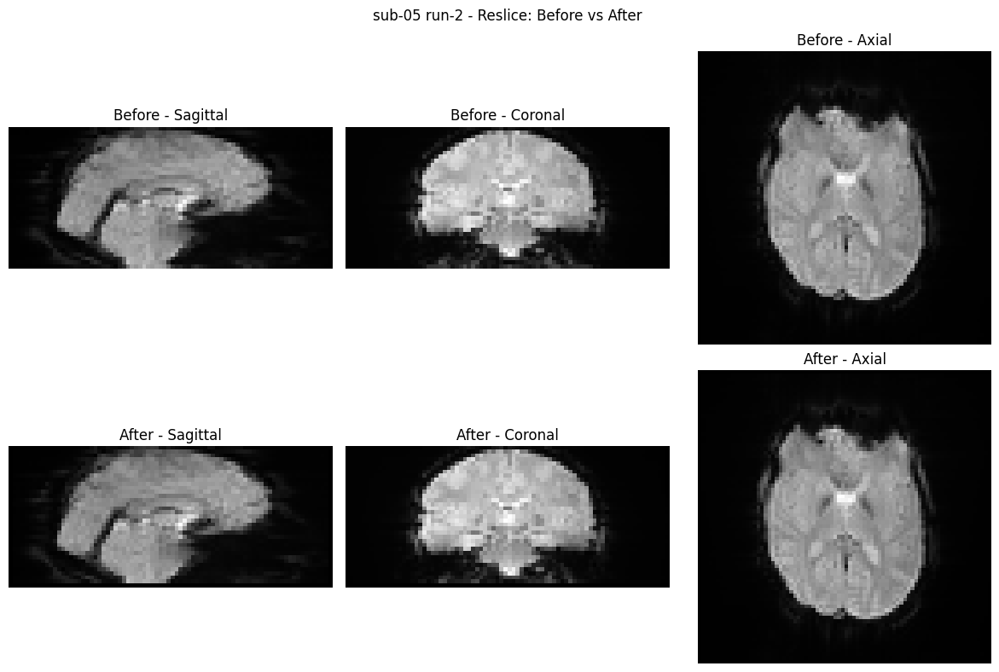

[11/66] sub-06 run-1


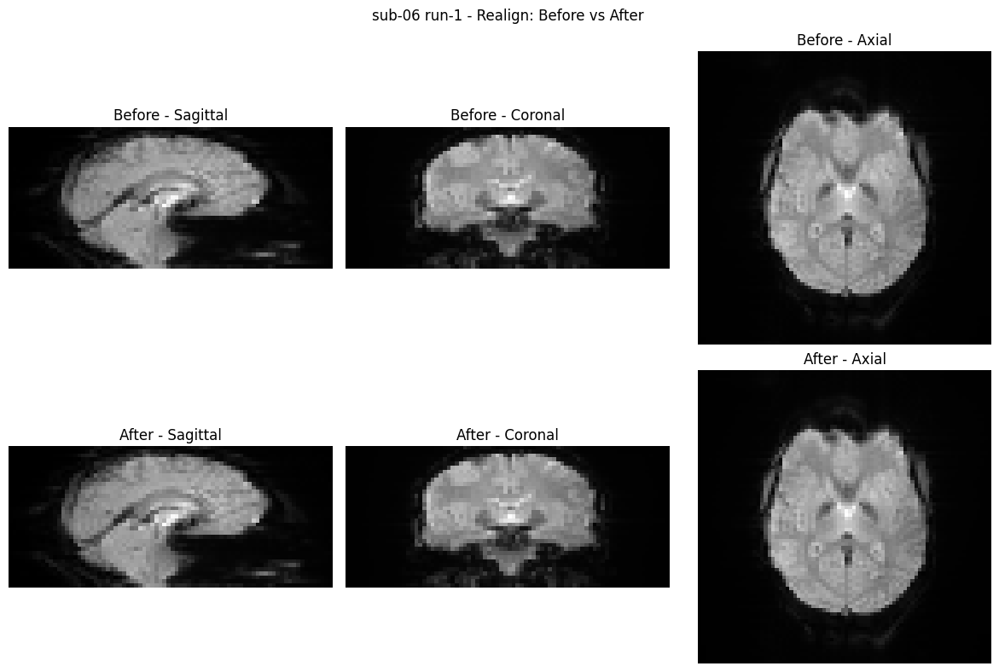

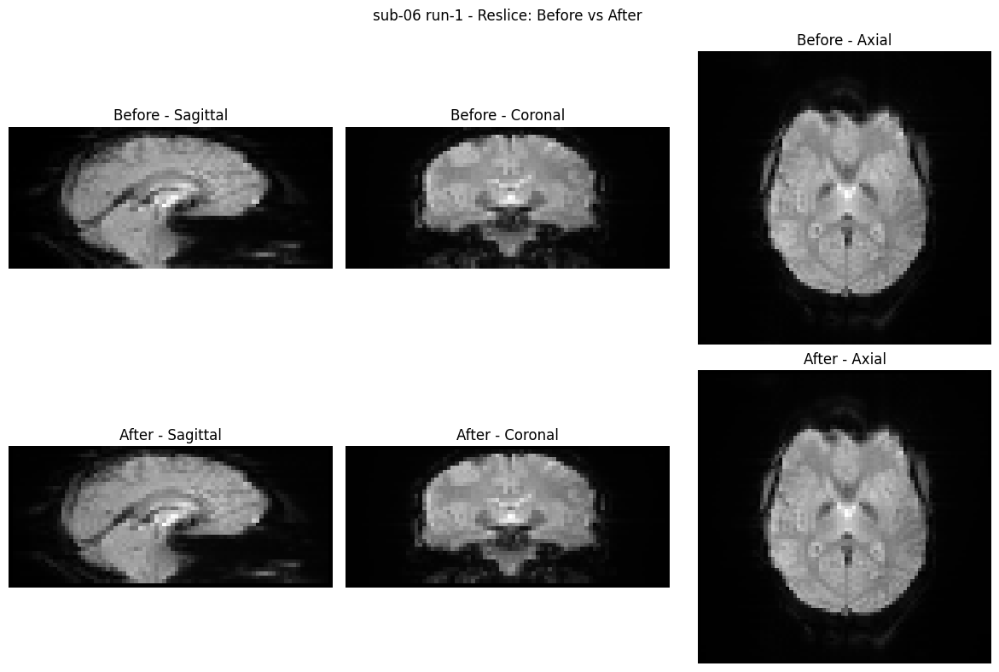

[12/66] sub-06 run-2


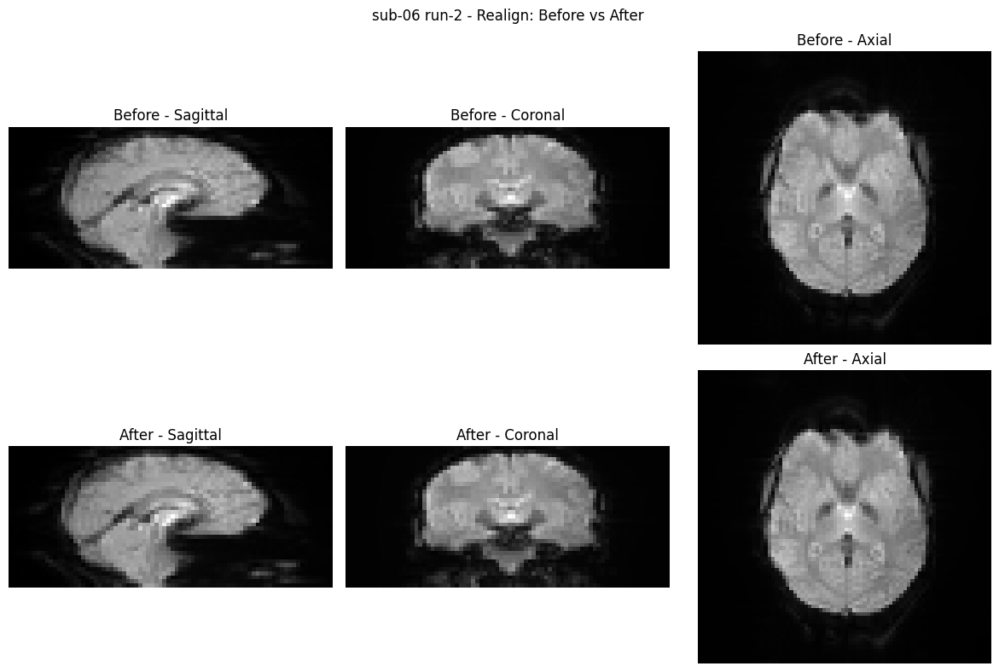

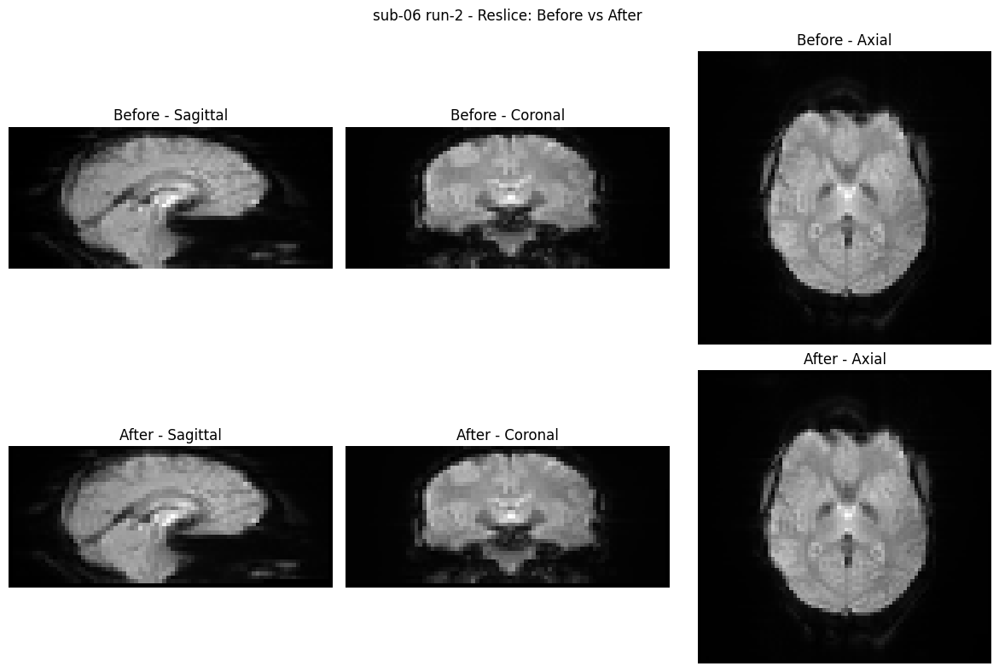

[13/66] sub-07 run-1


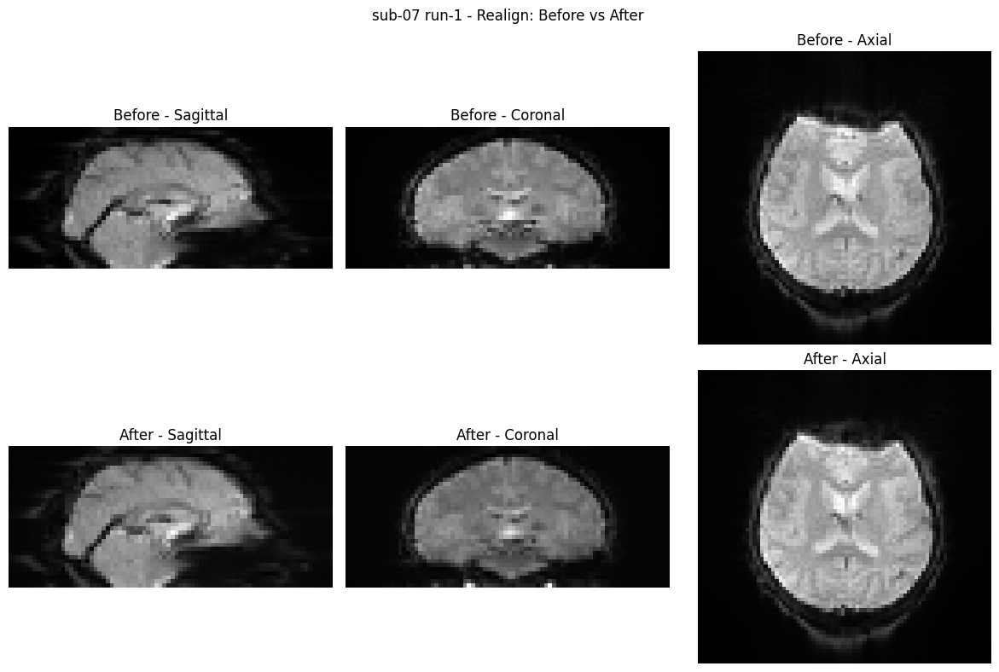

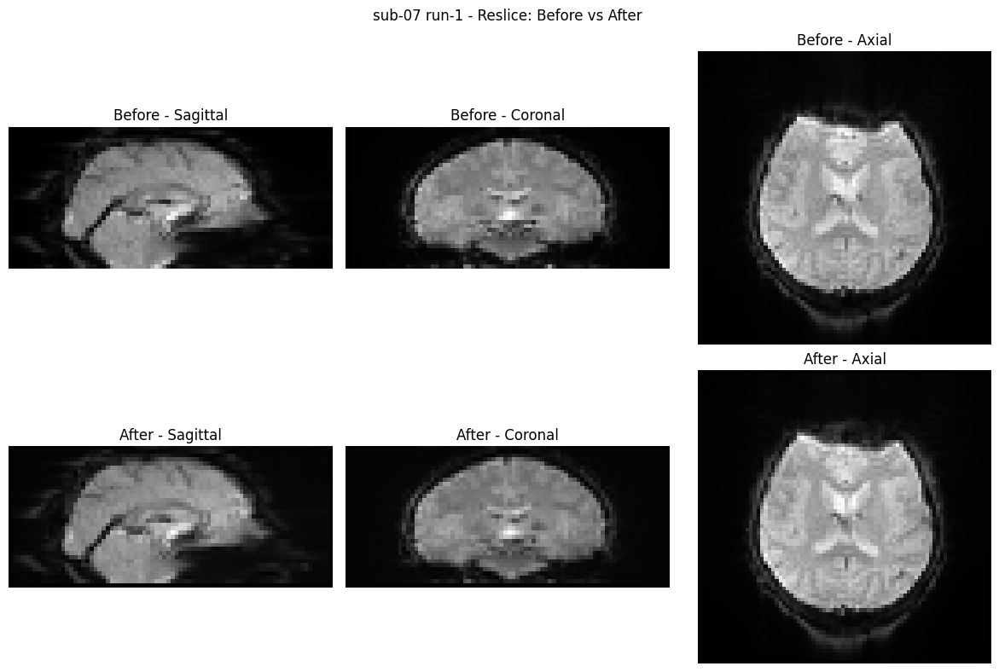

[14/66] sub-07 run-2


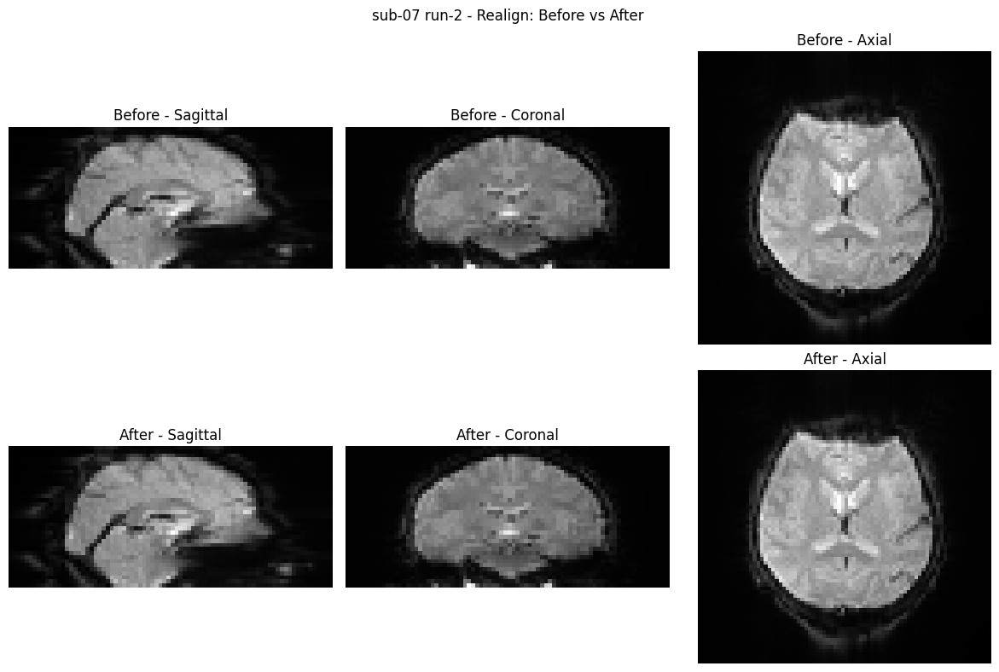

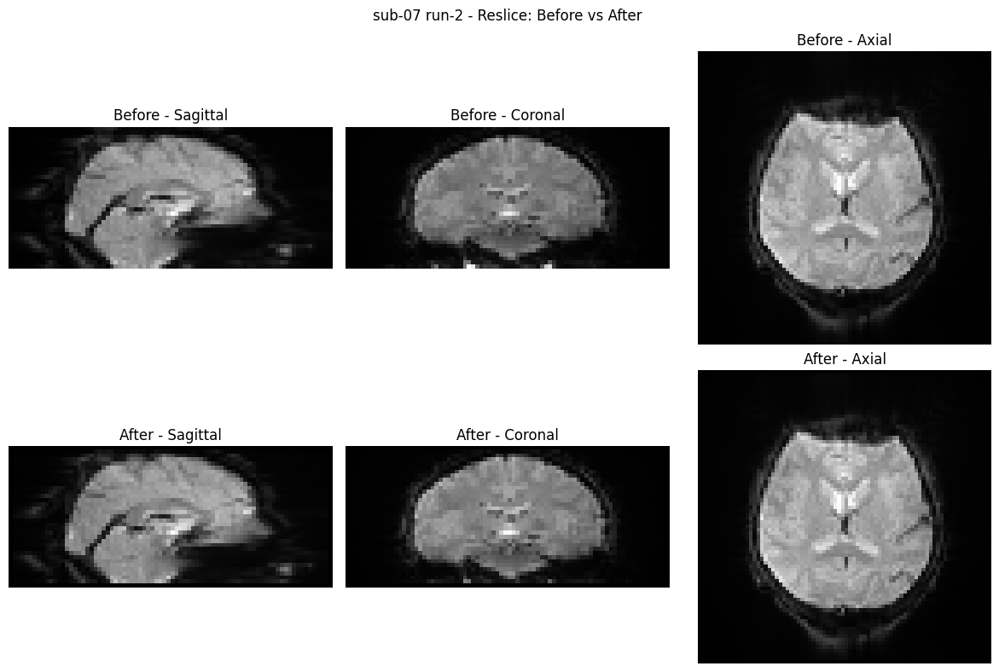

[15/66] sub-08 run-1


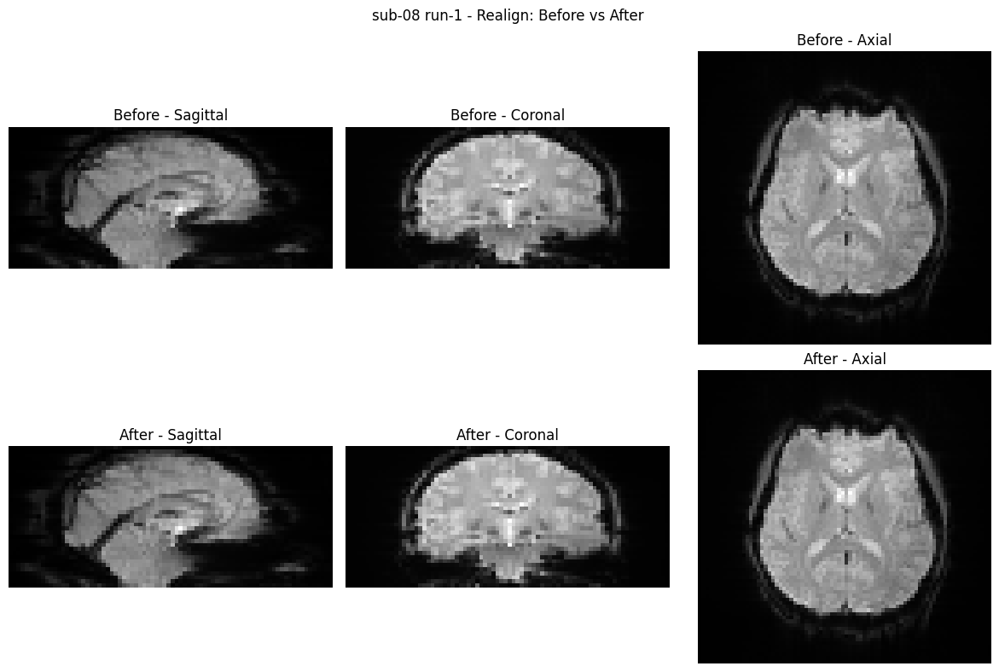

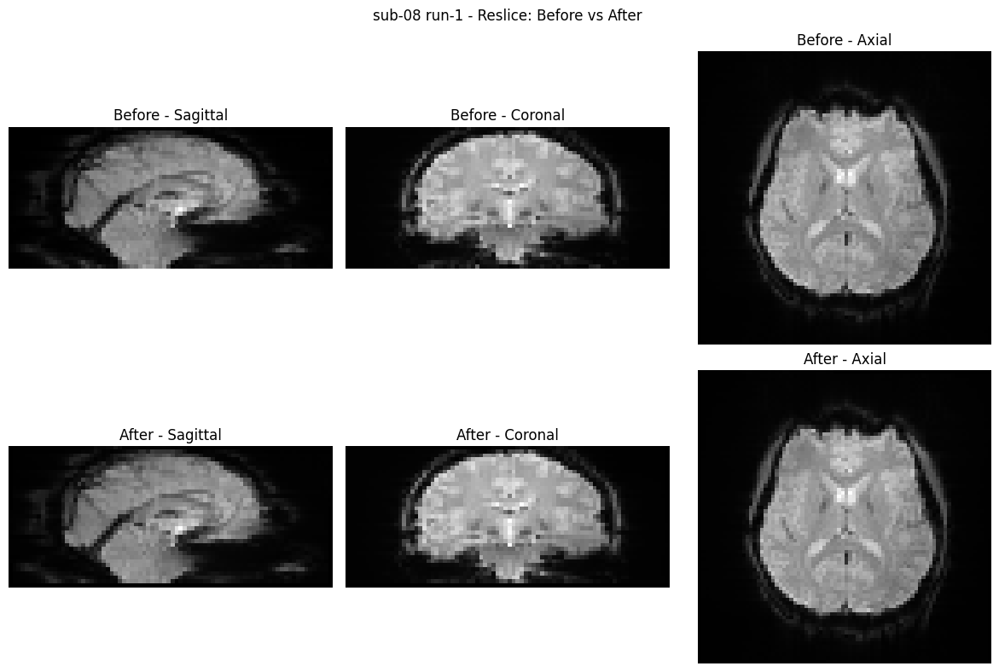

[16/66] sub-08 run-2


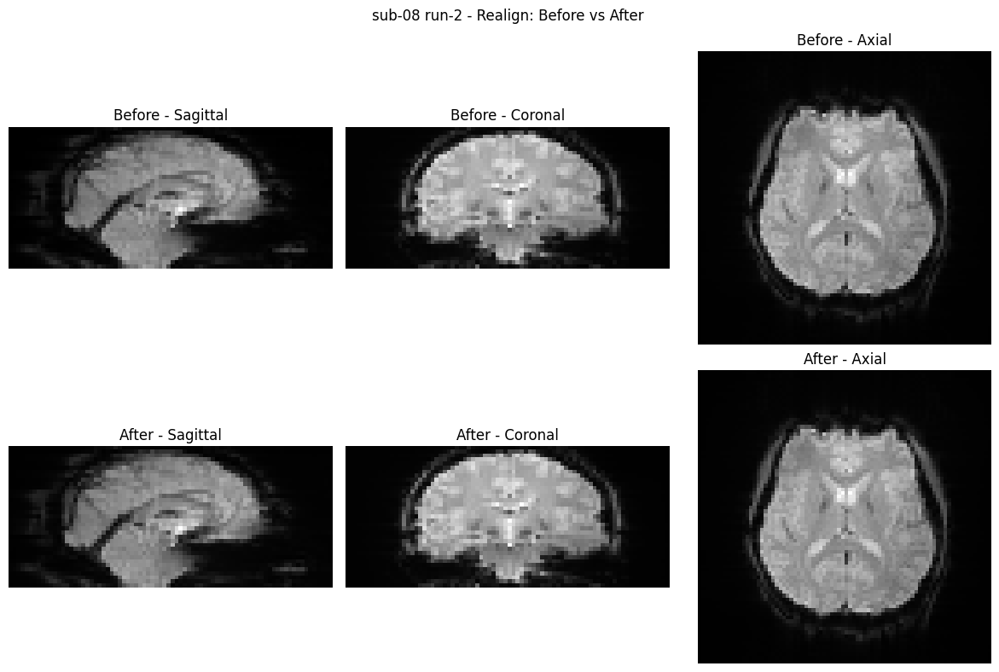

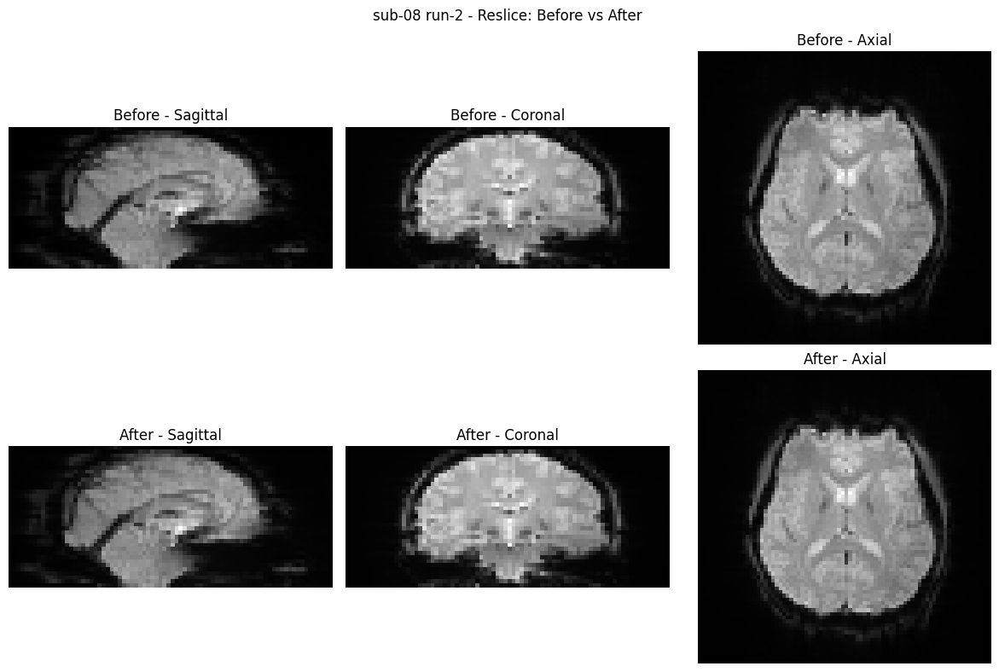

[17/66] sub-09 run-1


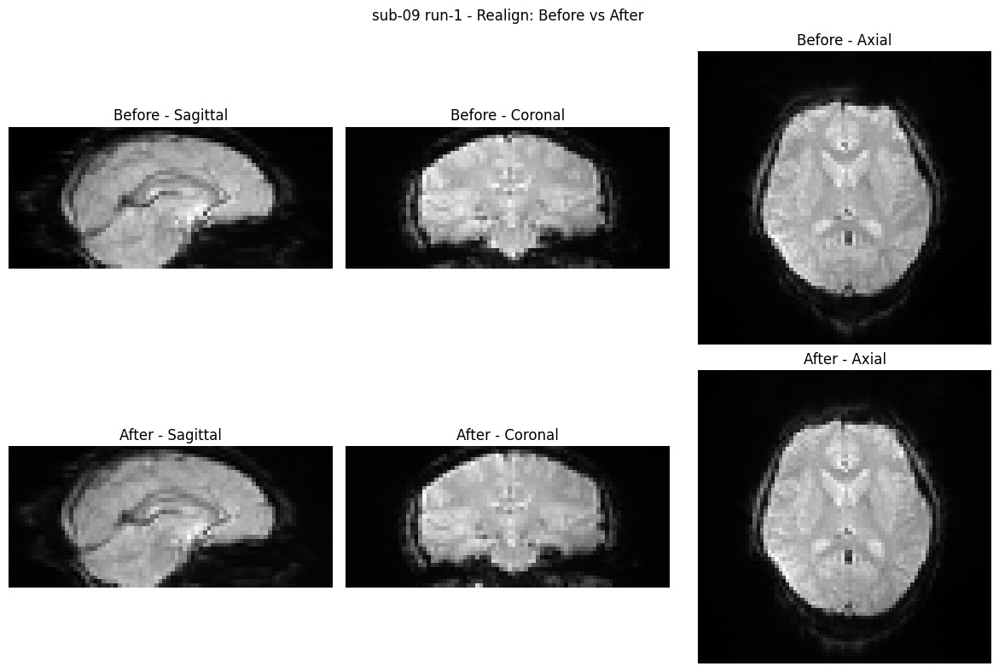

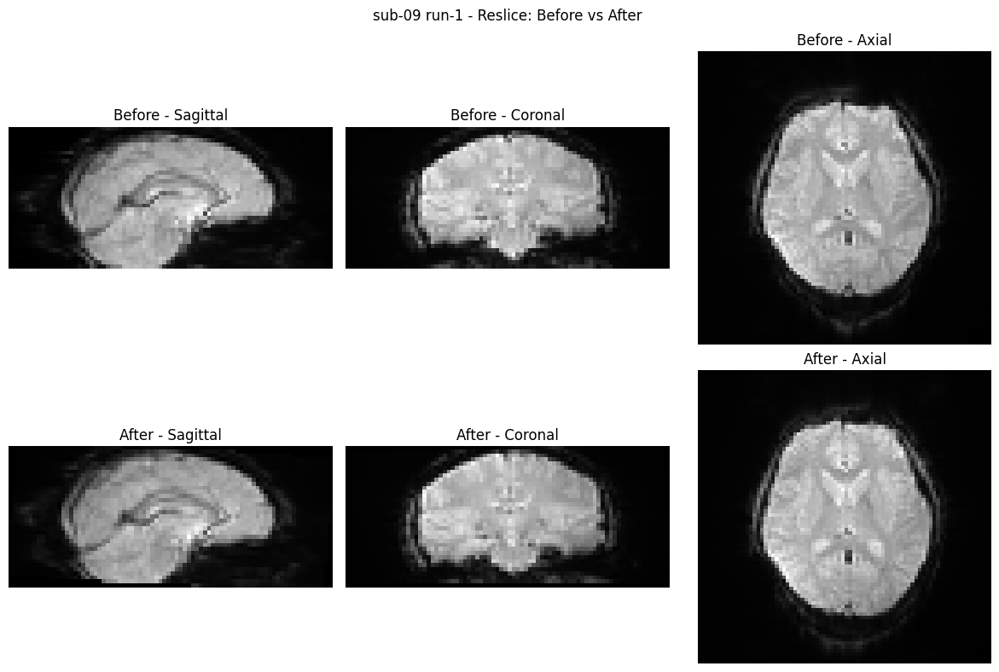

[18/66] sub-09 run-2


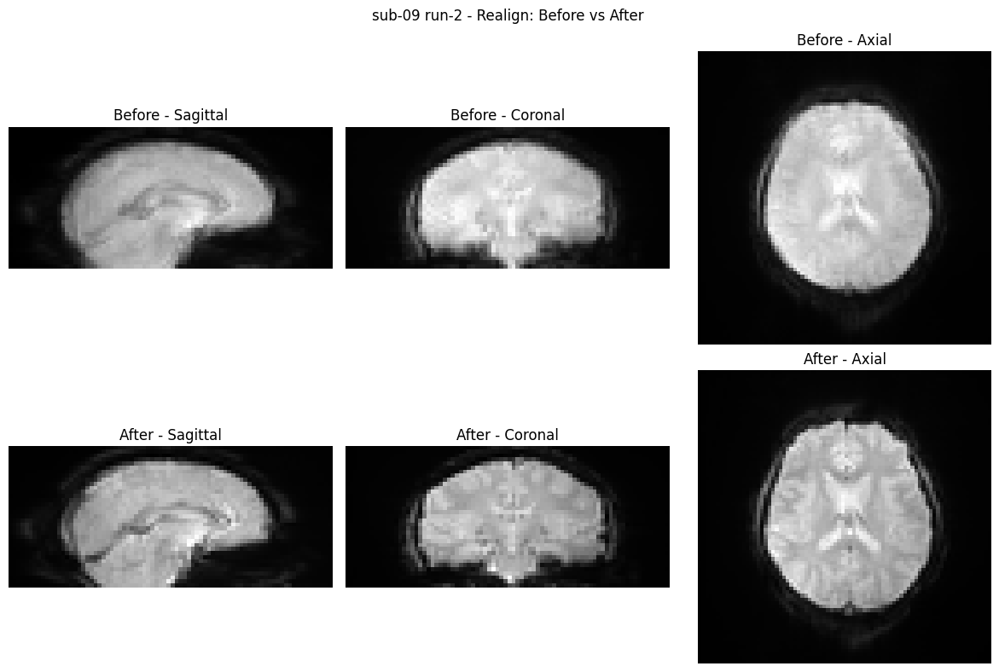

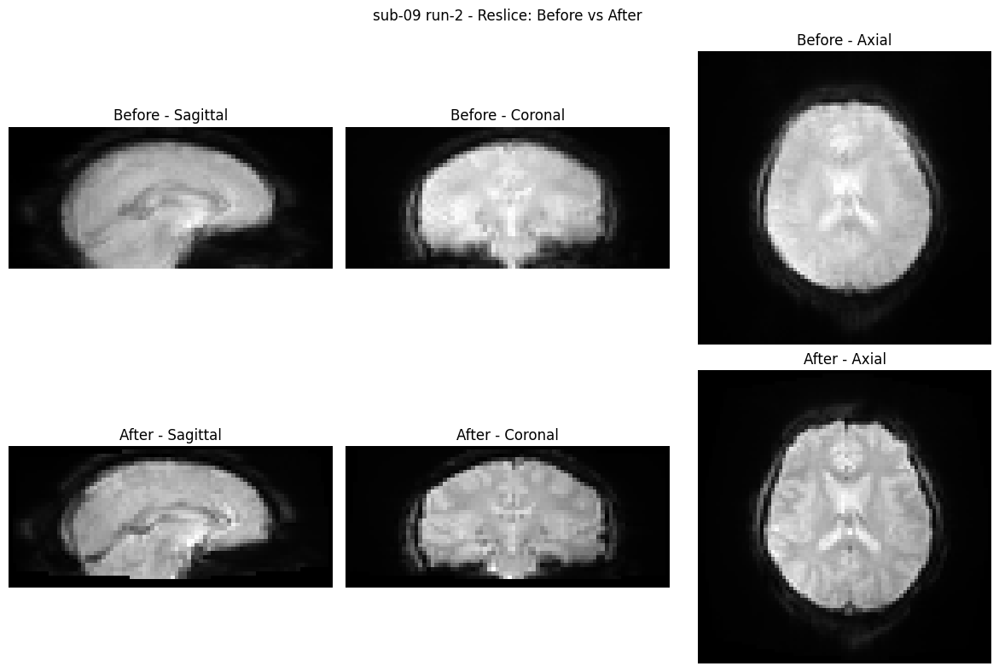

[19/66] sub-10 run-1


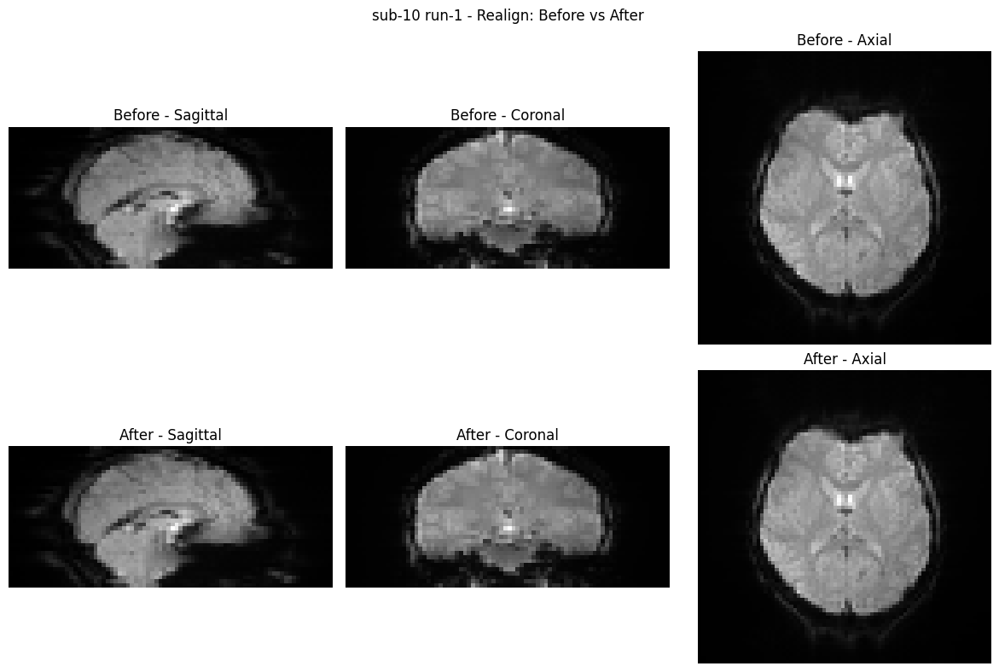

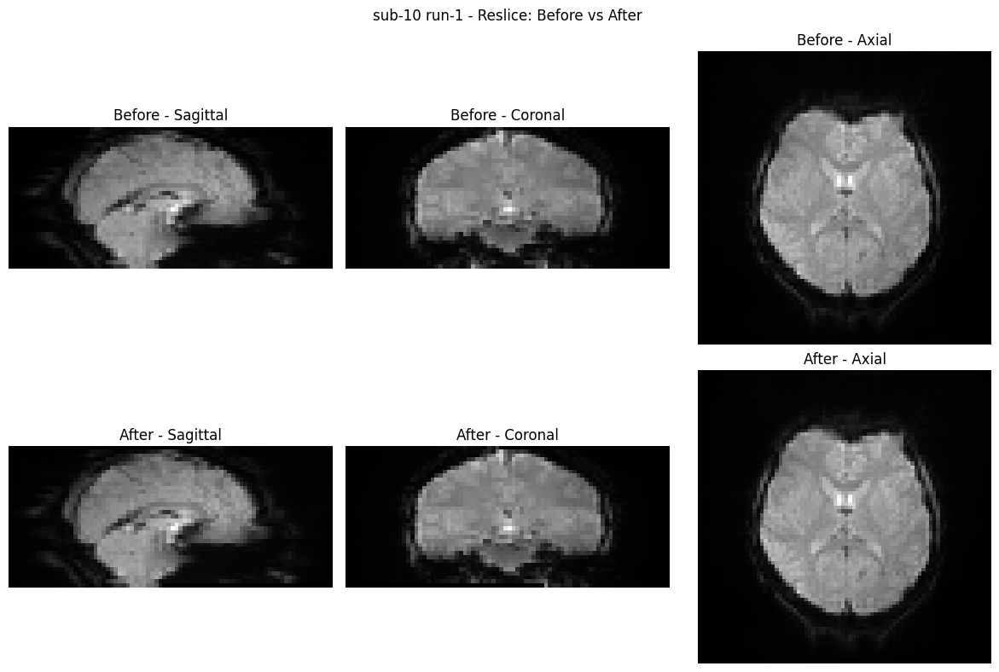

[20/66] sub-10 run-2


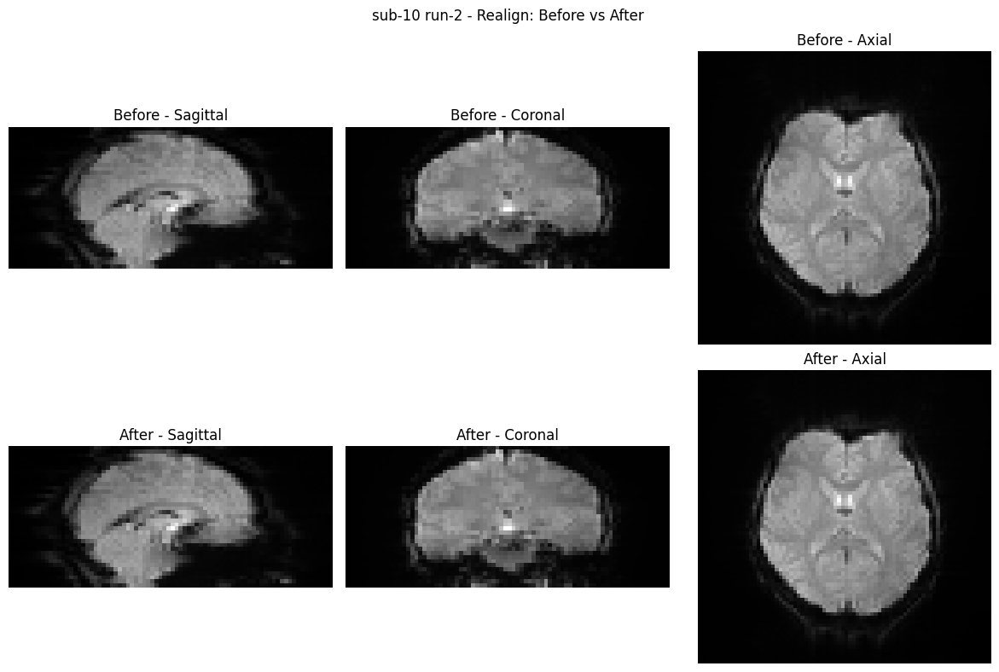

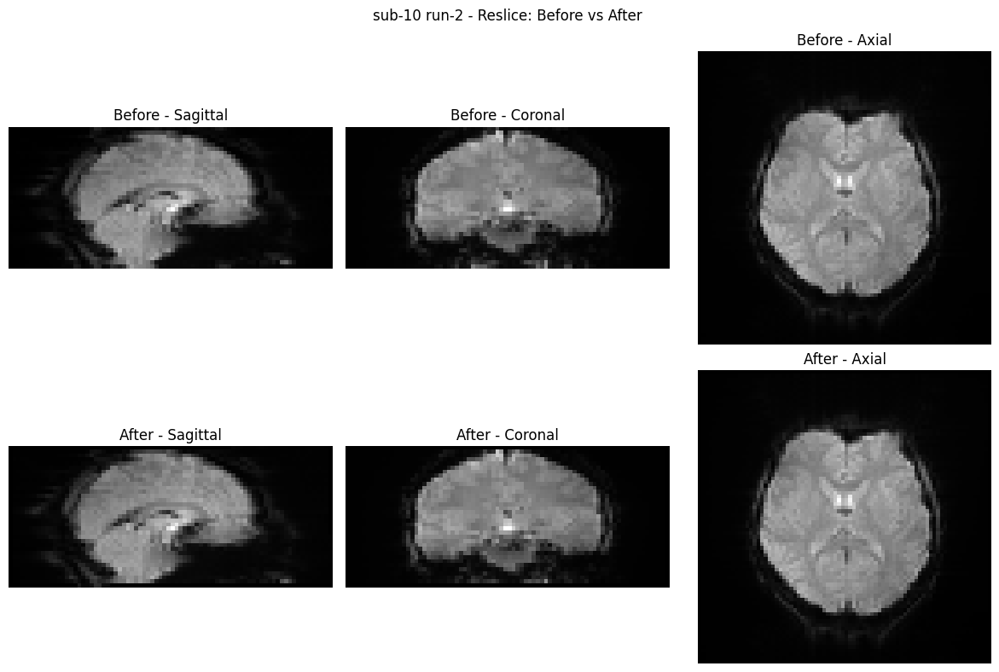

[21/66] sub-11 run-1


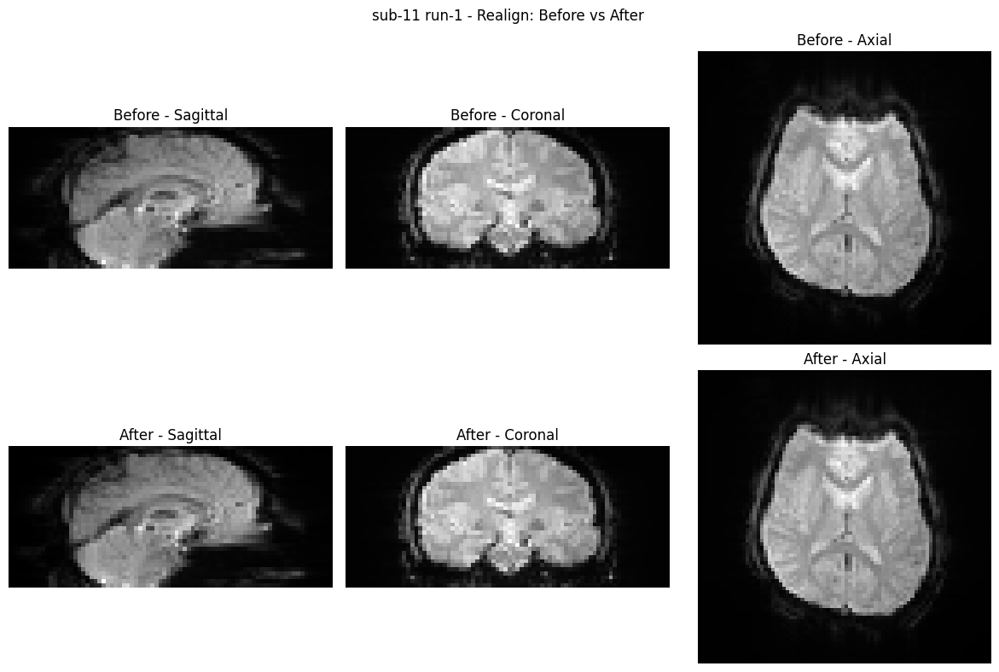

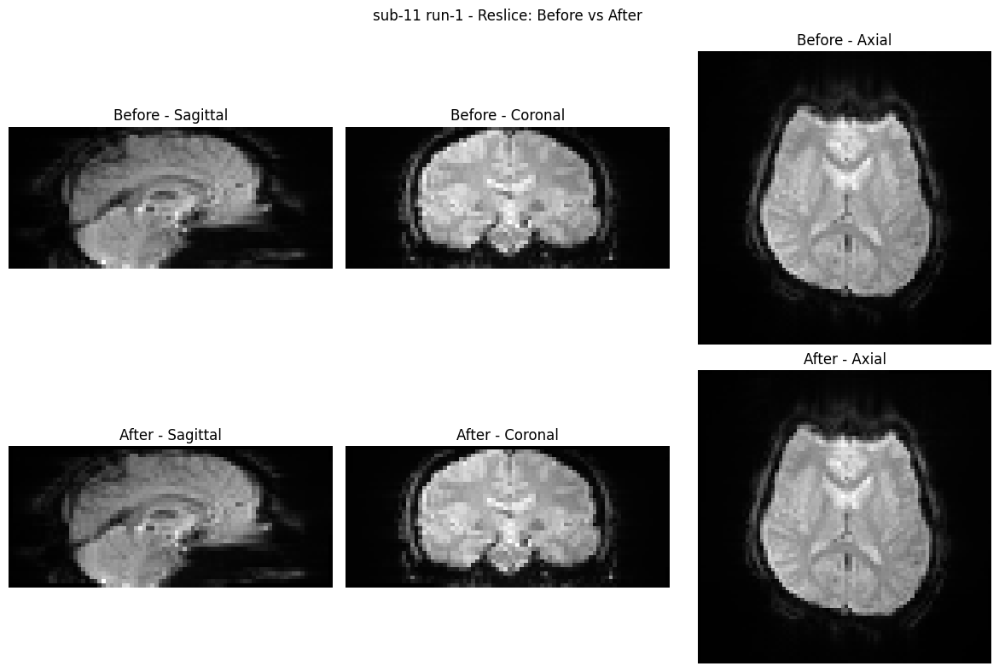

[22/66] sub-11 run-2


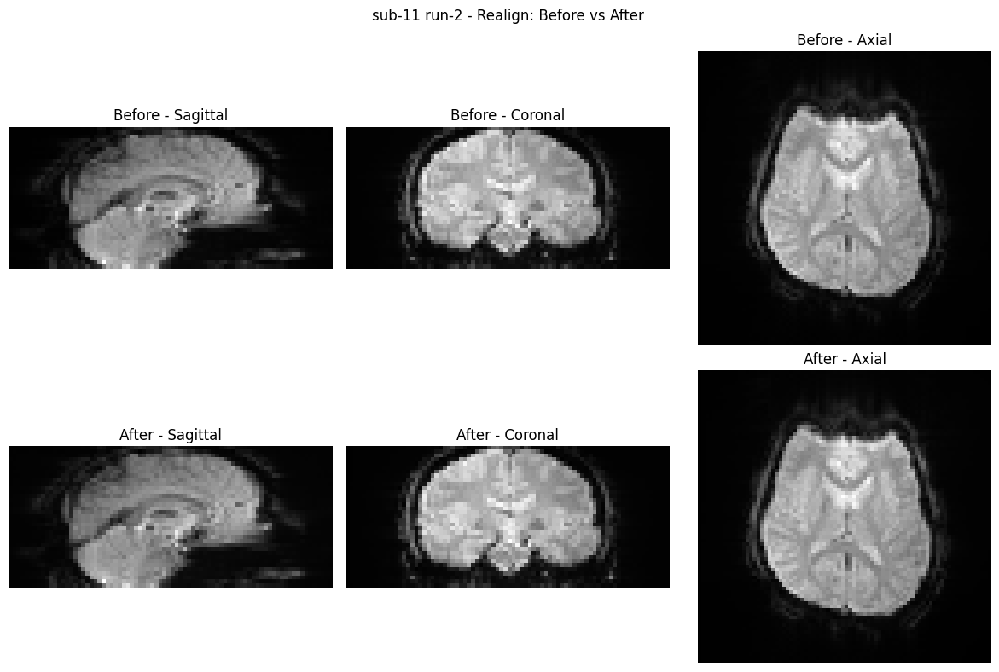

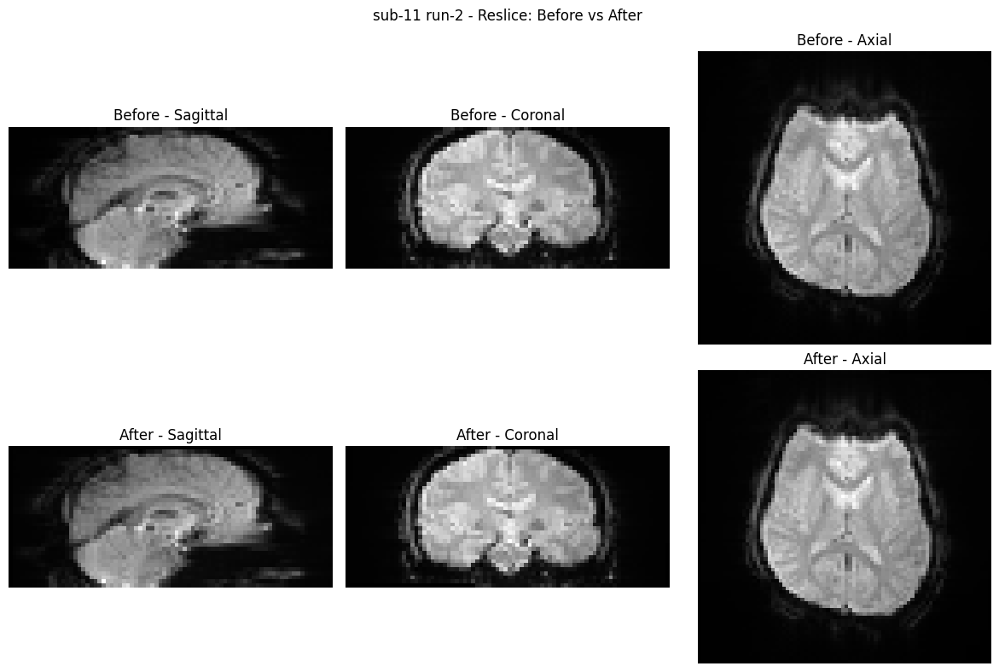

[23/66] sub-12 run-1


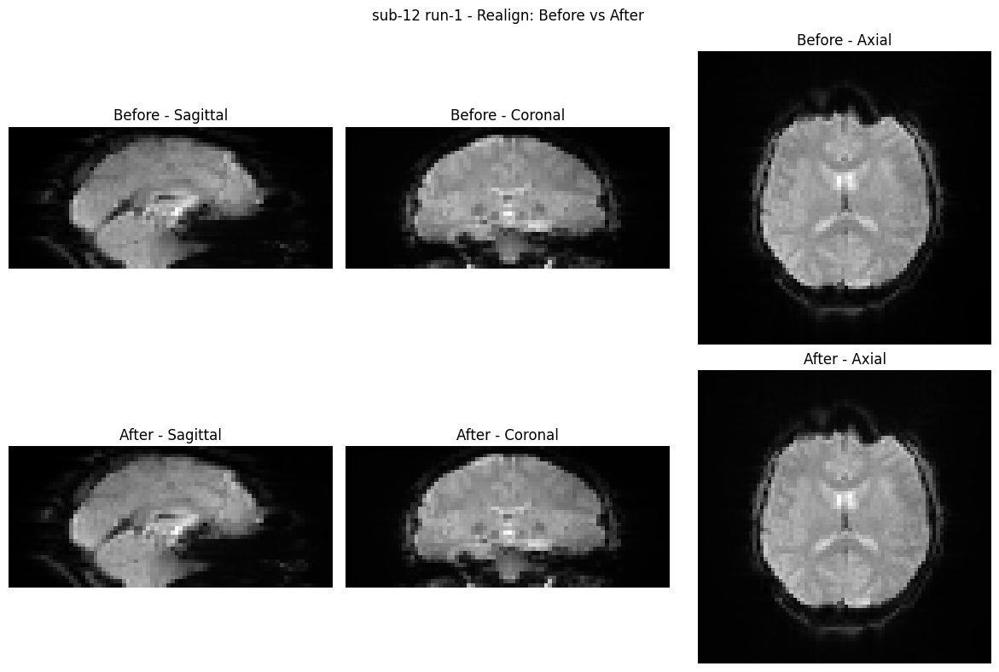

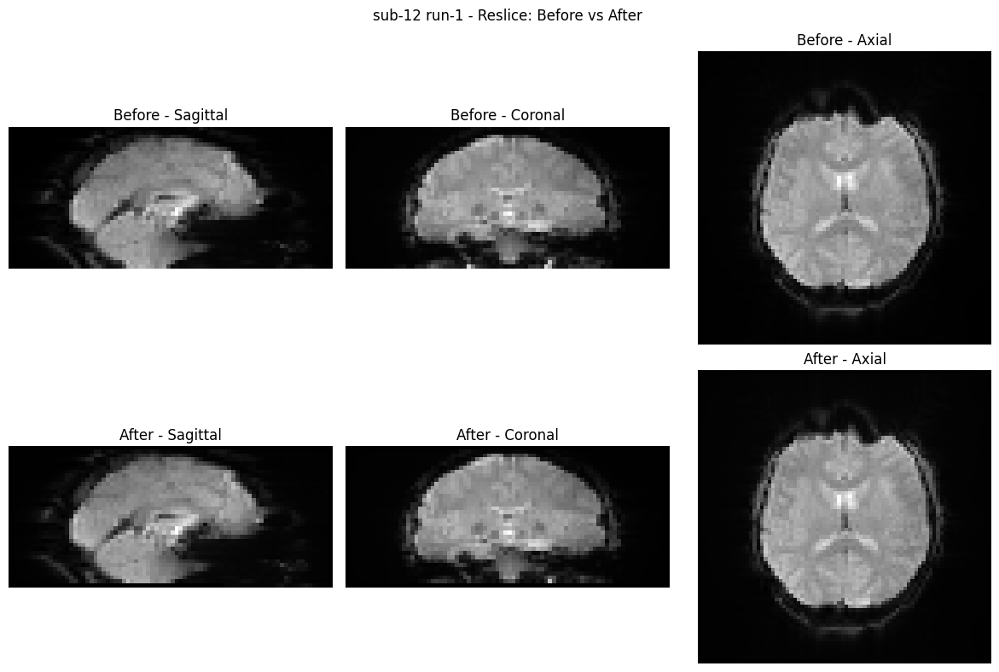

[24/66] sub-12 run-2


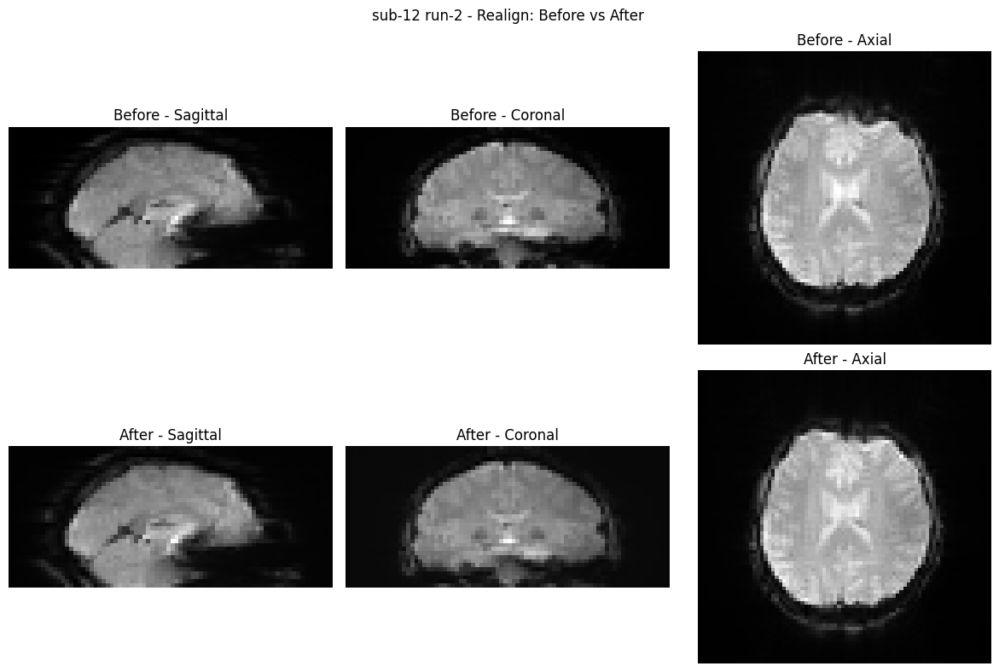

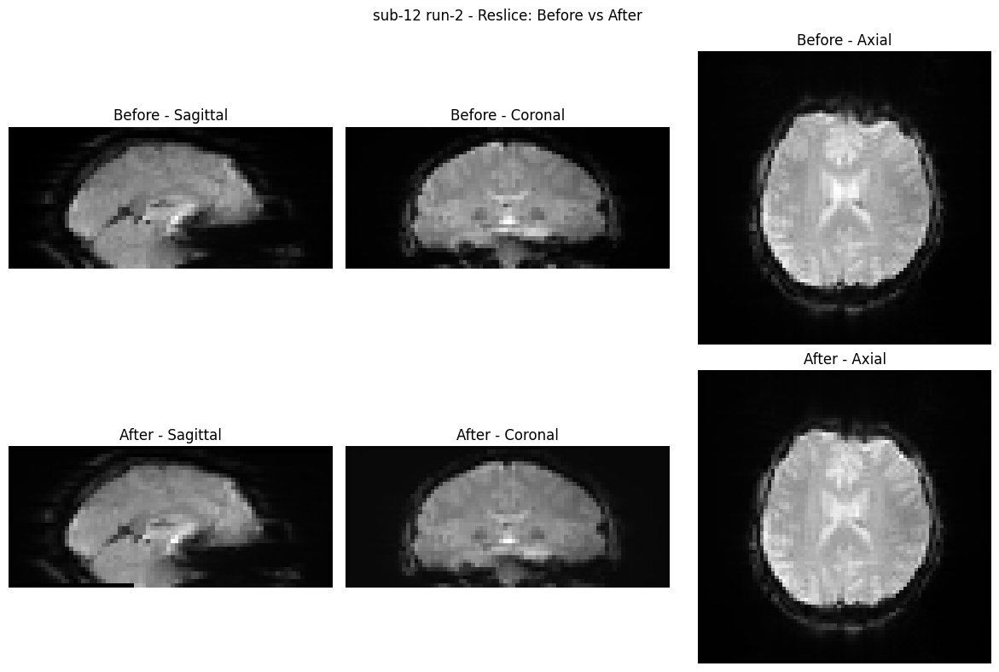

[25/66] sub-13 run-1


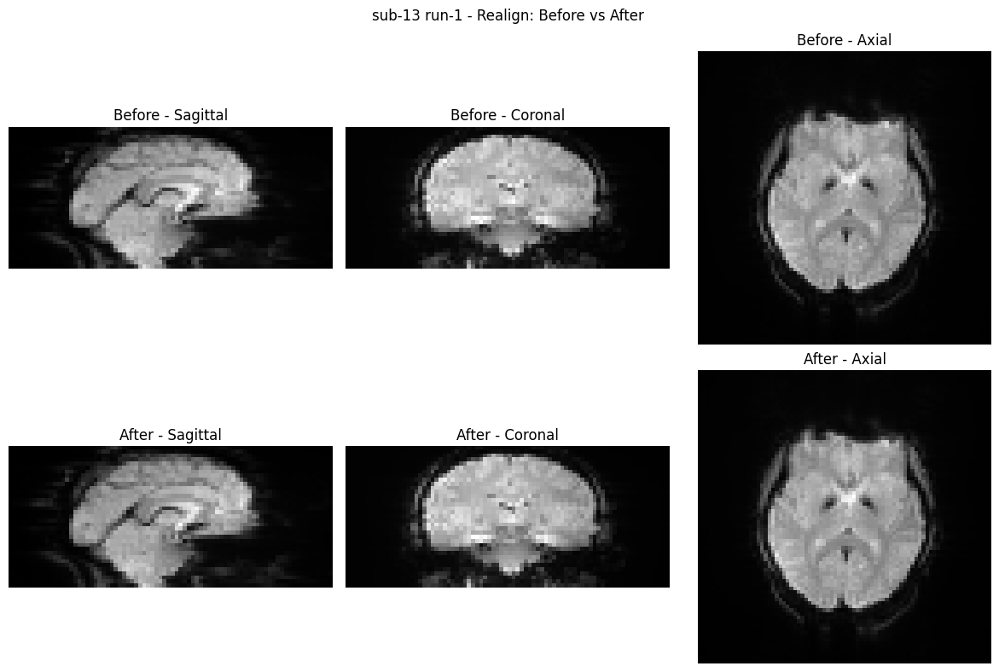

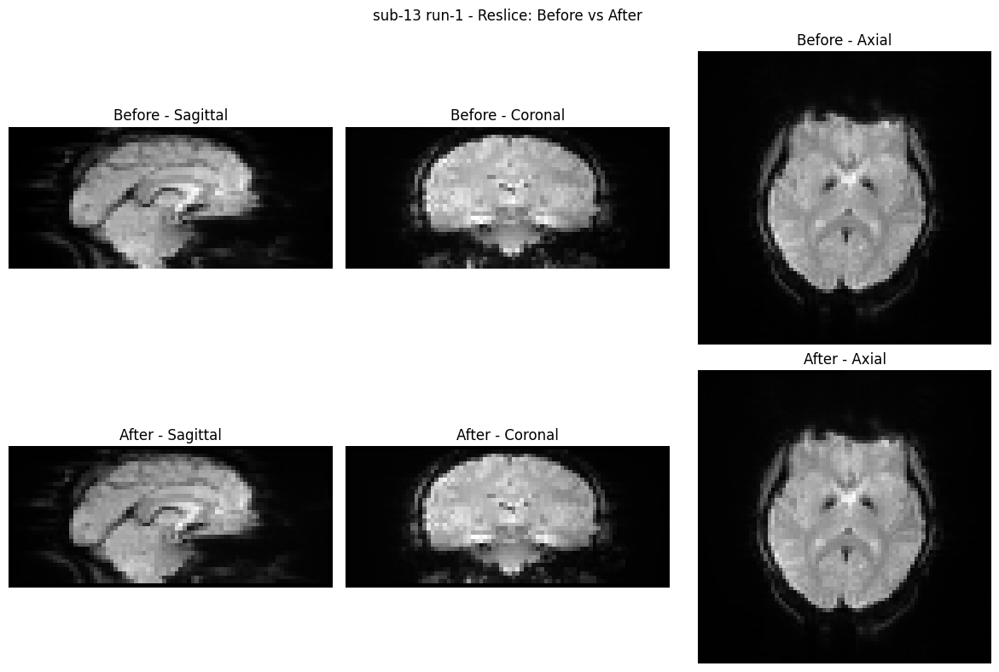

[26/66] sub-13 run-2


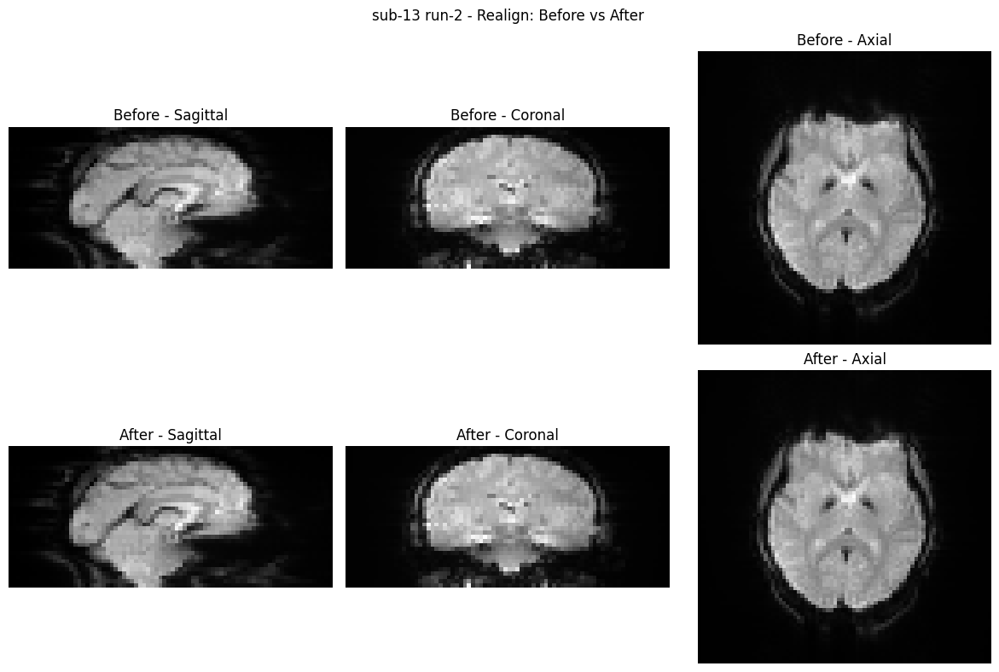

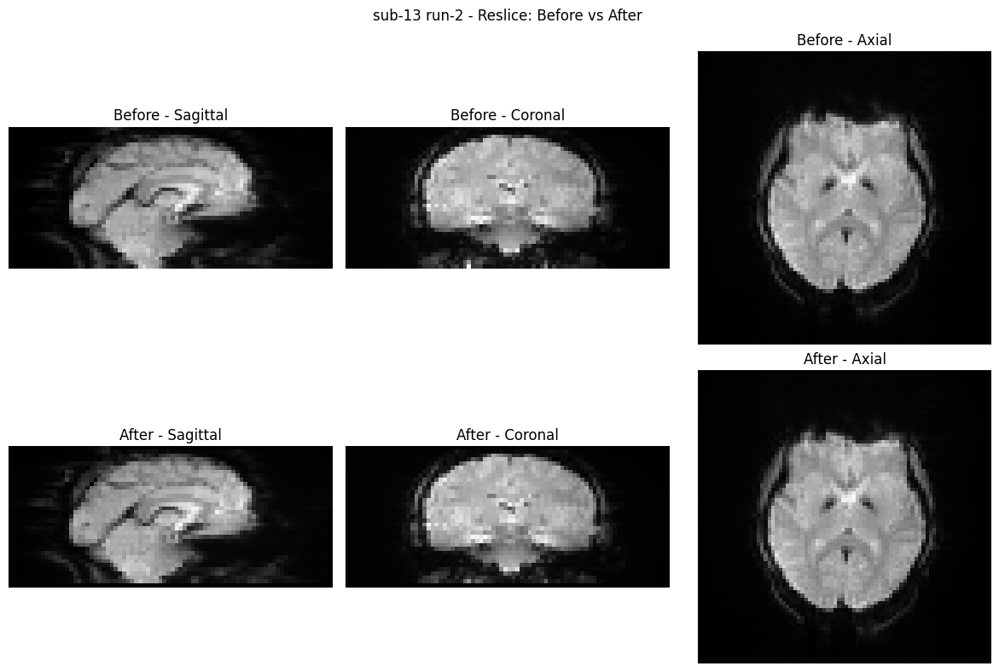

[27/66] sub-14 run-1


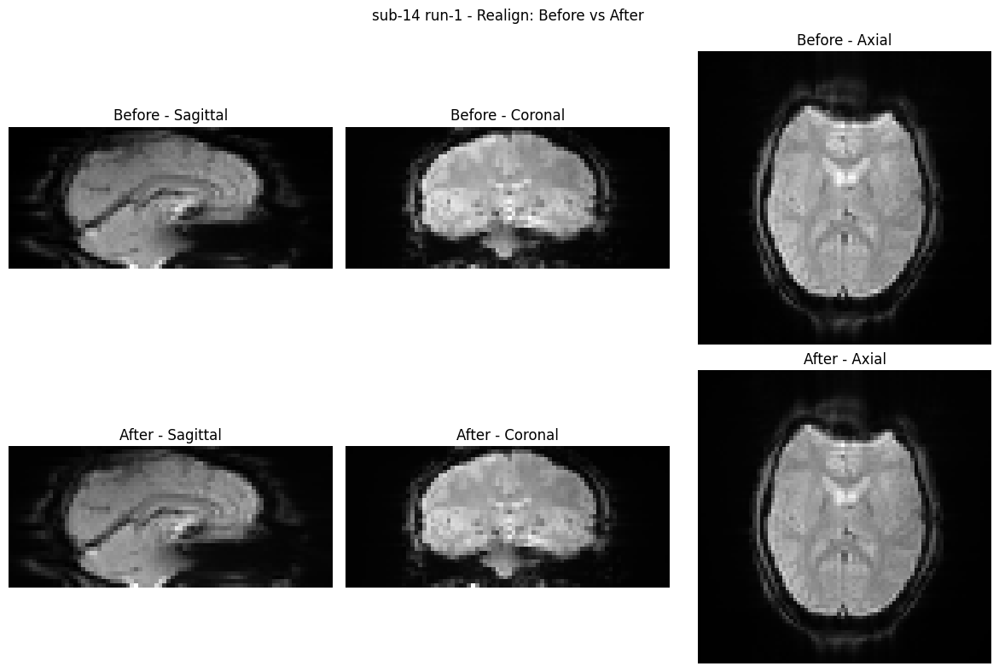

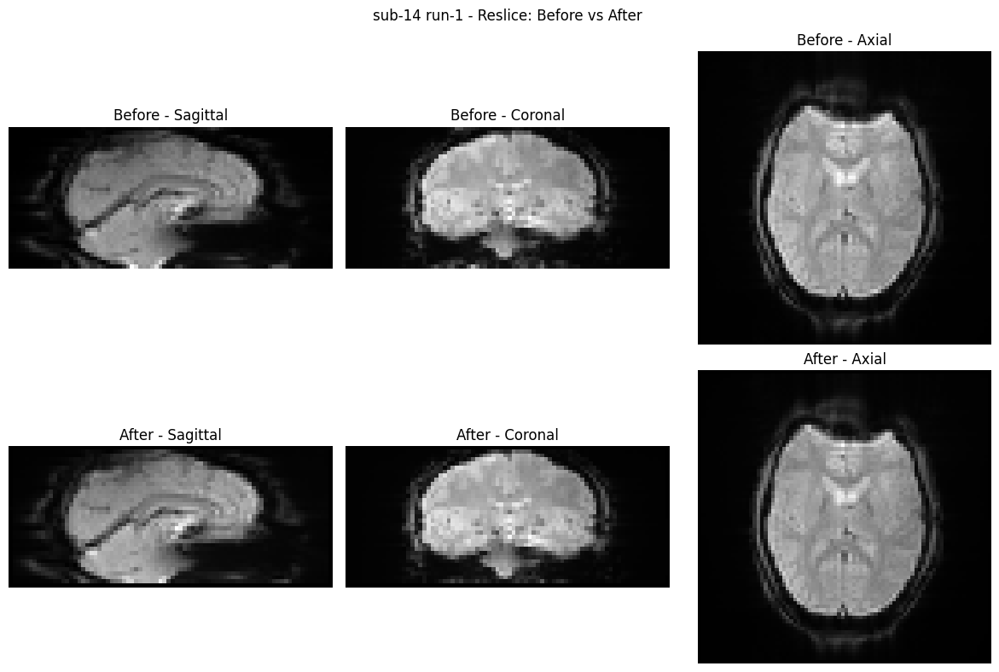

[28/66] sub-14 run-2


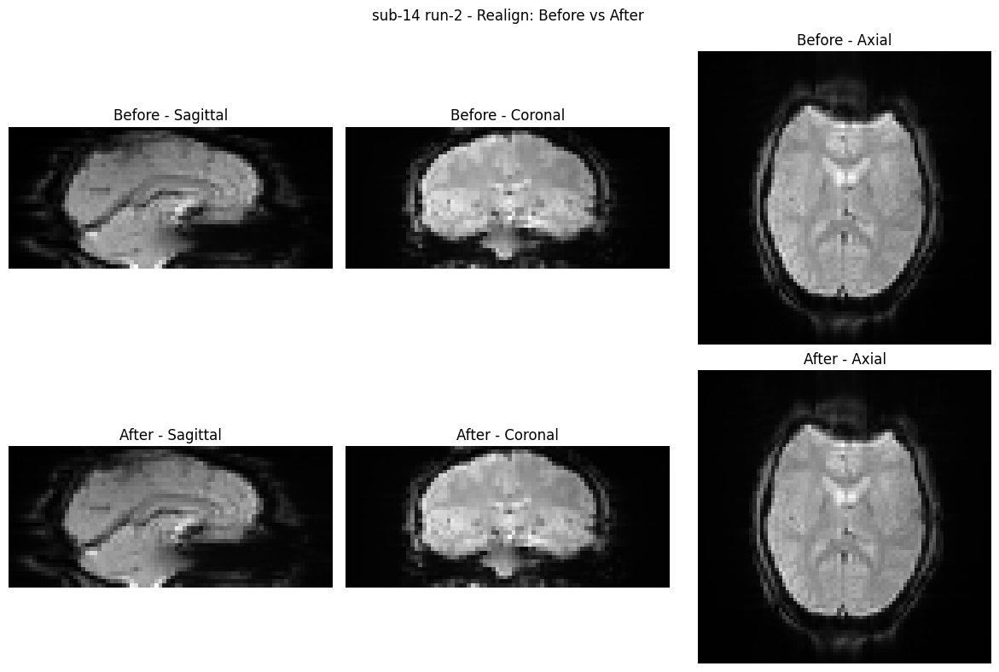

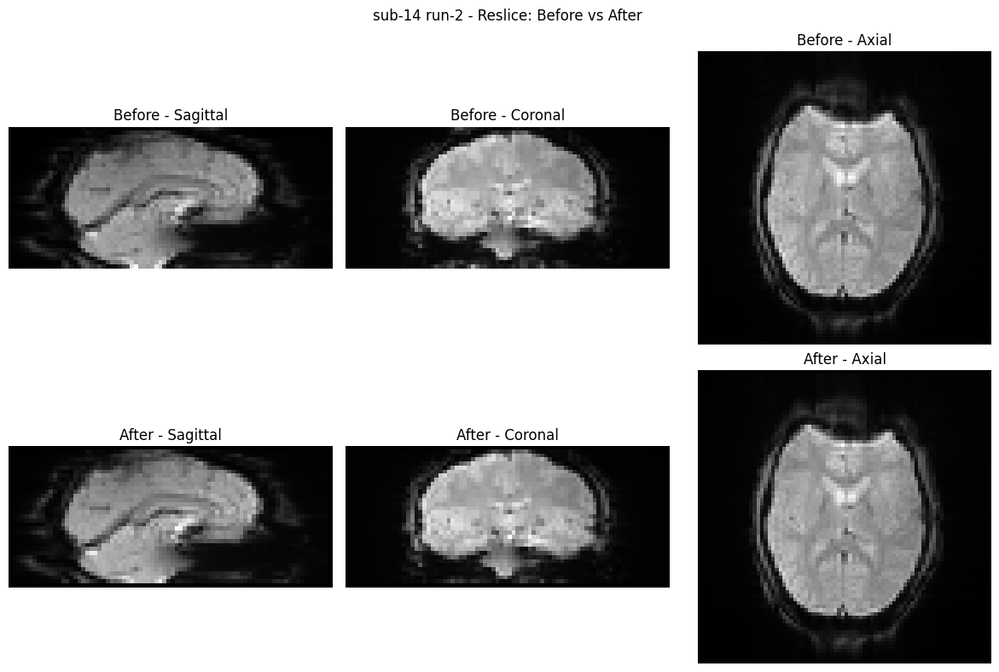

[29/66] sub-15 run-1


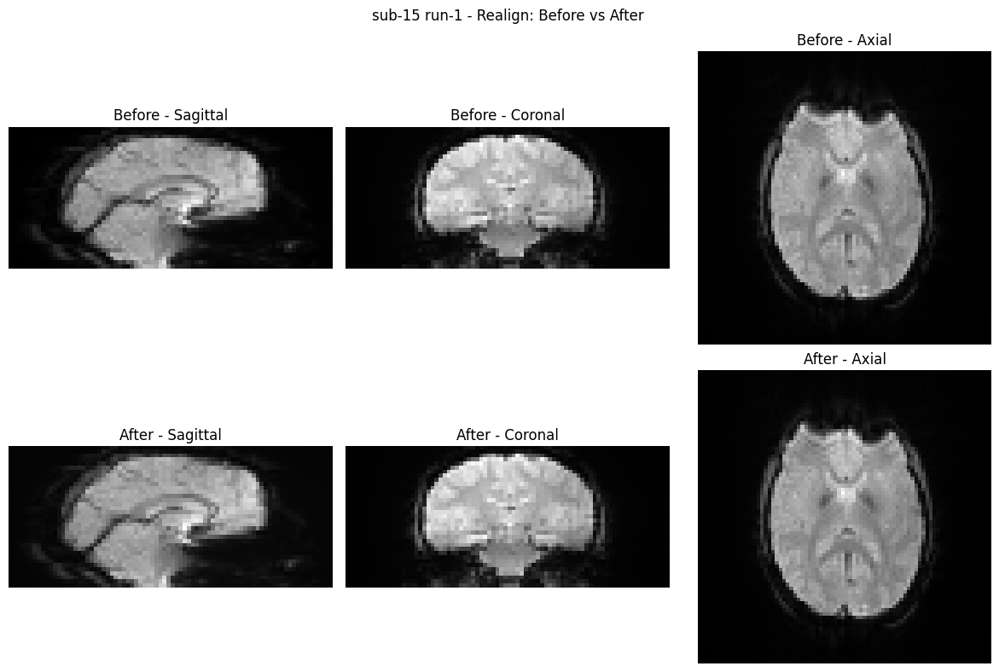

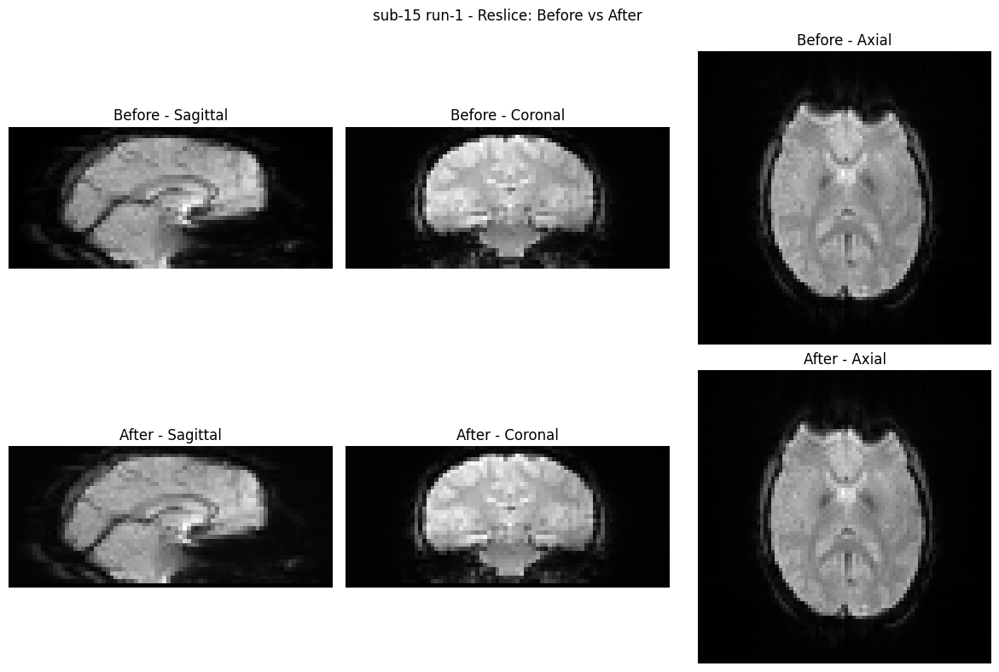

[30/66] sub-15 run-2


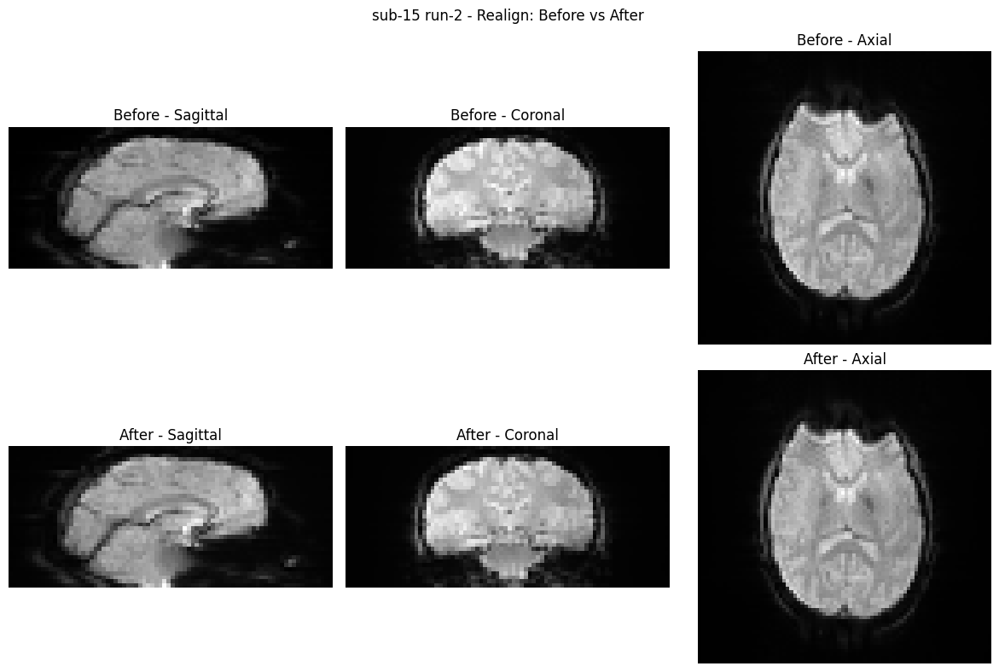

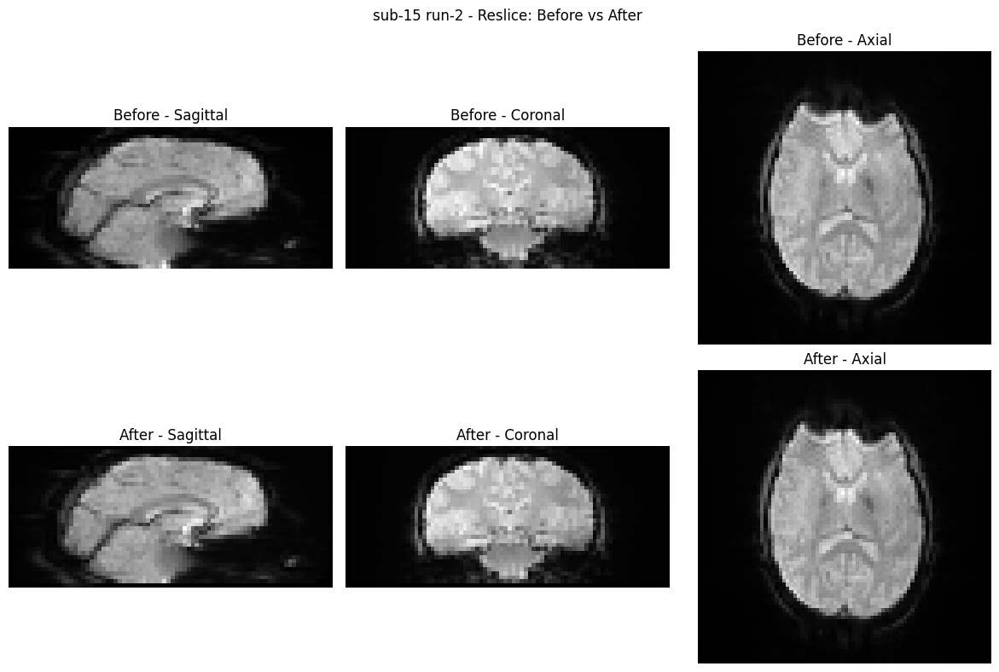

[31/66] sub-16 run-1


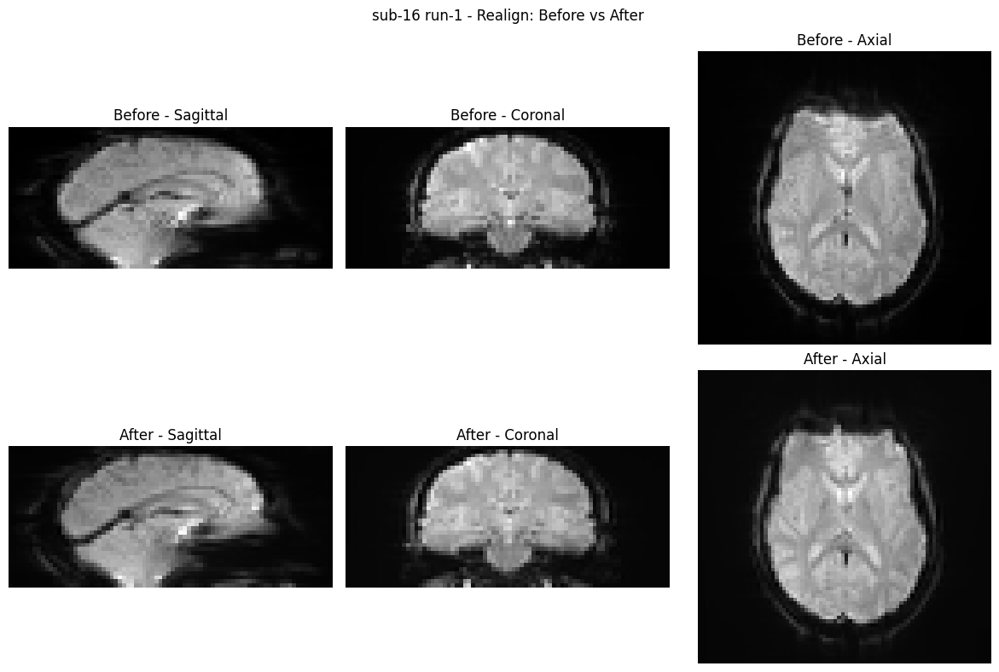

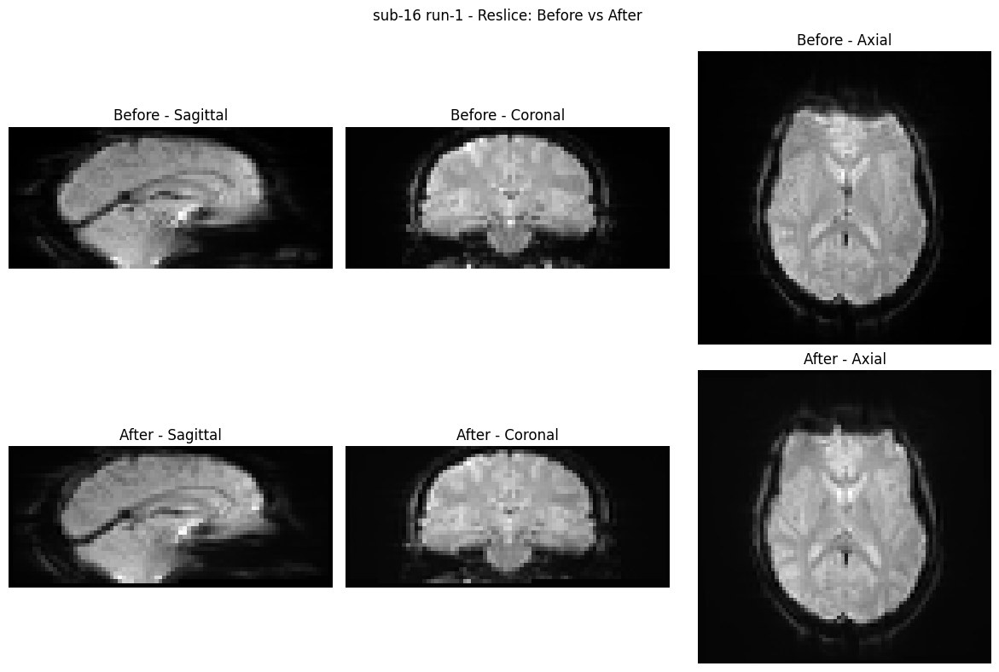

[32/66] sub-16 run-2


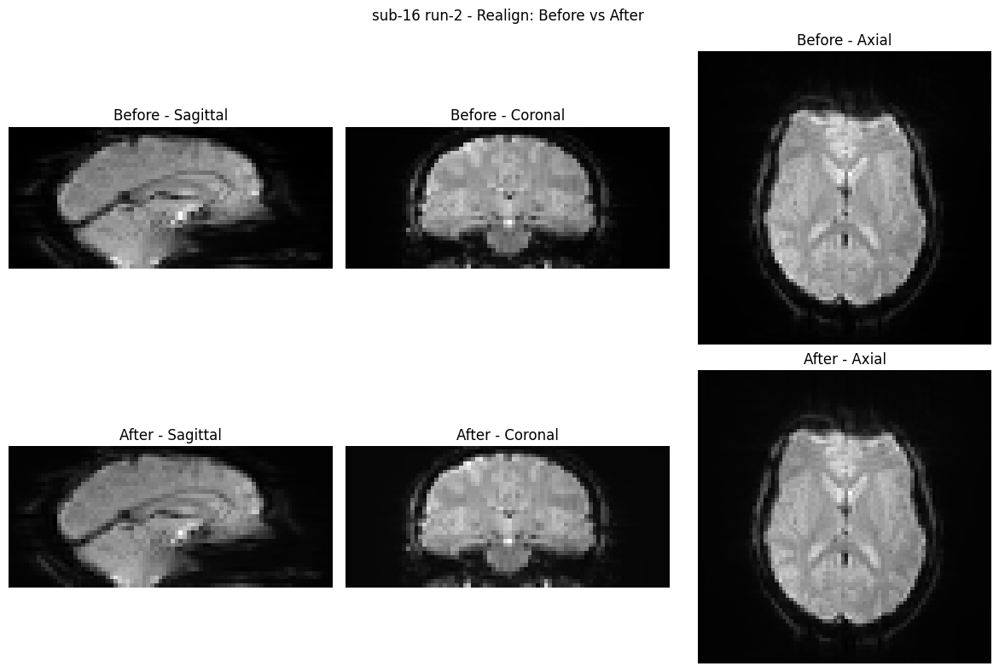

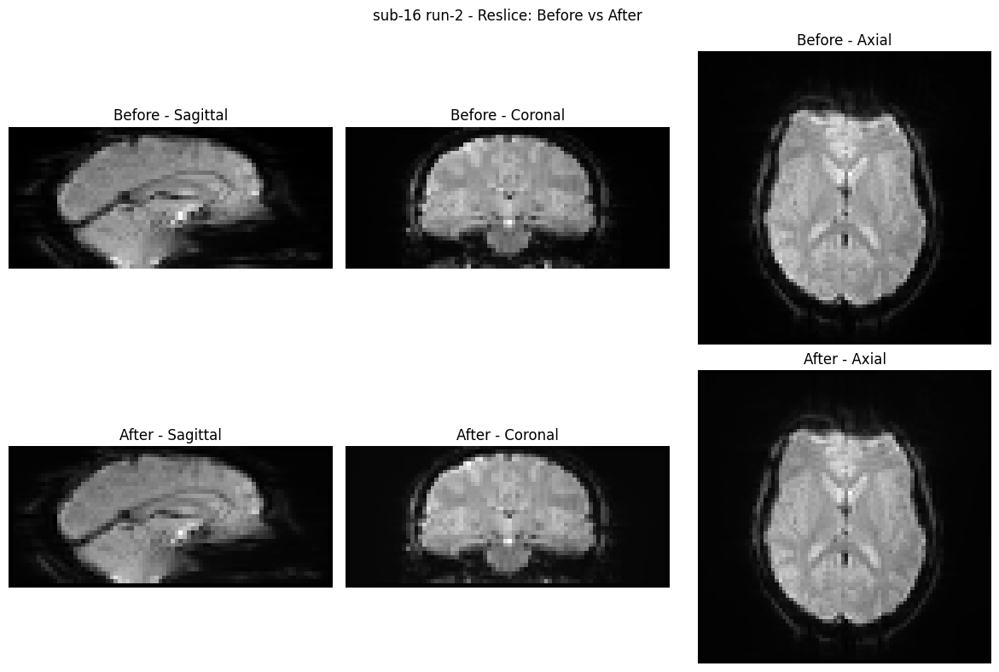

[33/66] sub-17 run-1


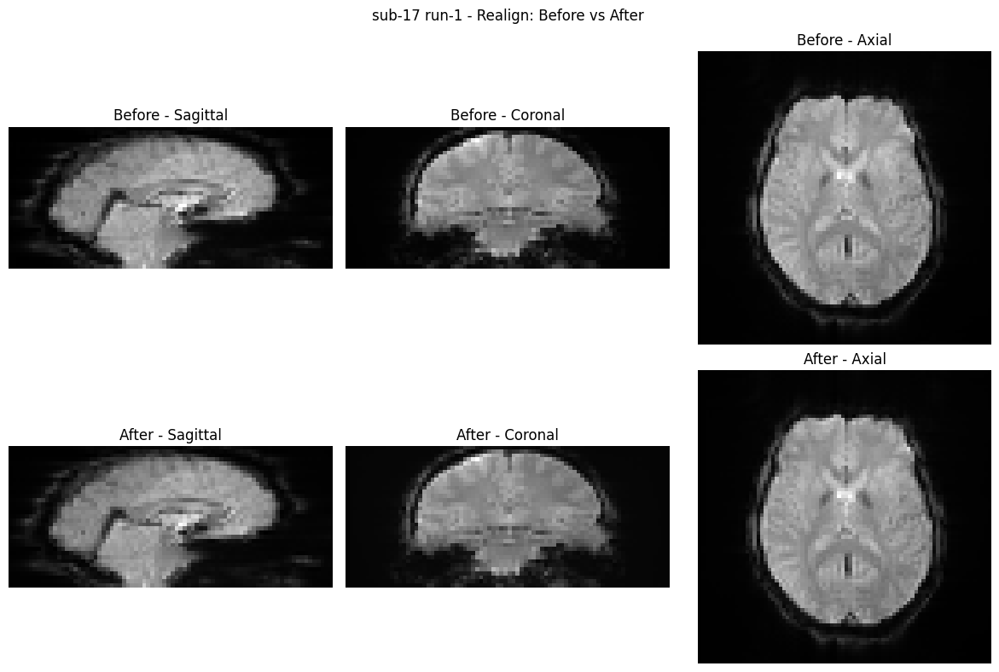

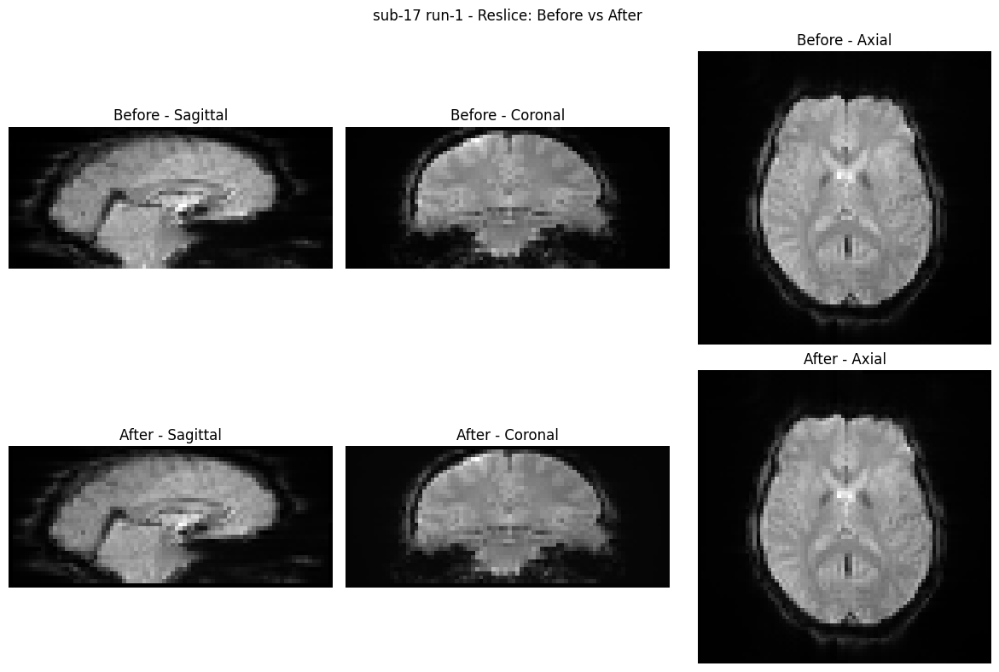

[34/66] sub-17 run-2


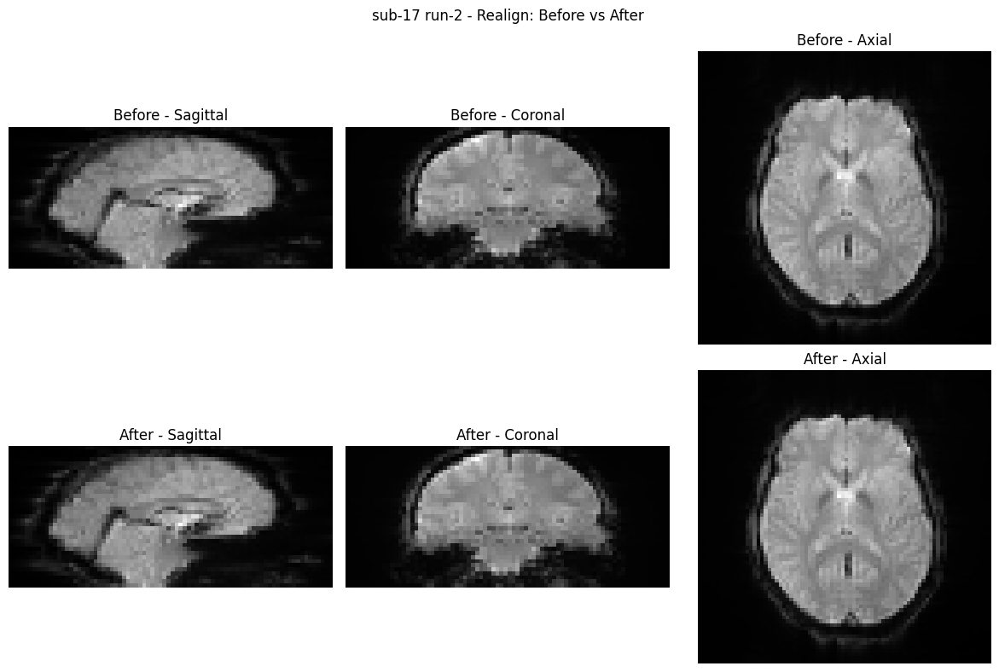

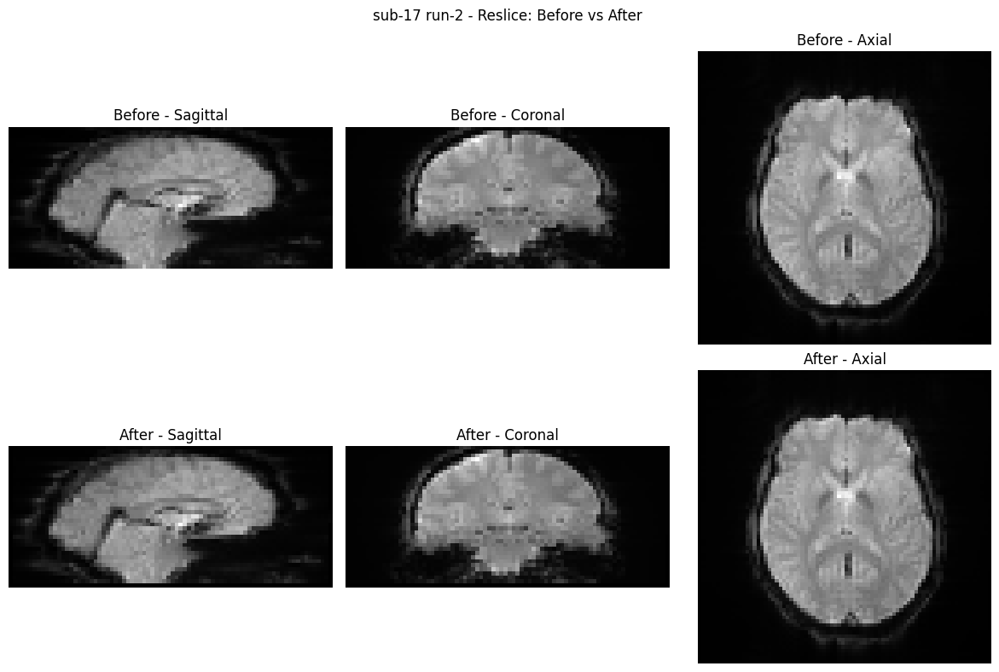

[35/66] sub-18 run-1


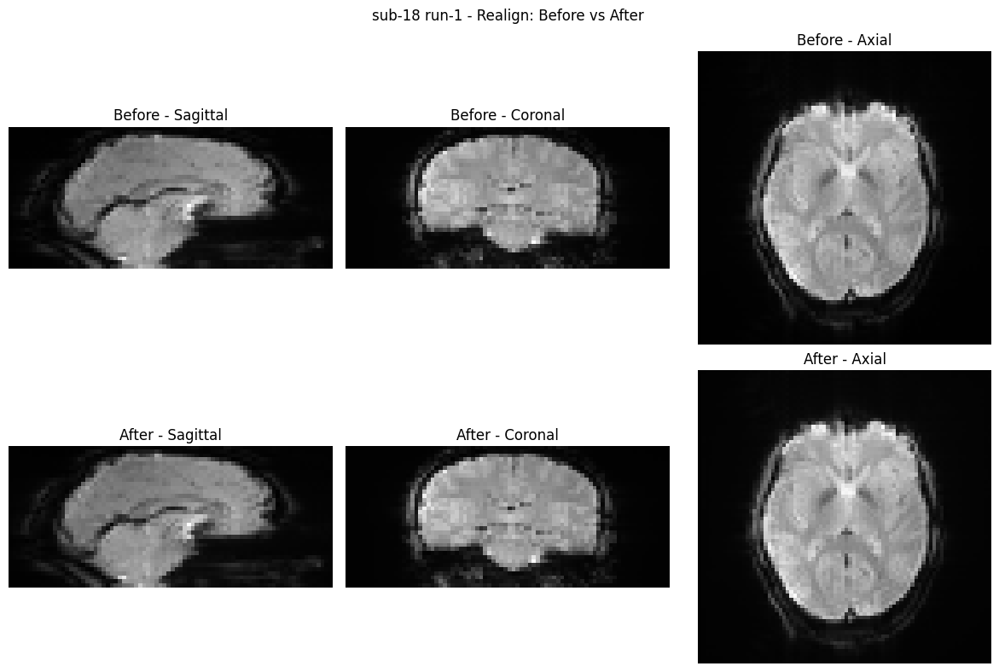

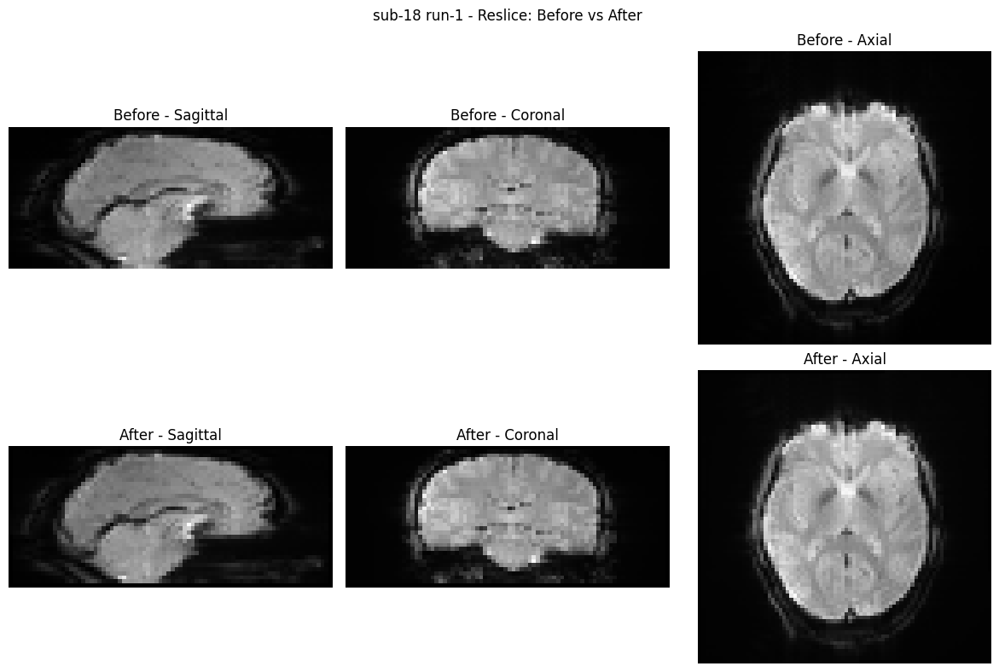

[36/66] sub-18 run-2


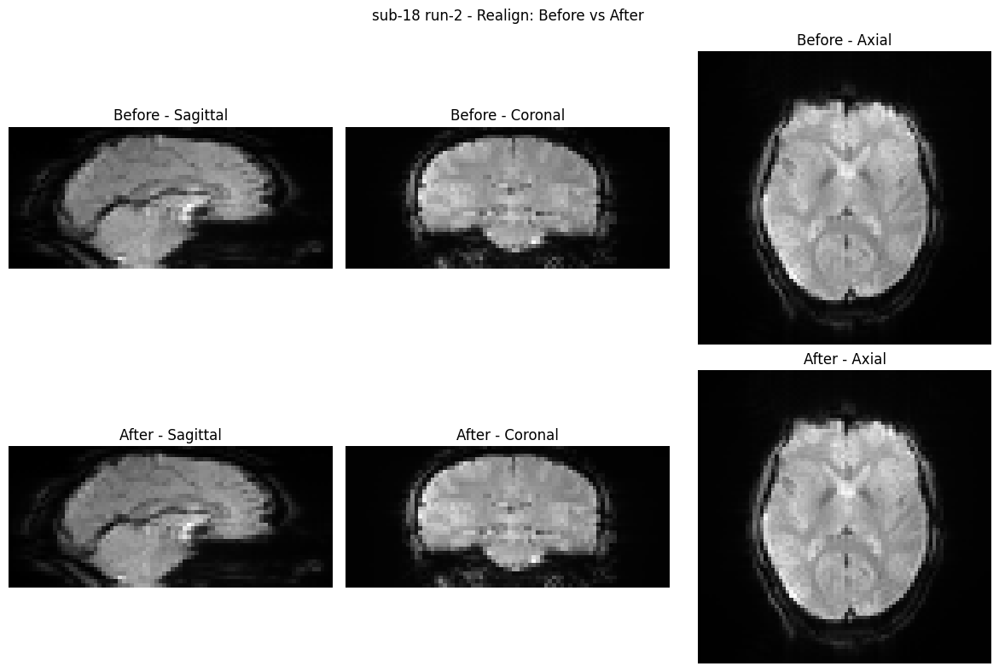

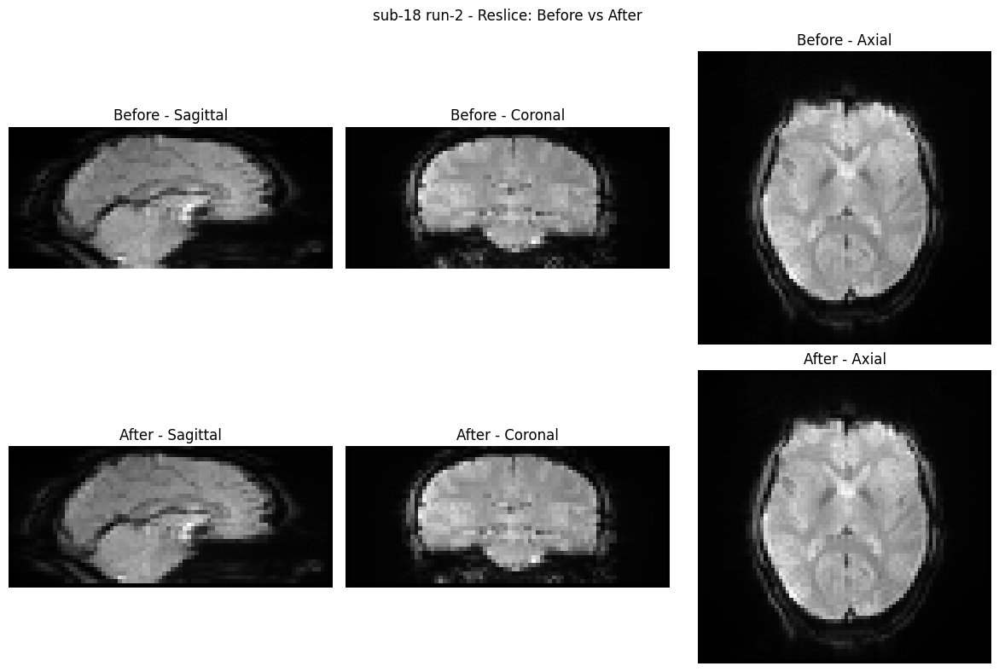

[37/66] sub-19 run-1


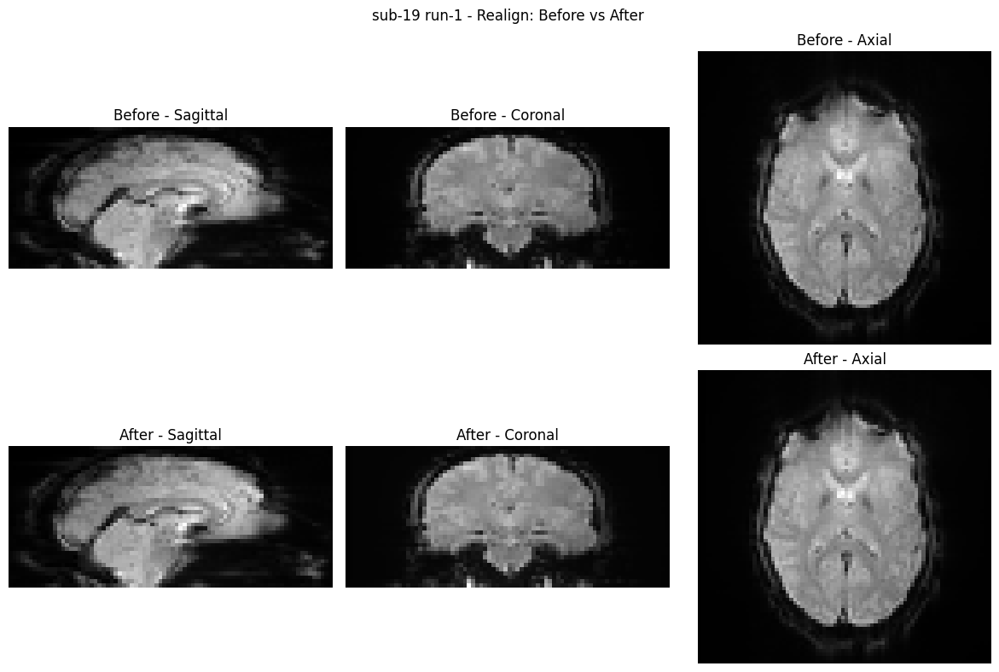

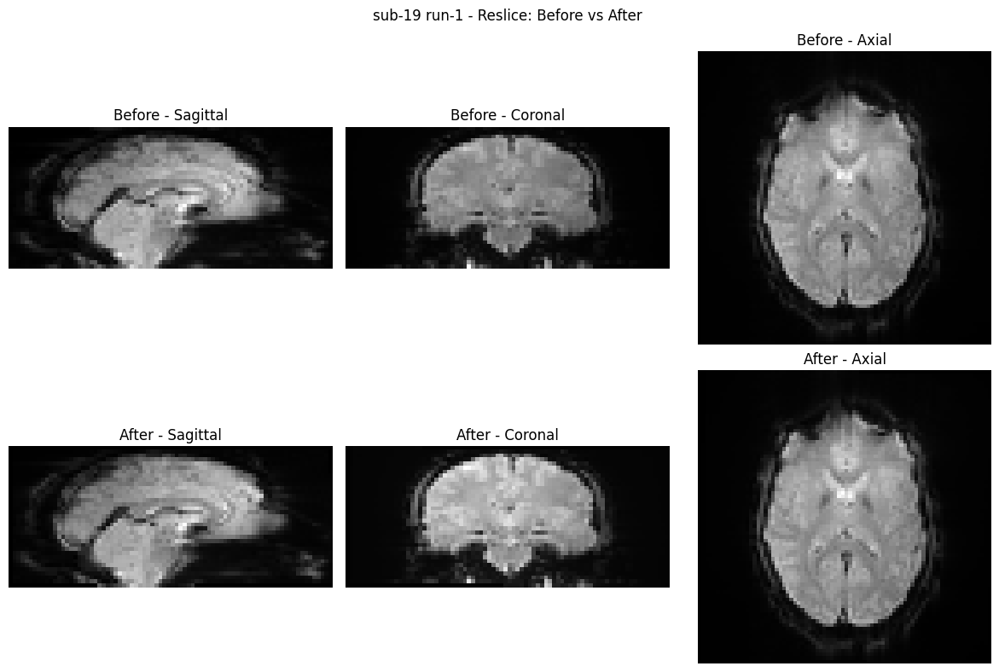

[38/66] sub-19 run-2


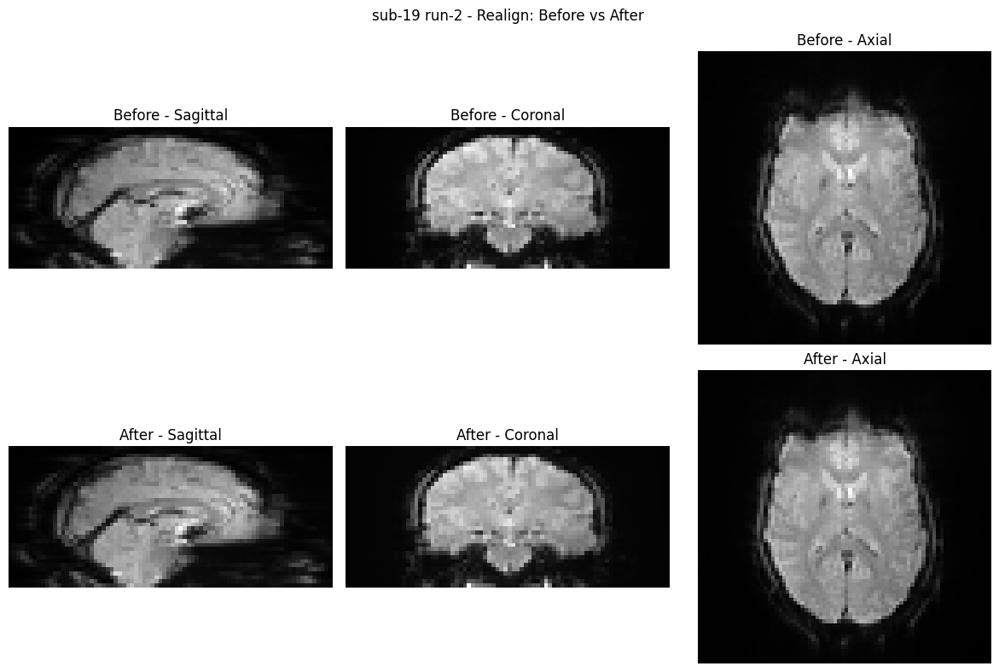

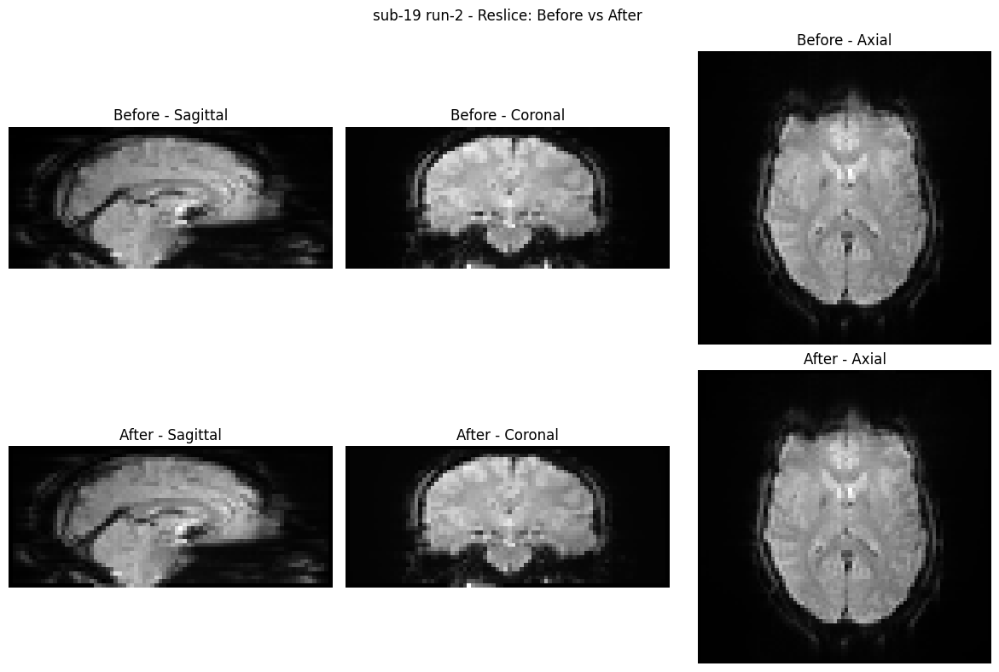

[39/66] sub-20 run-1


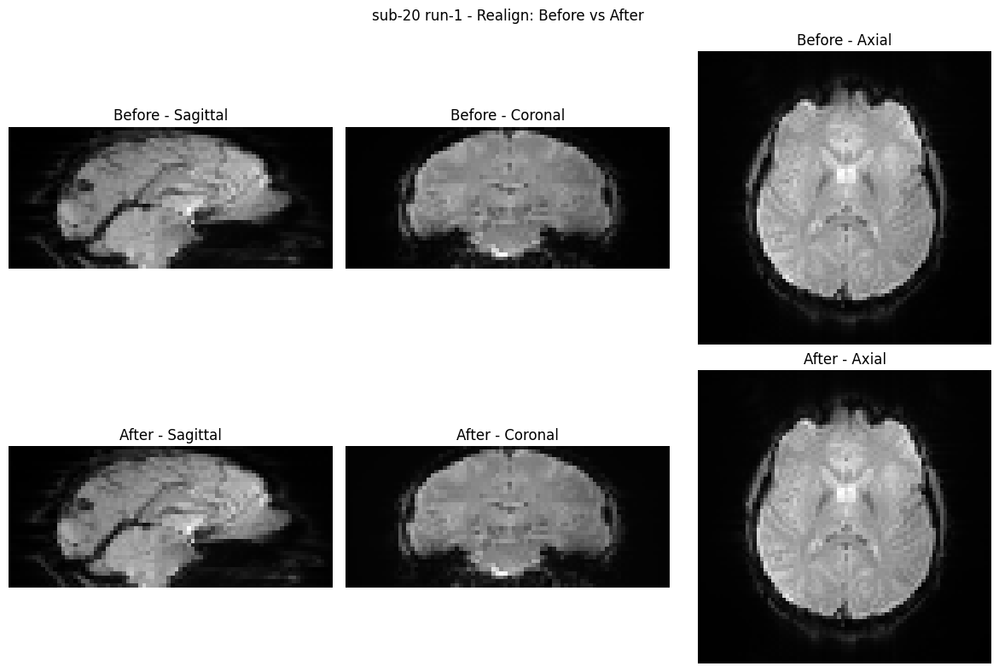

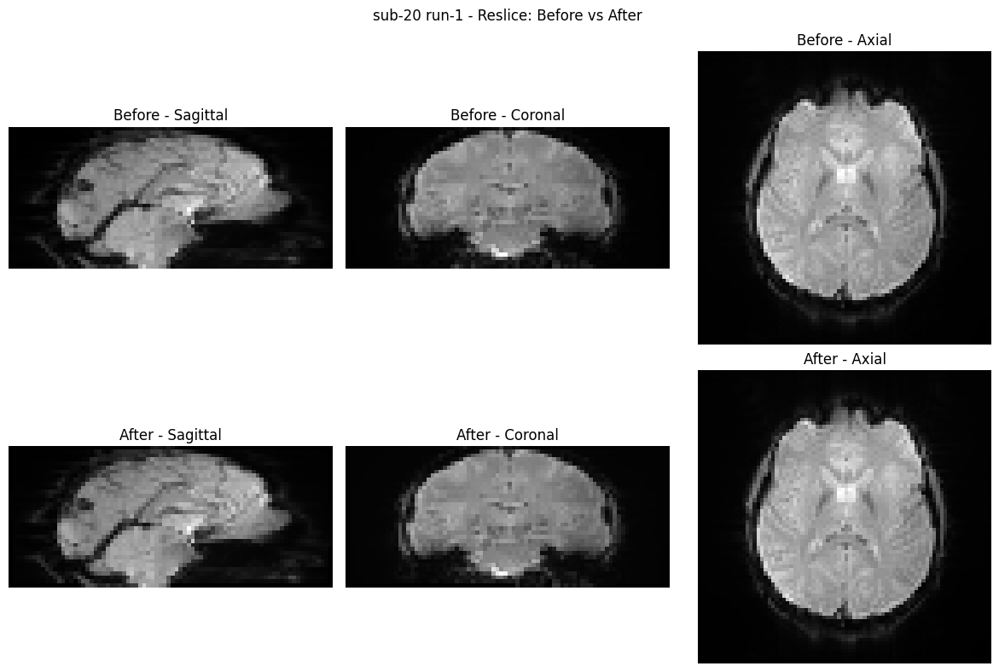

[40/66] sub-20 run-2


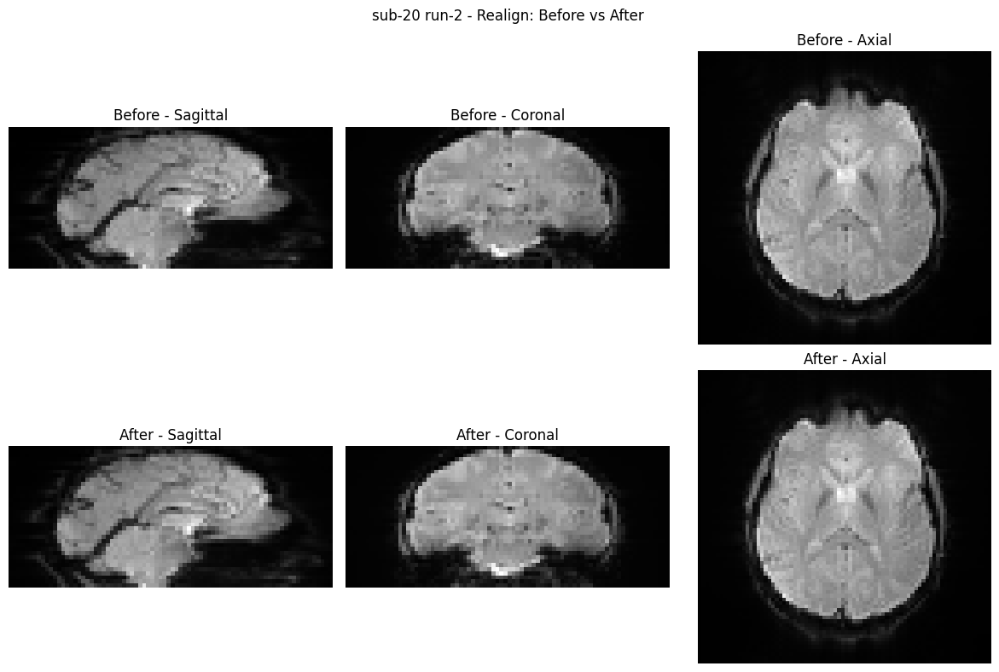

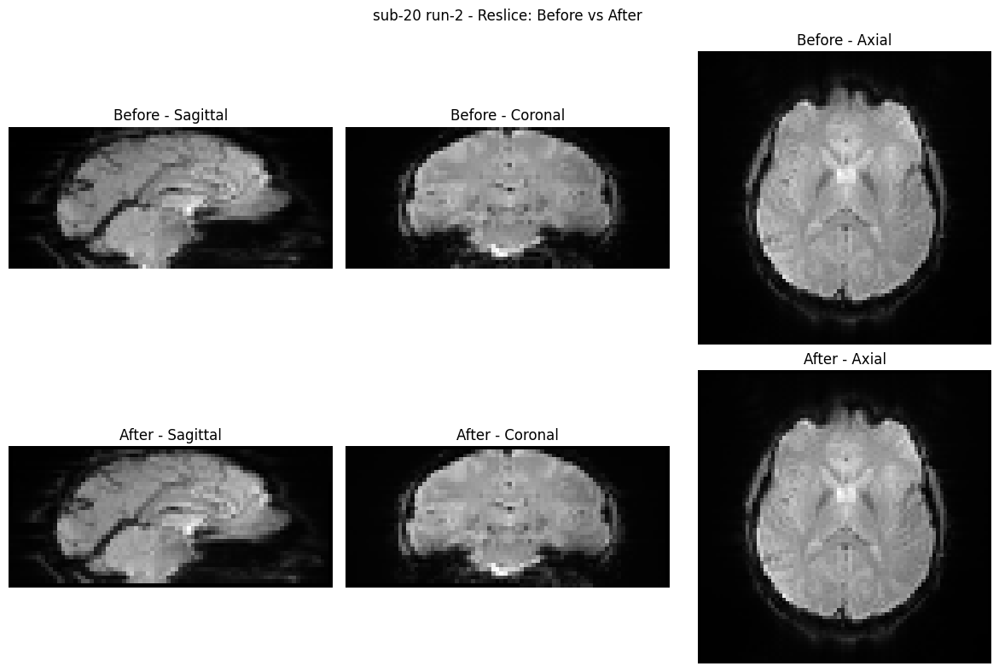

[41/66] sub-21 run-1


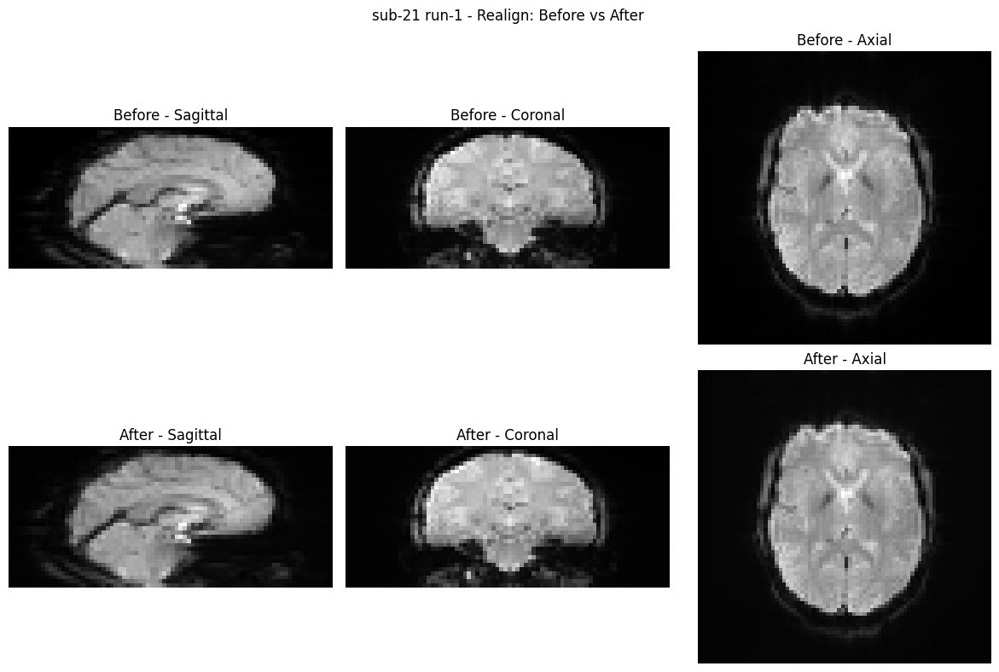

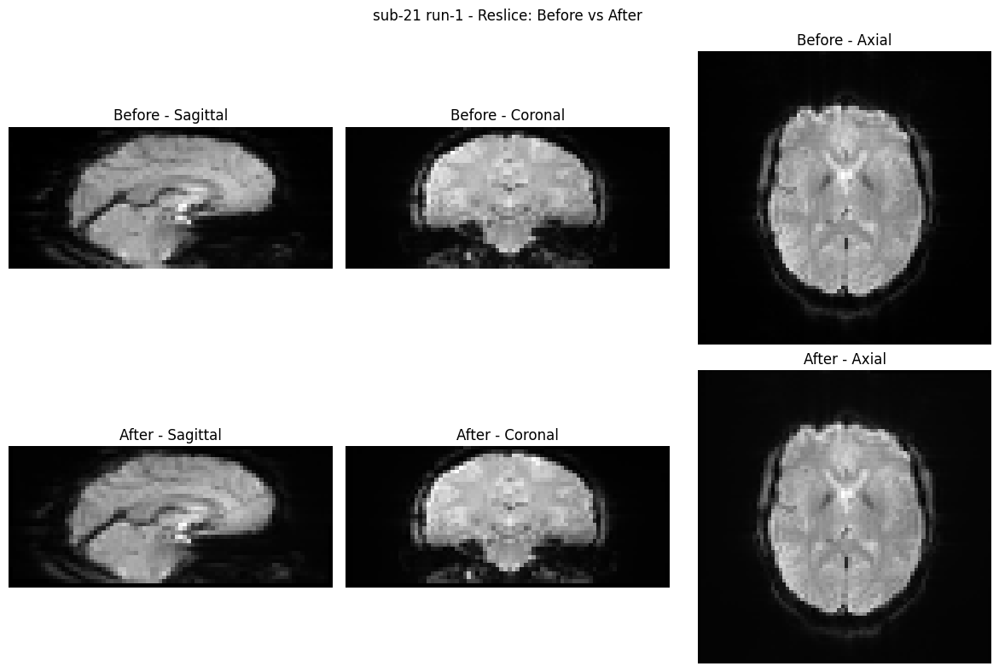

[42/66] sub-21 run-2


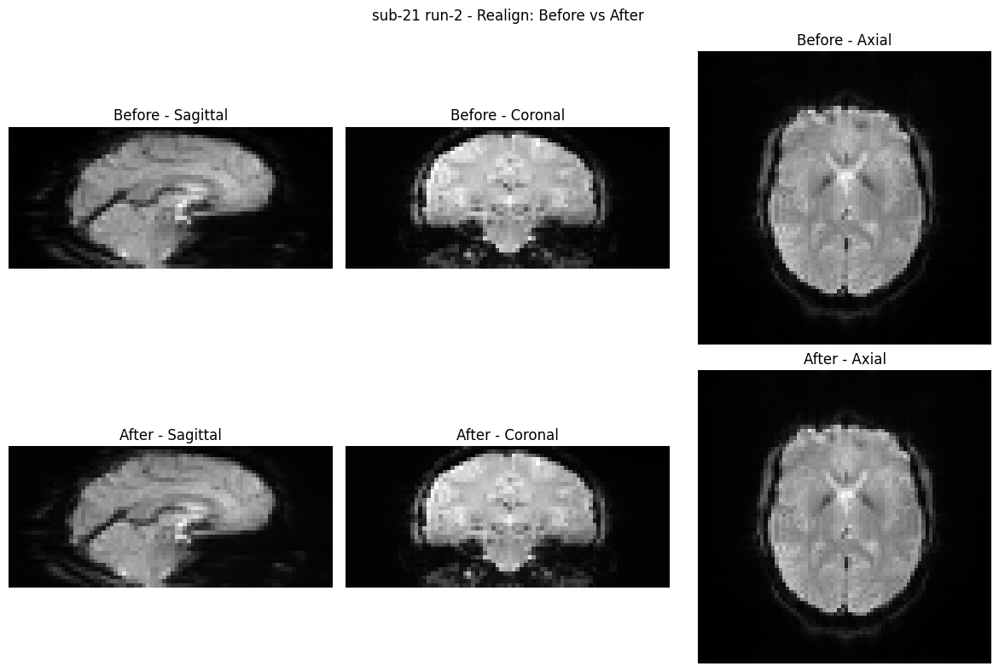

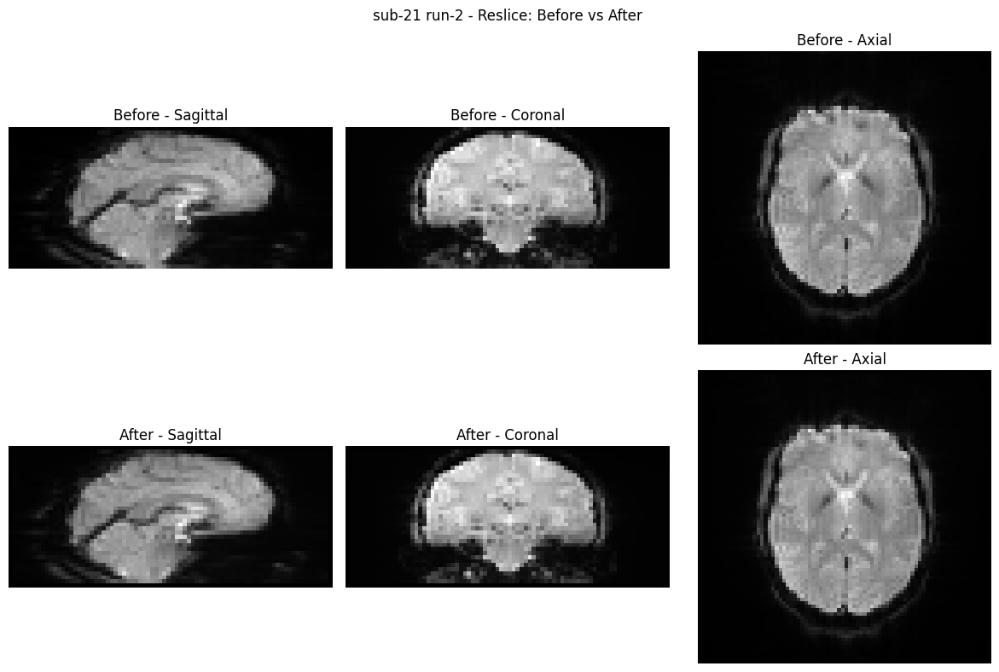

[43/66] sub-22 run-1


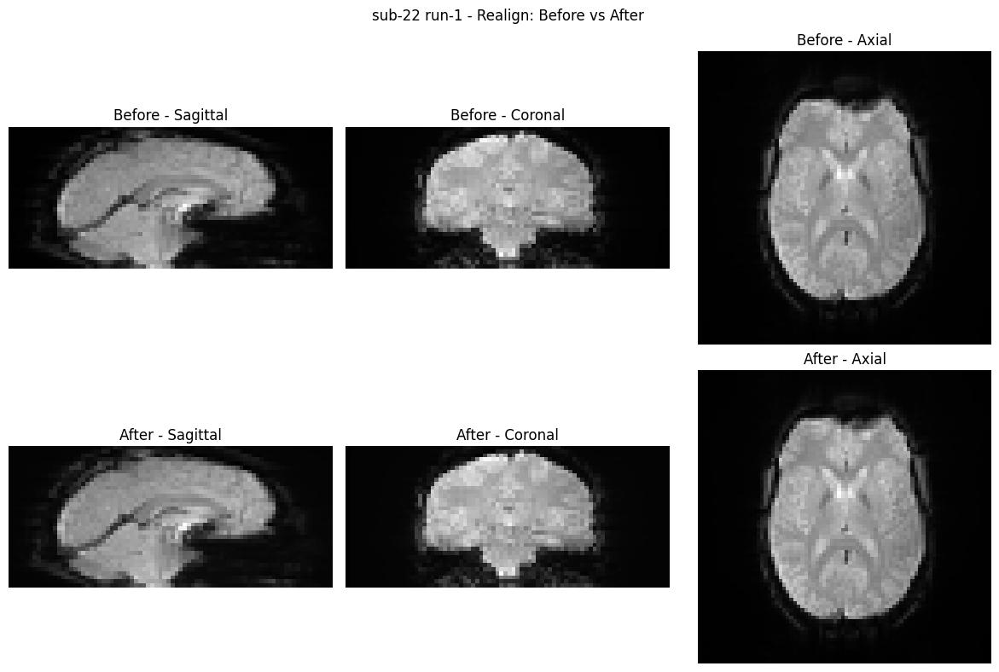

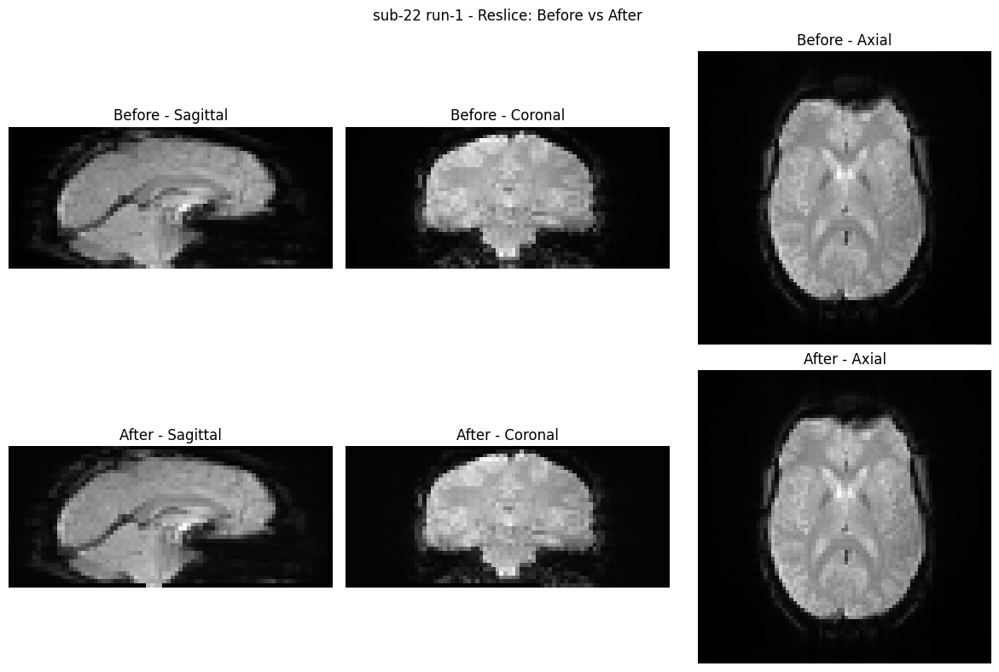

[44/66] sub-22 run-2


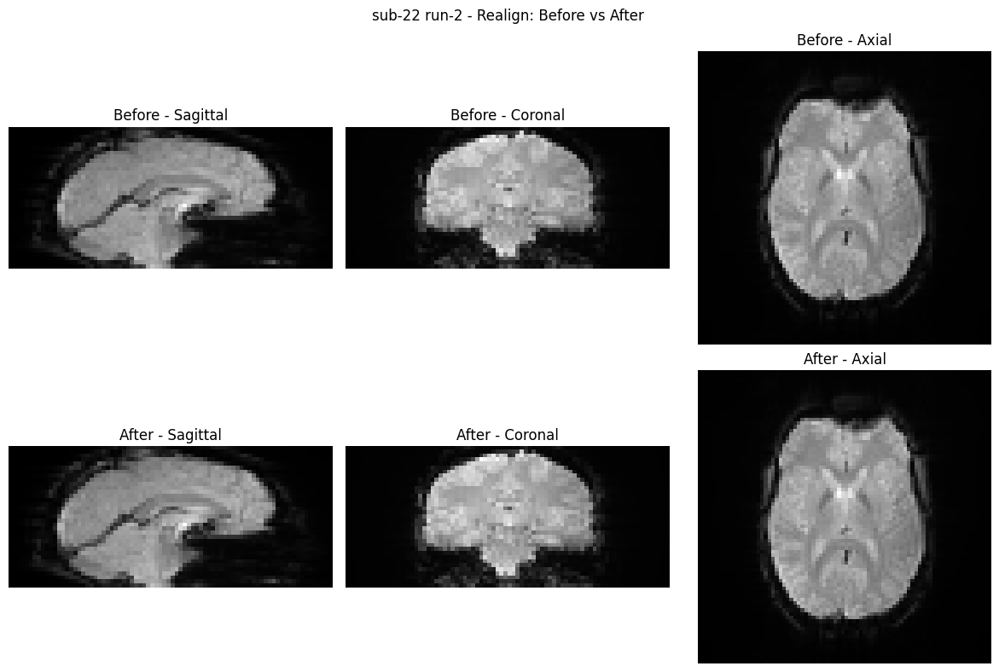

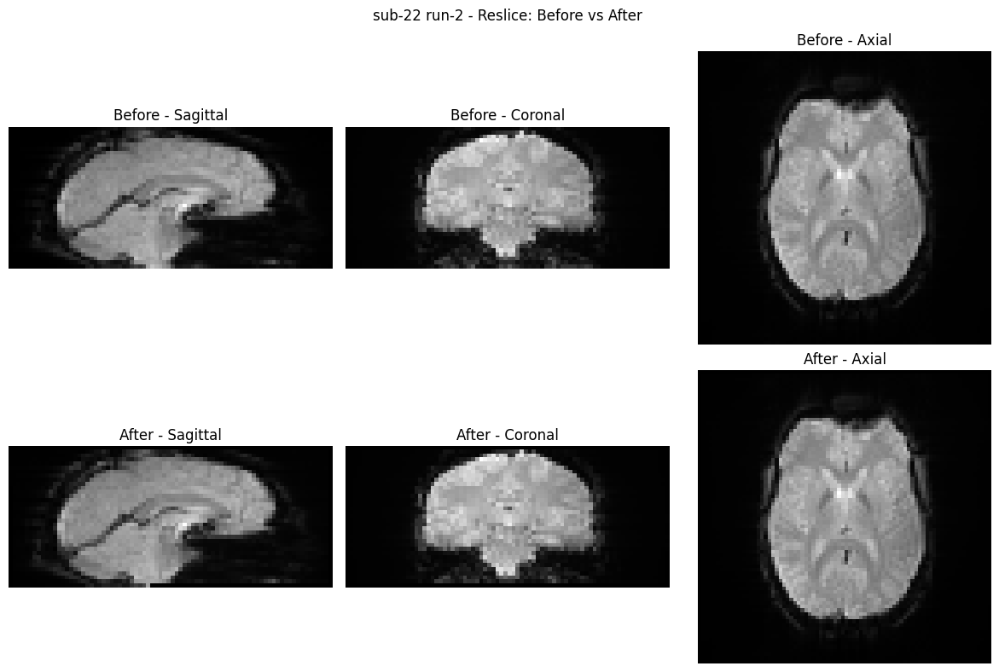

[45/66] sub-23 run-1


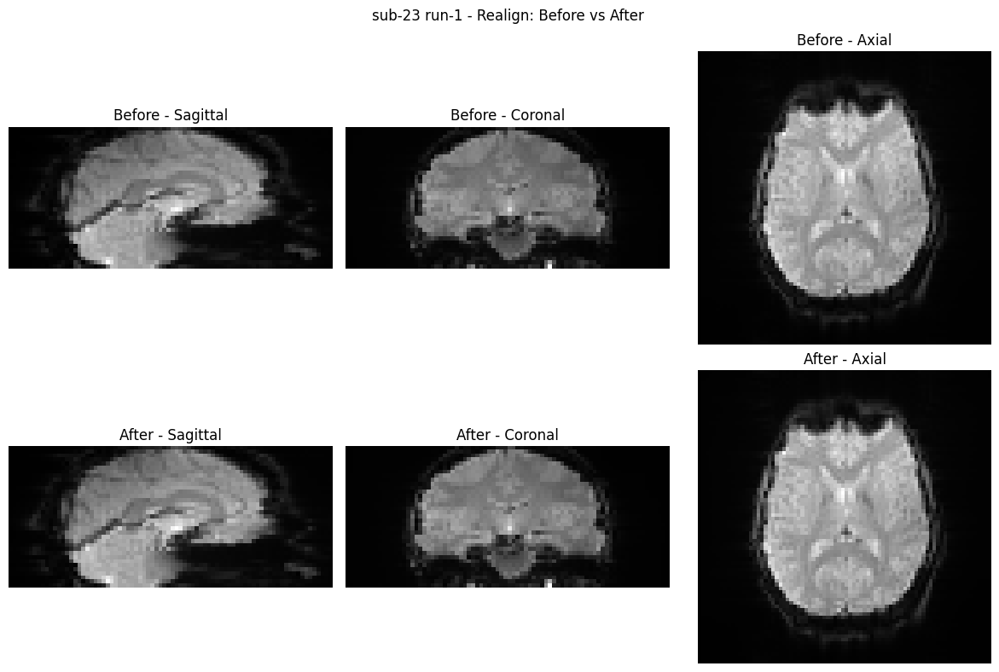

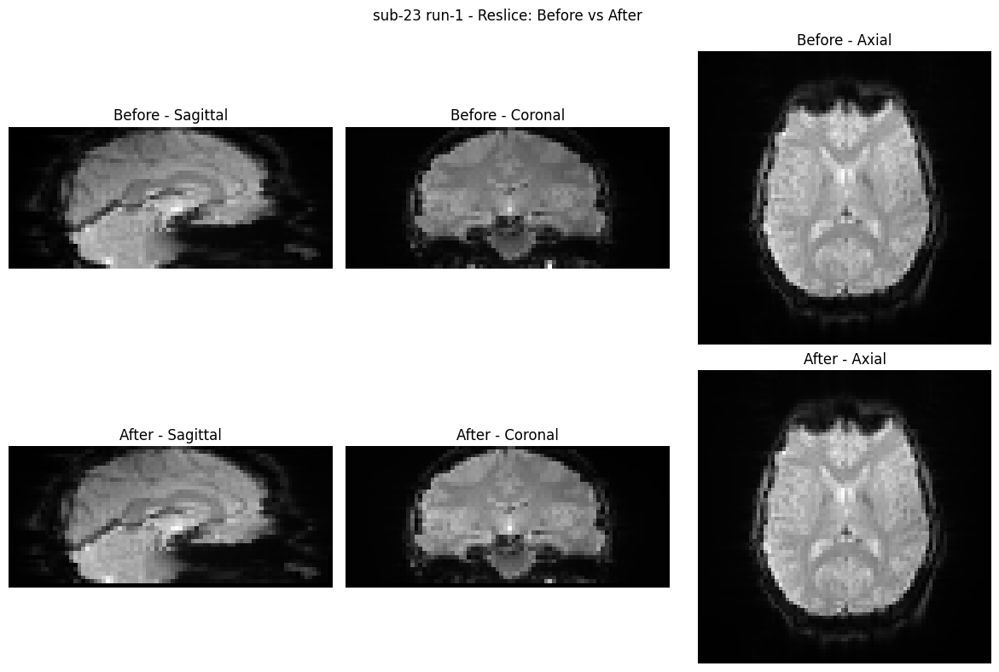

[46/66] sub-23 run-2


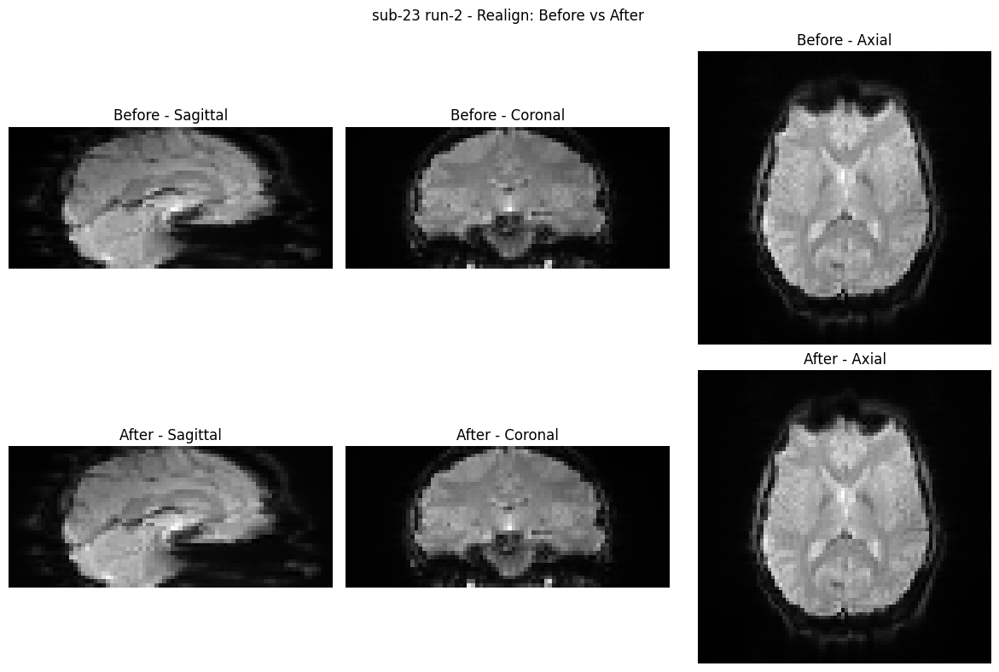

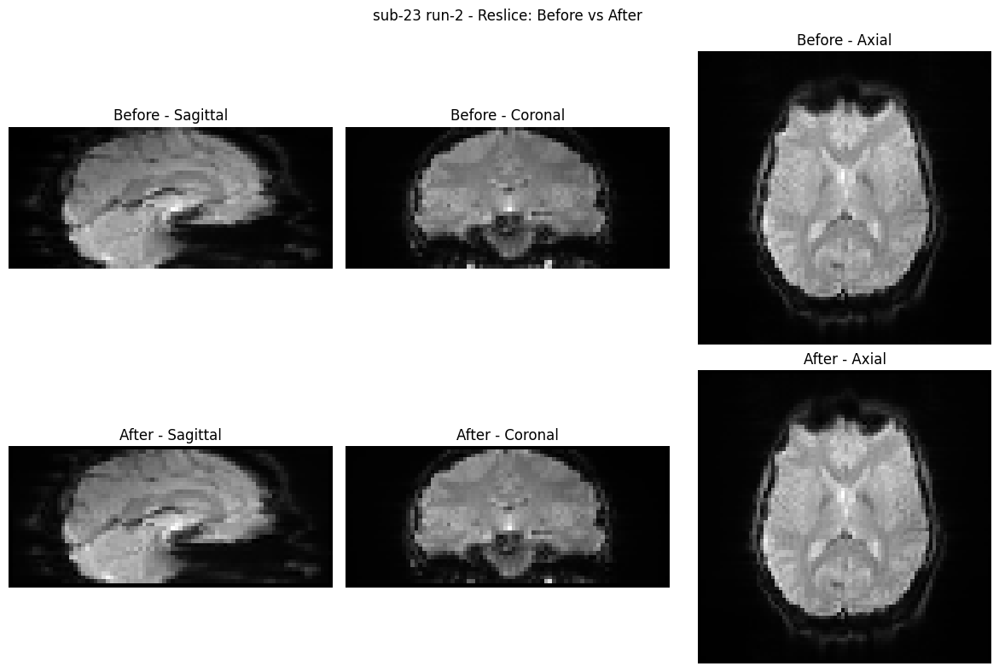

[47/66] sub-24 run-1


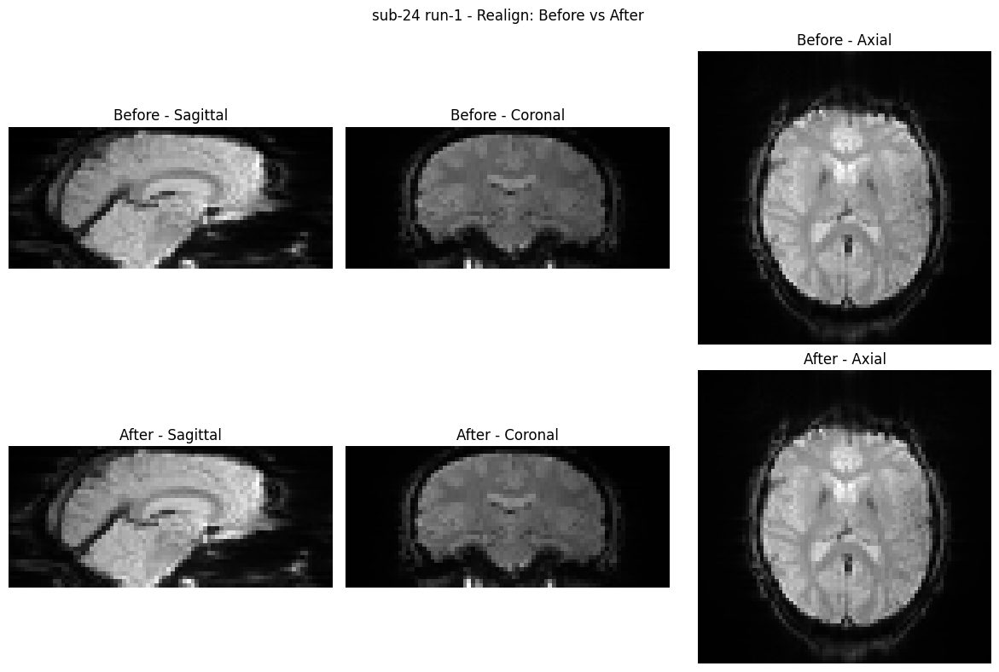

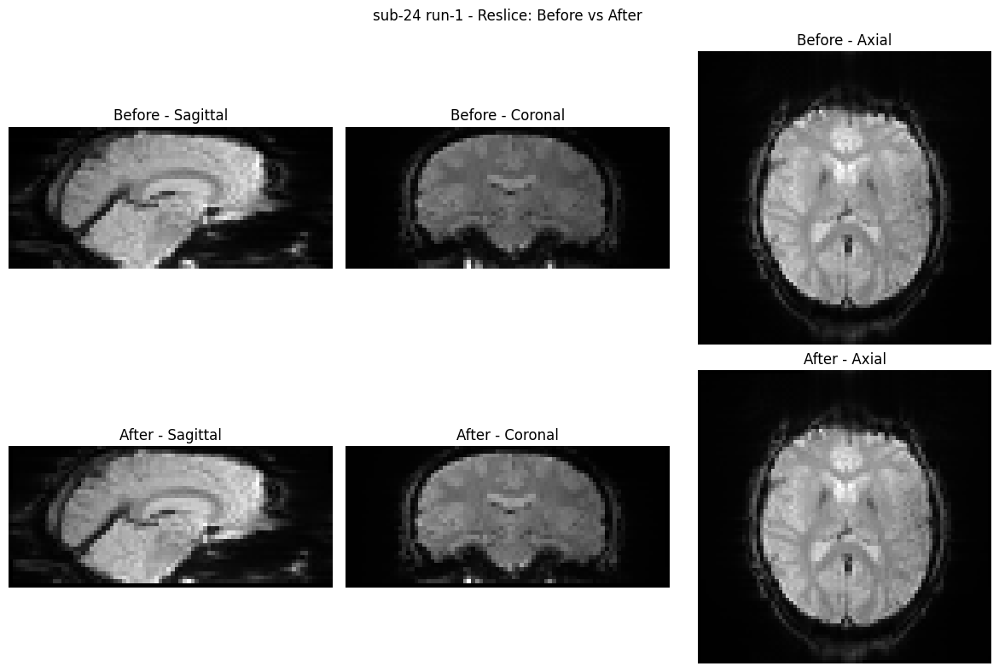

[48/66] sub-24 run-2


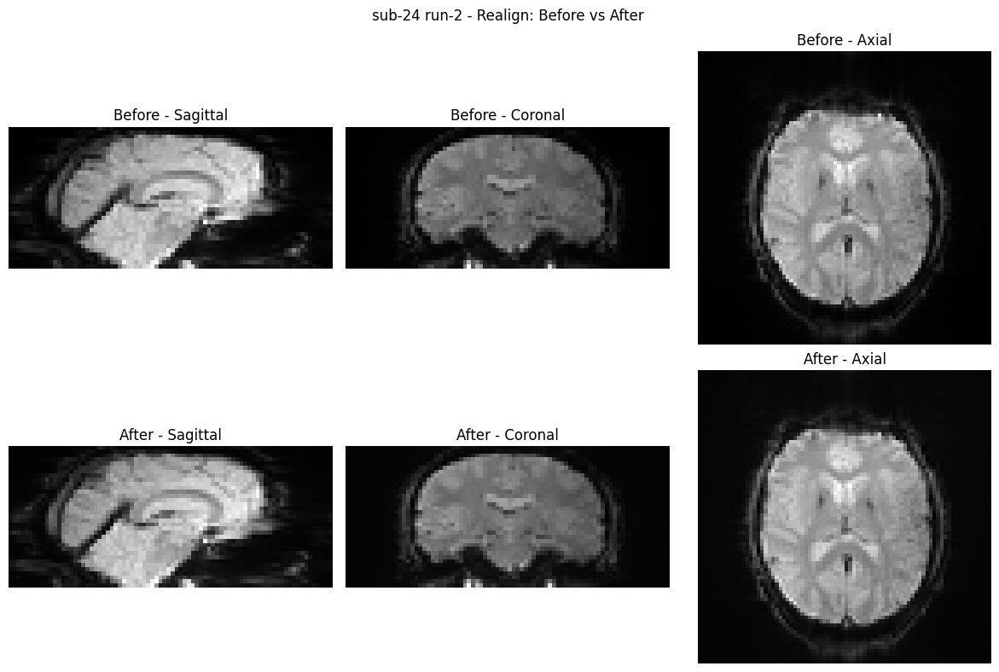

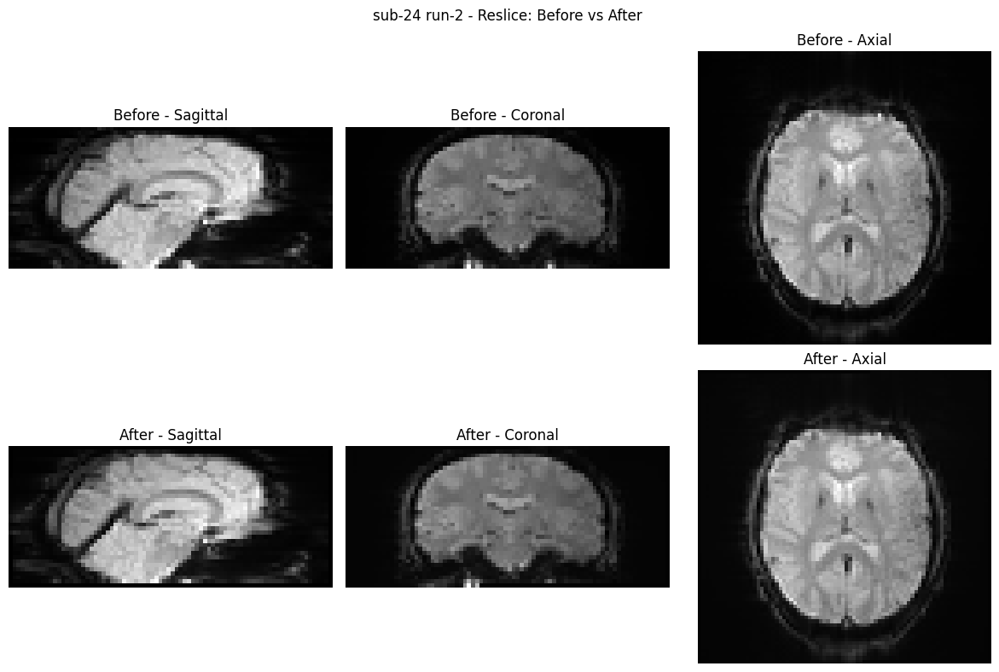

[49/66] sub-25 run-1


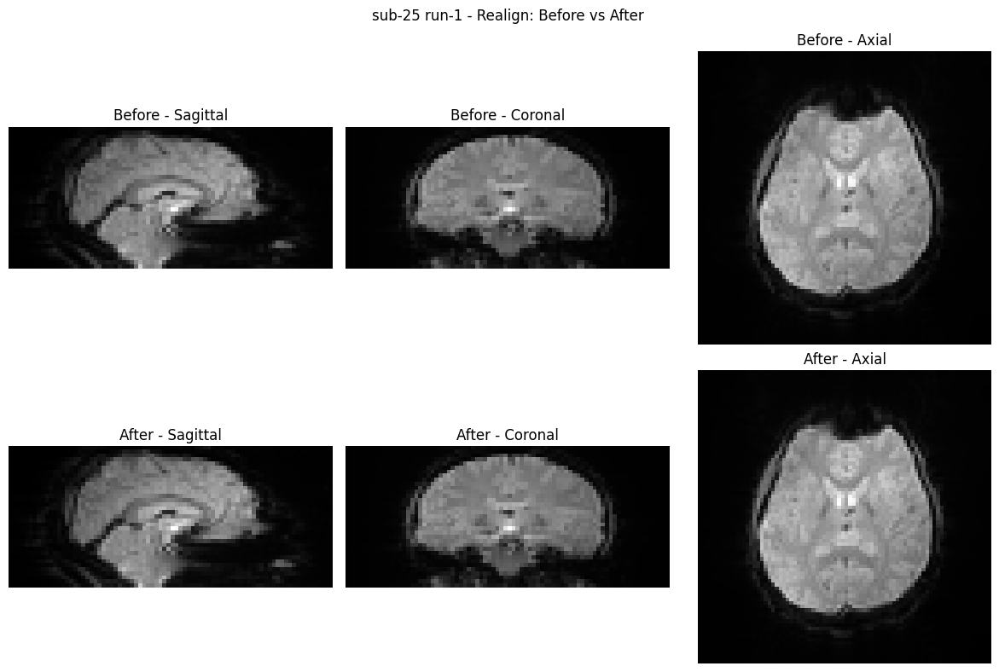

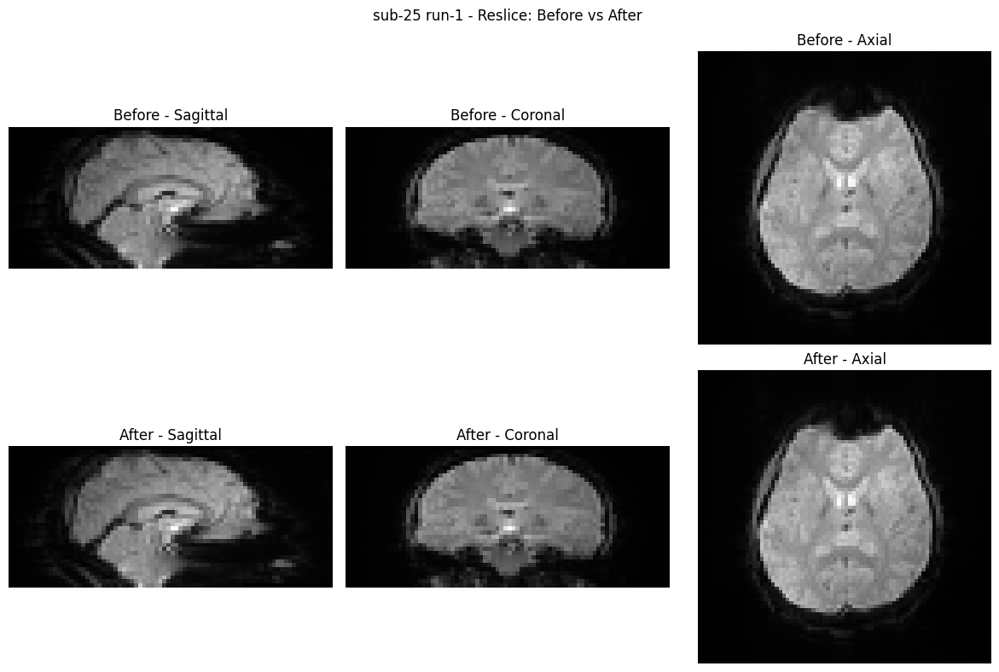

[50/66] sub-25 run-2


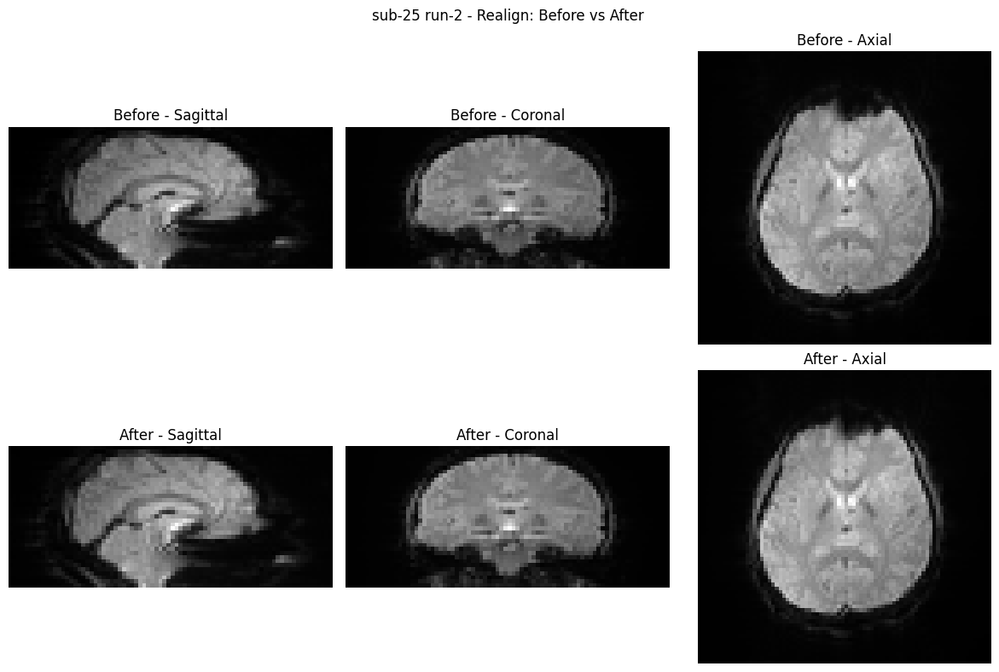

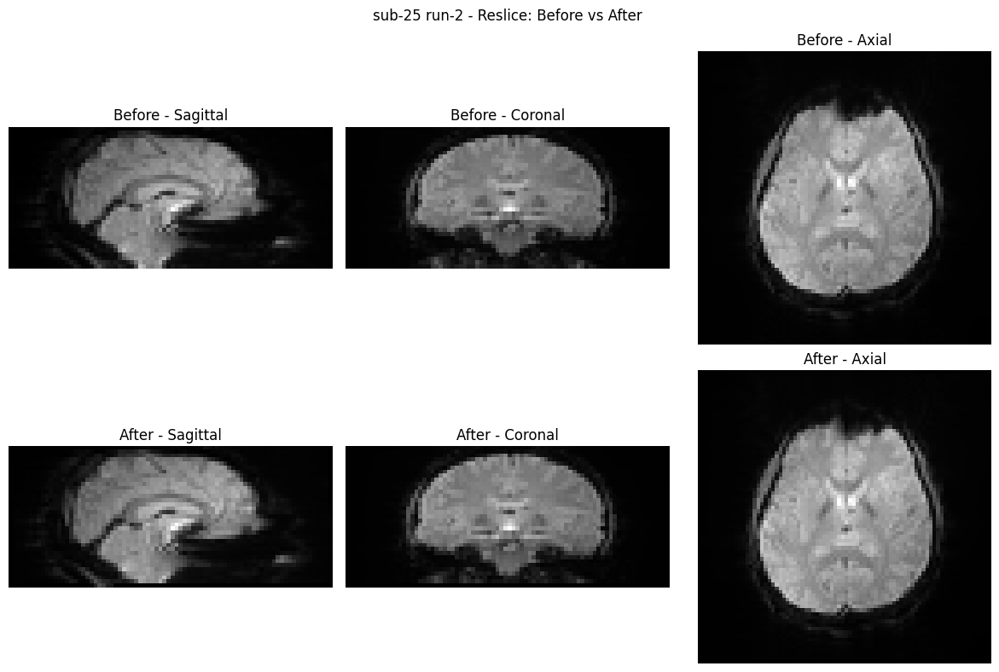

[51/66] sub-26 run-1


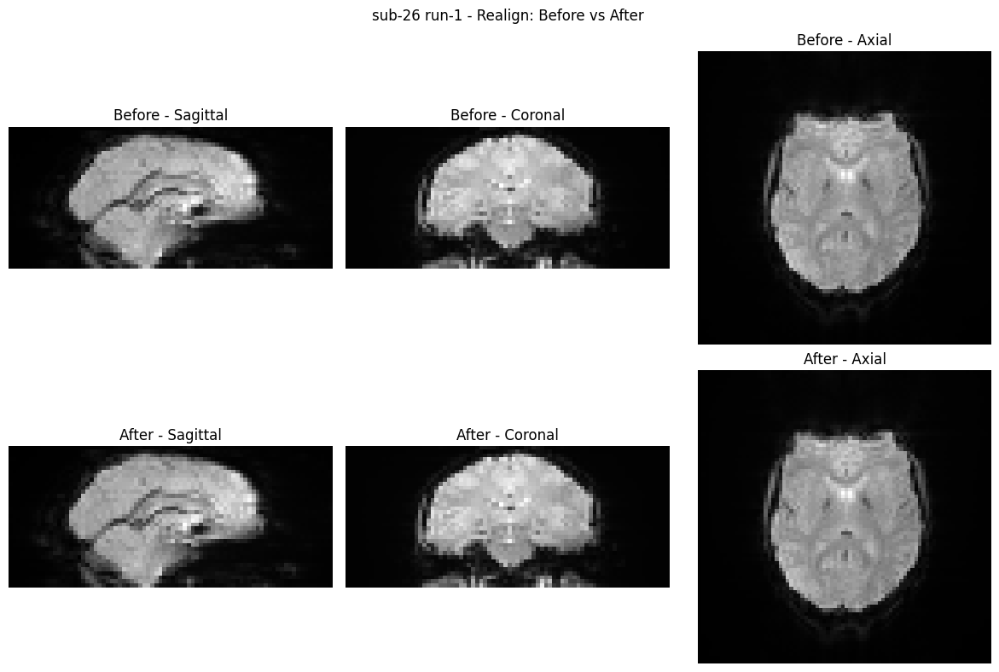

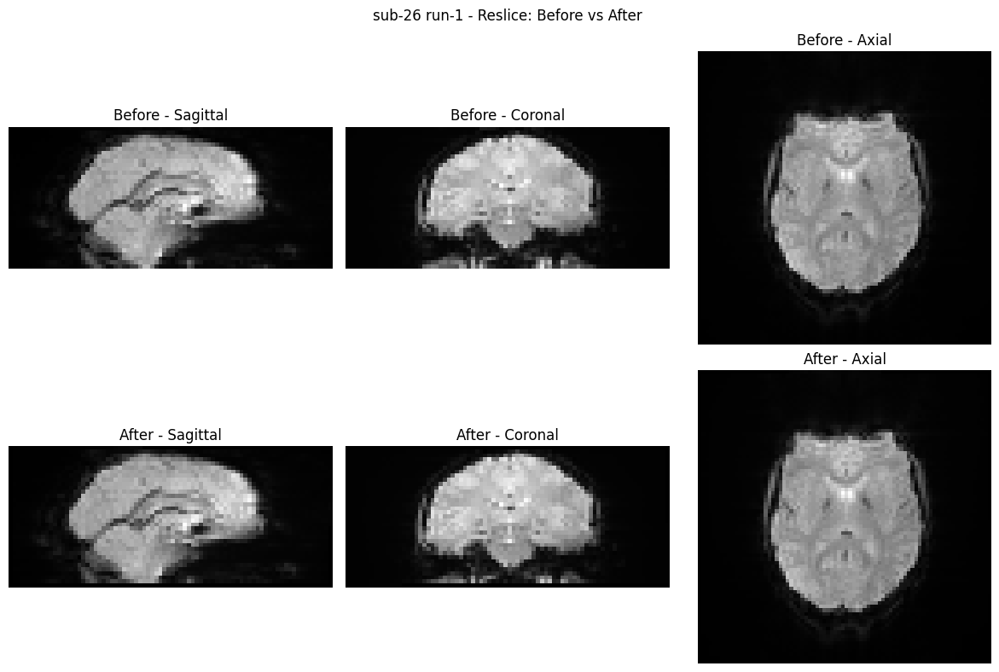

[52/66] sub-26 run-2


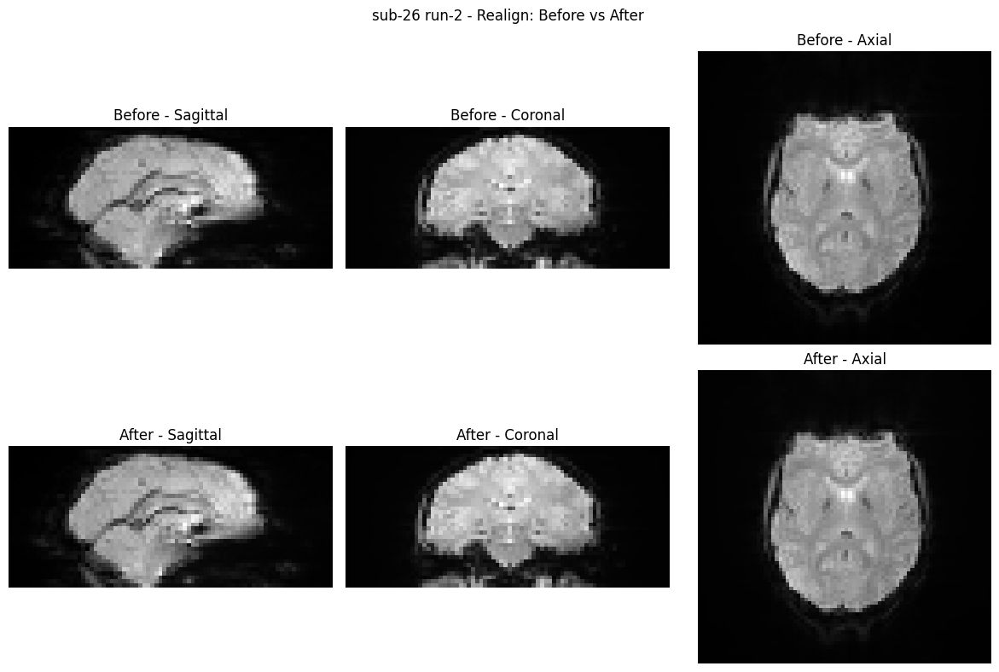

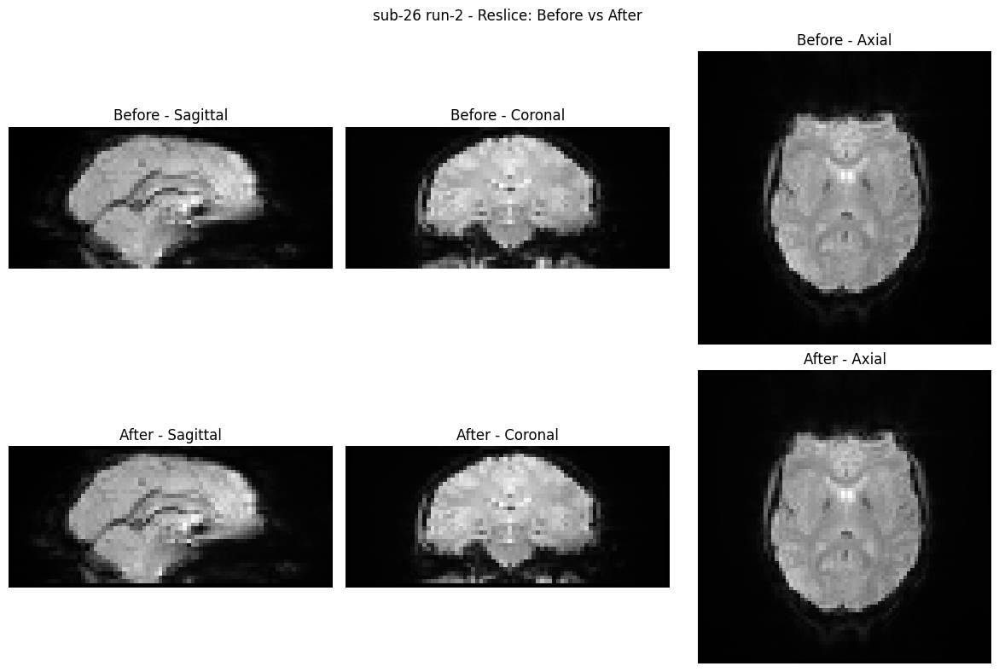

[53/66] sub-27 run-1


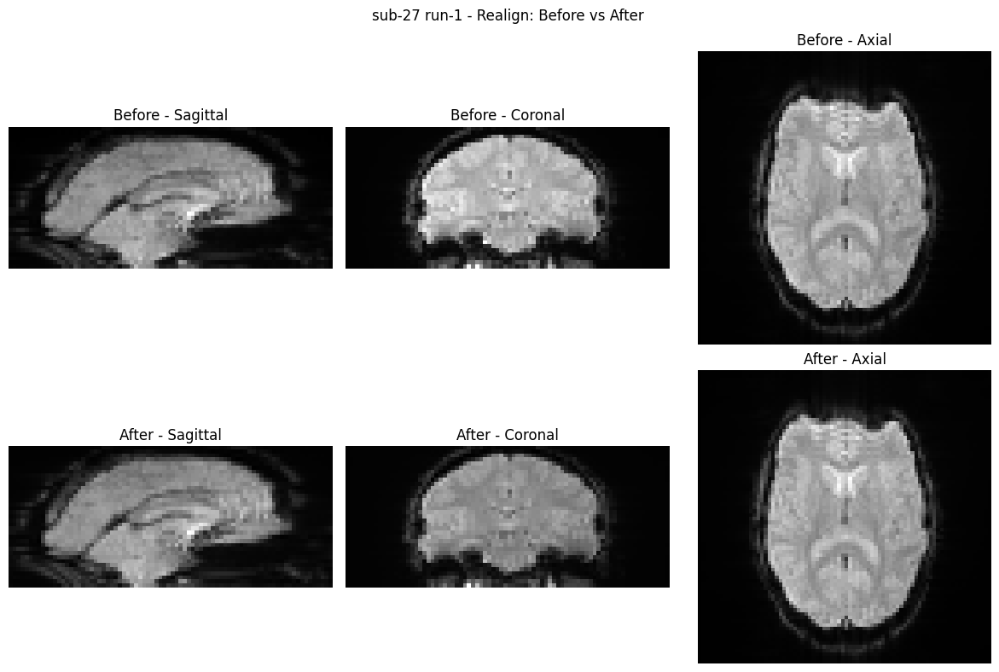

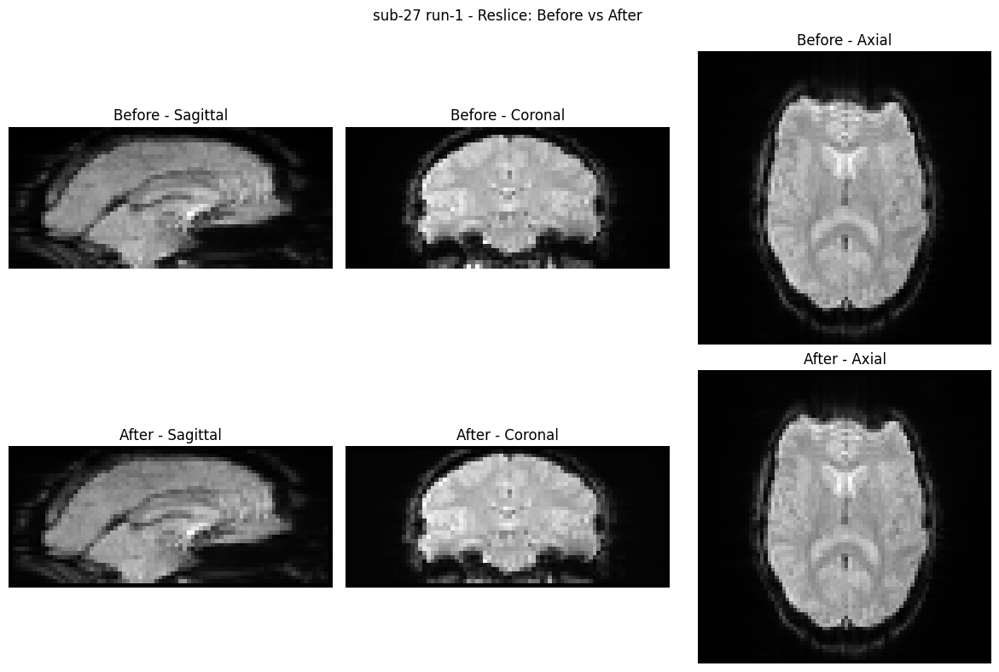

[54/66] sub-27 run-2


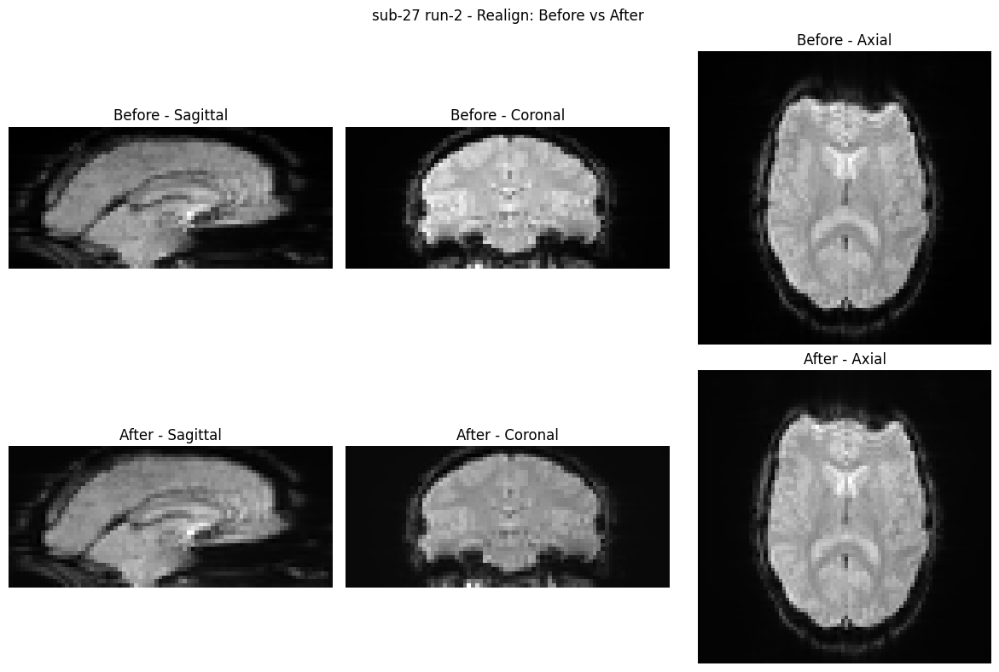

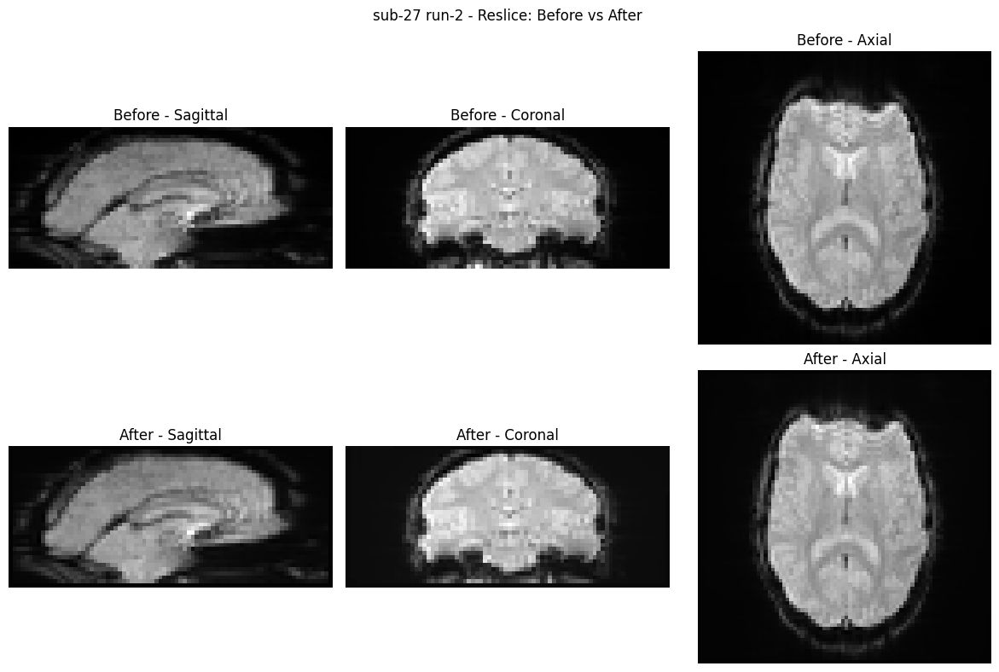

[55/66] sub-28 run-1


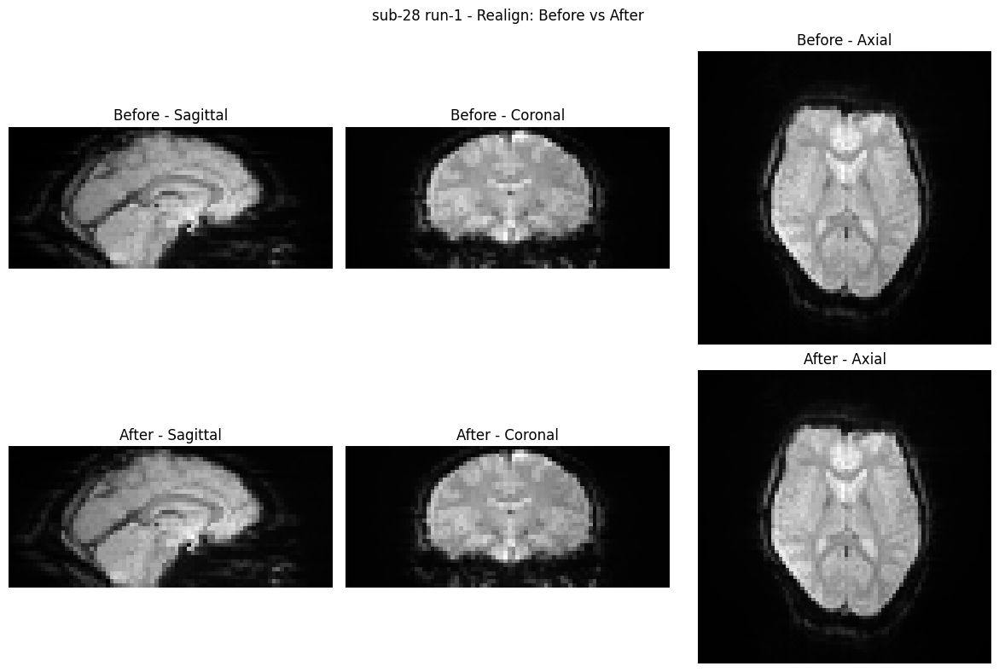

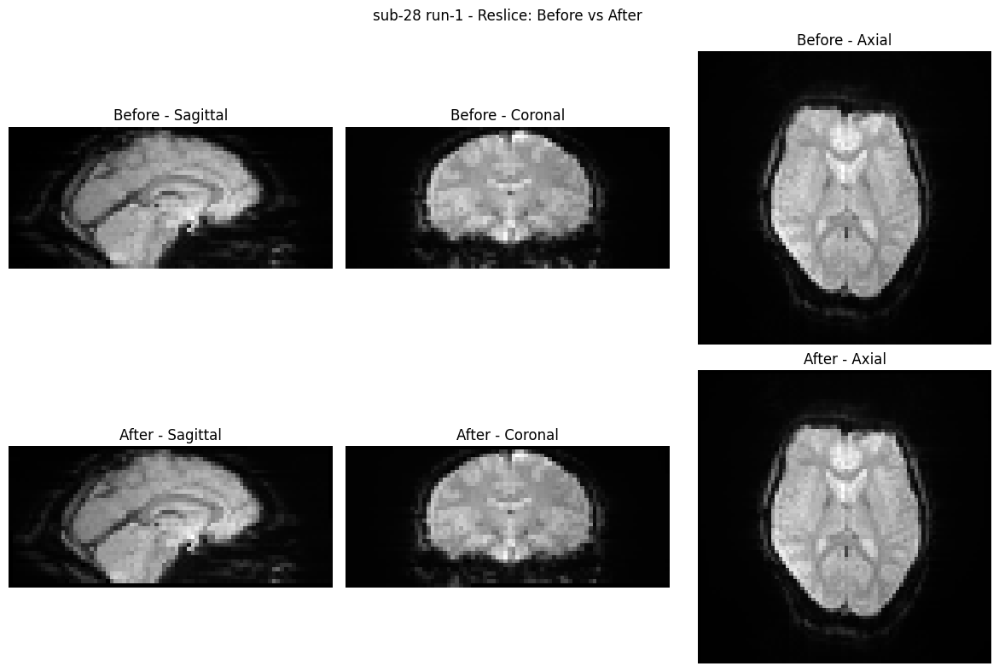

[56/66] sub-28 run-2


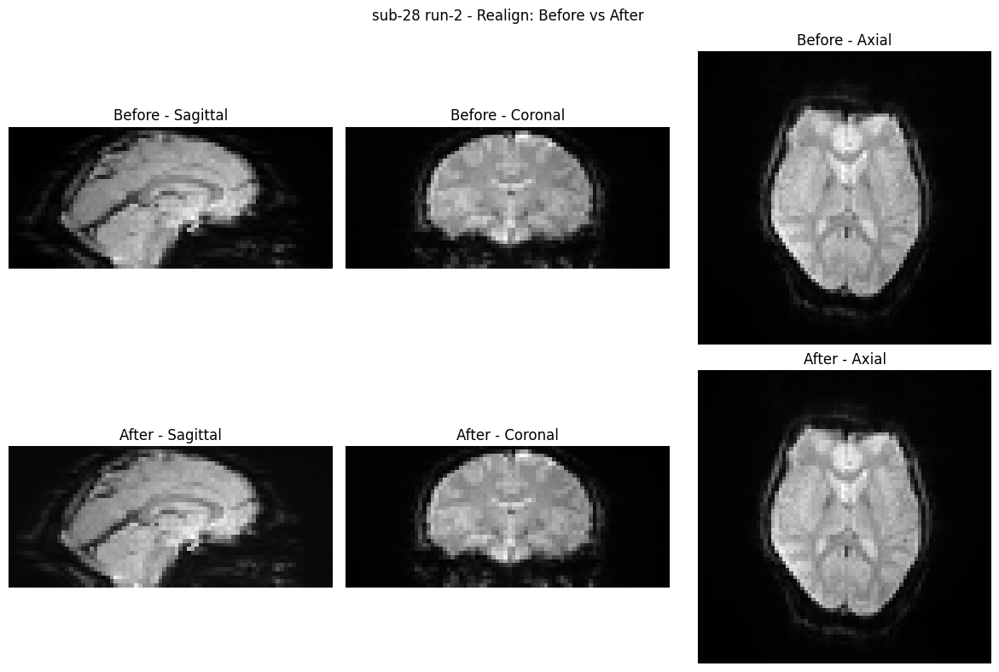

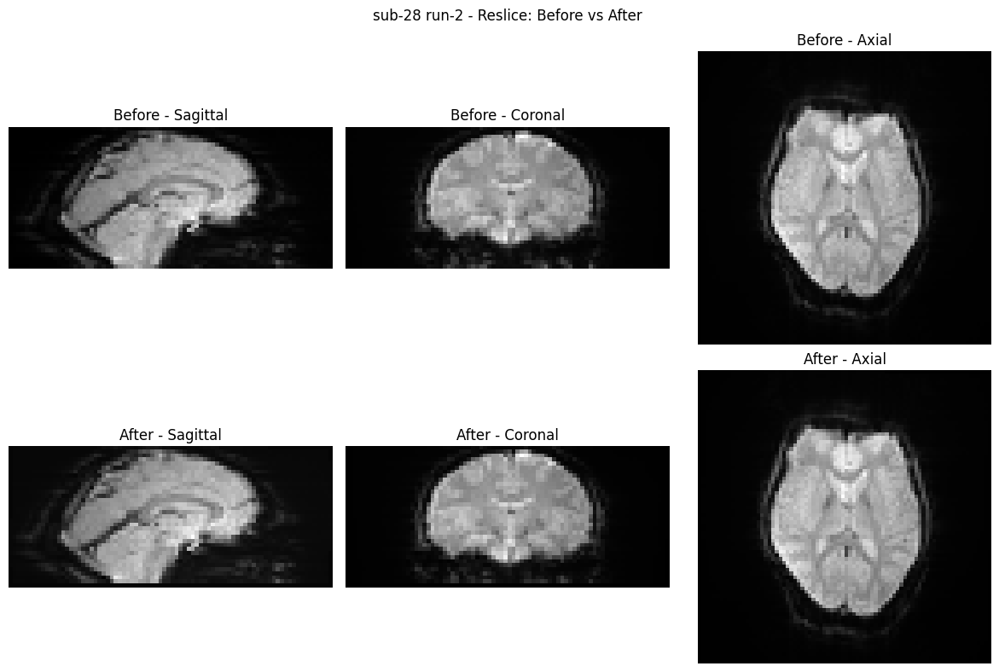

[57/66] sub-29 run-1


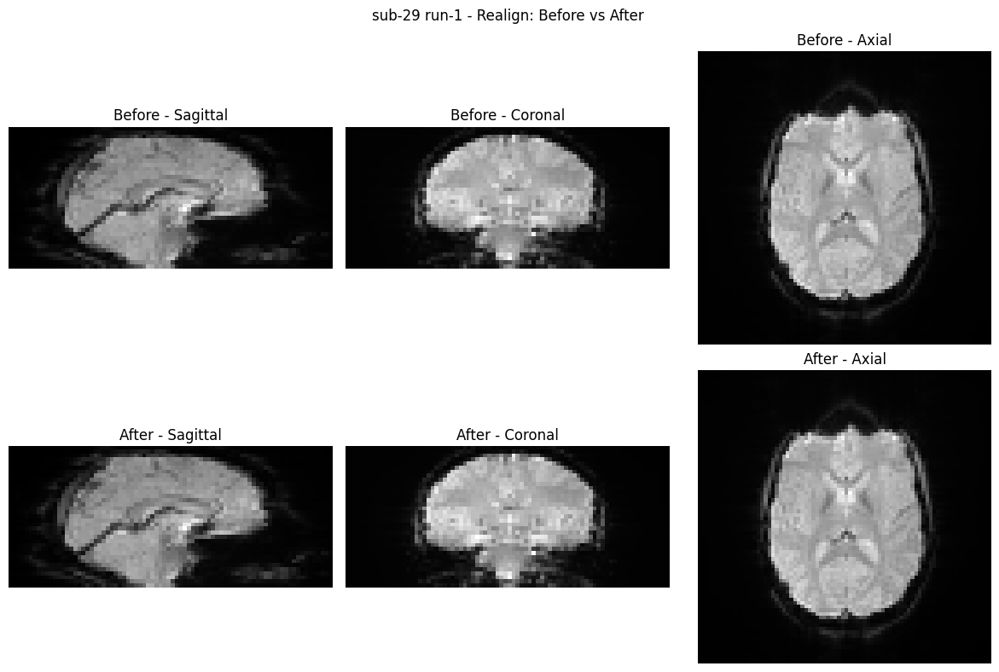

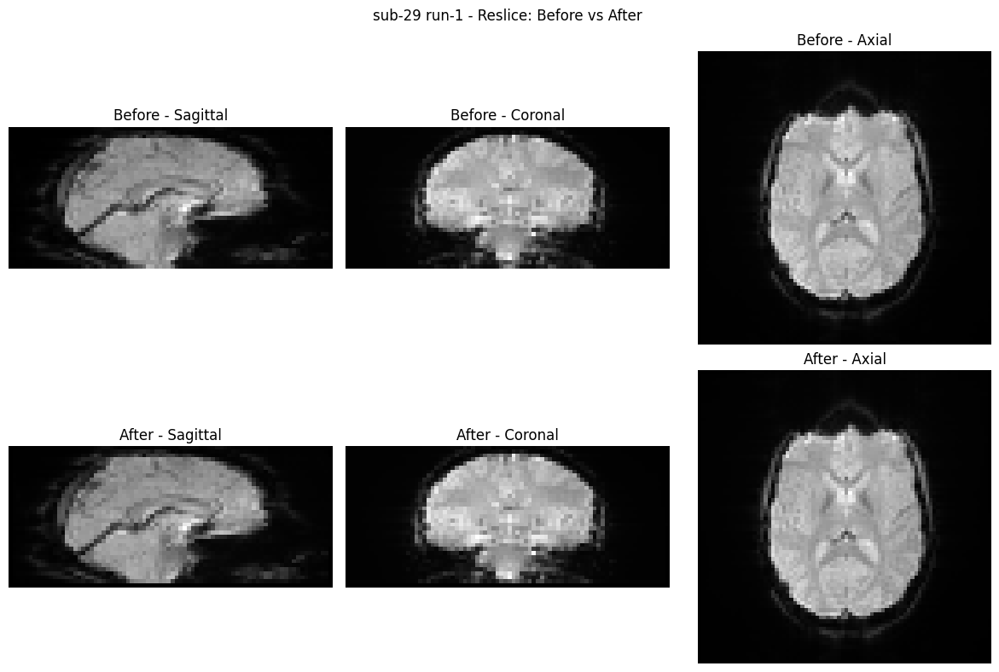

[58/66] sub-29 run-2


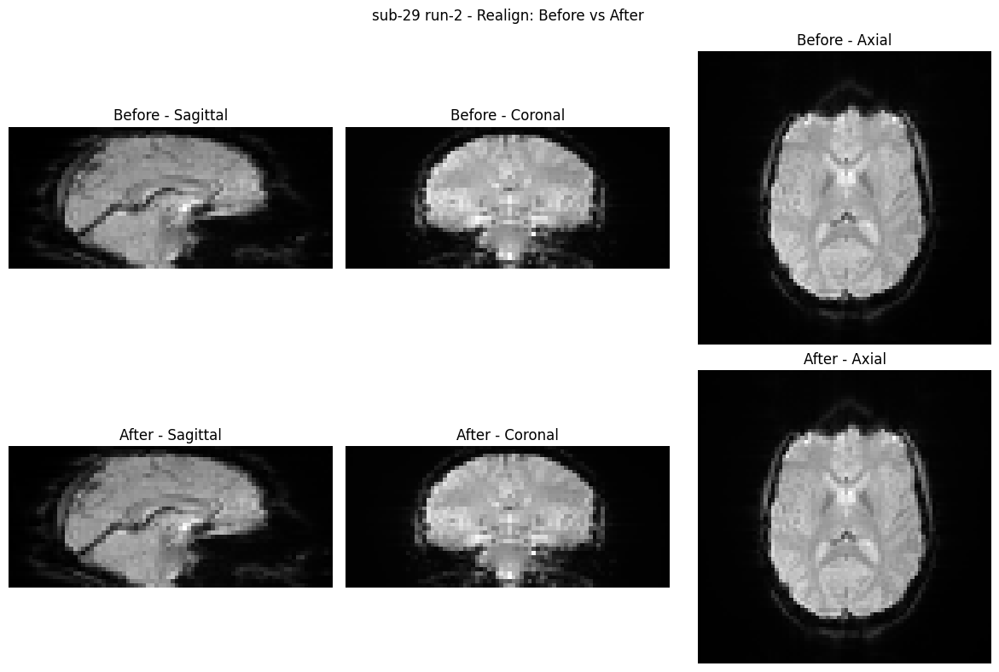

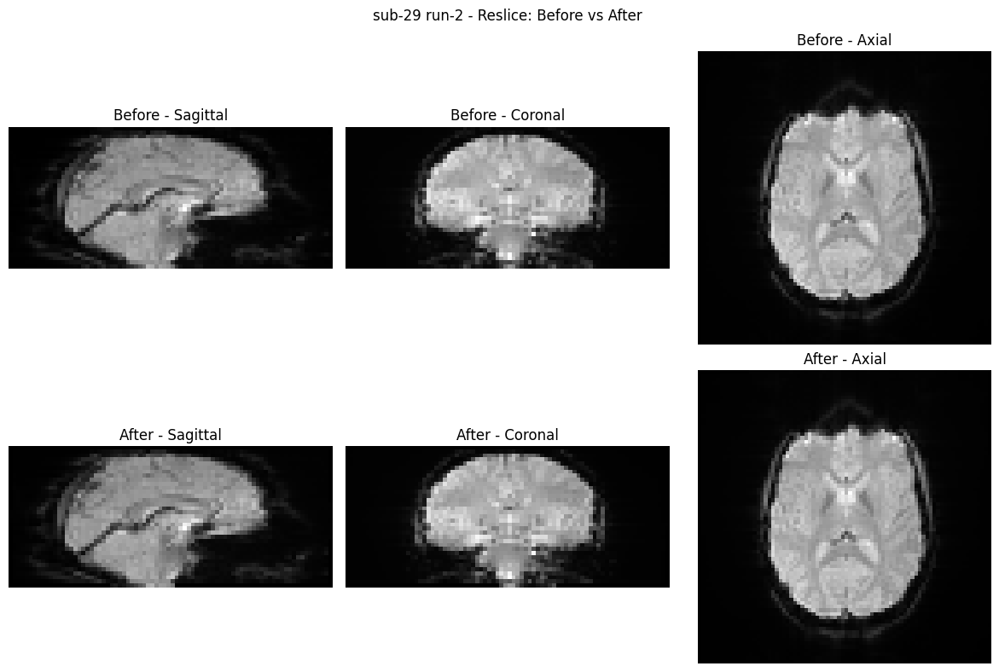

[59/66] sub-30 run-1


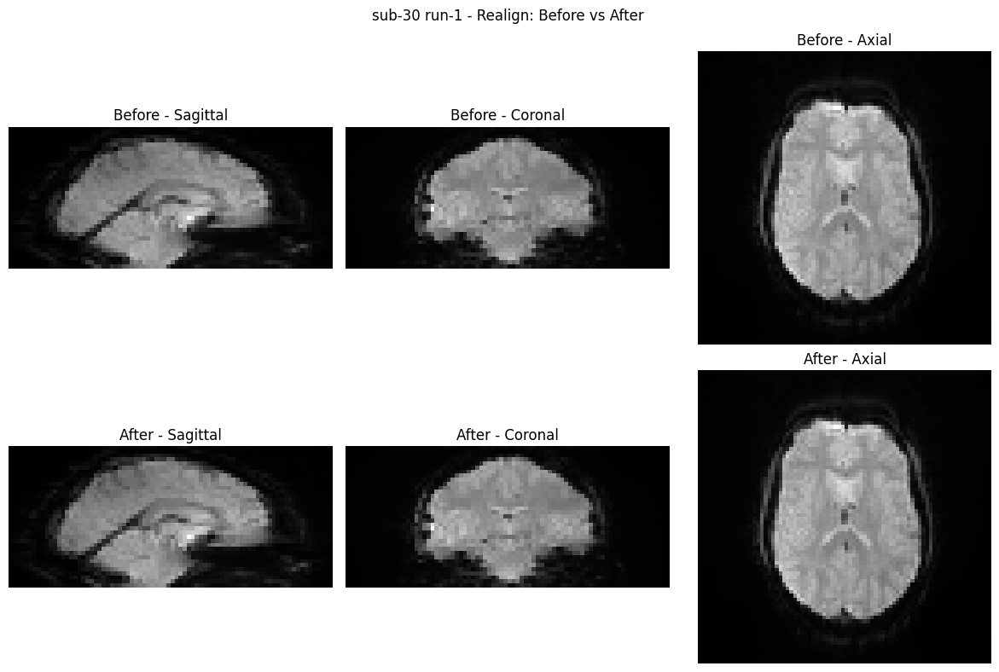

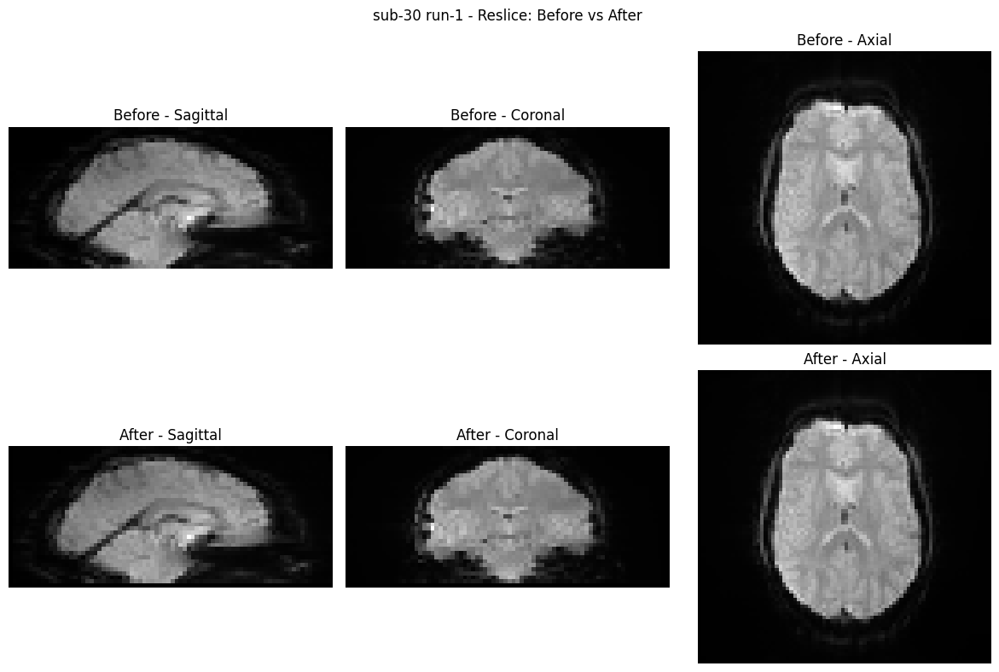

[60/66] sub-30 run-2


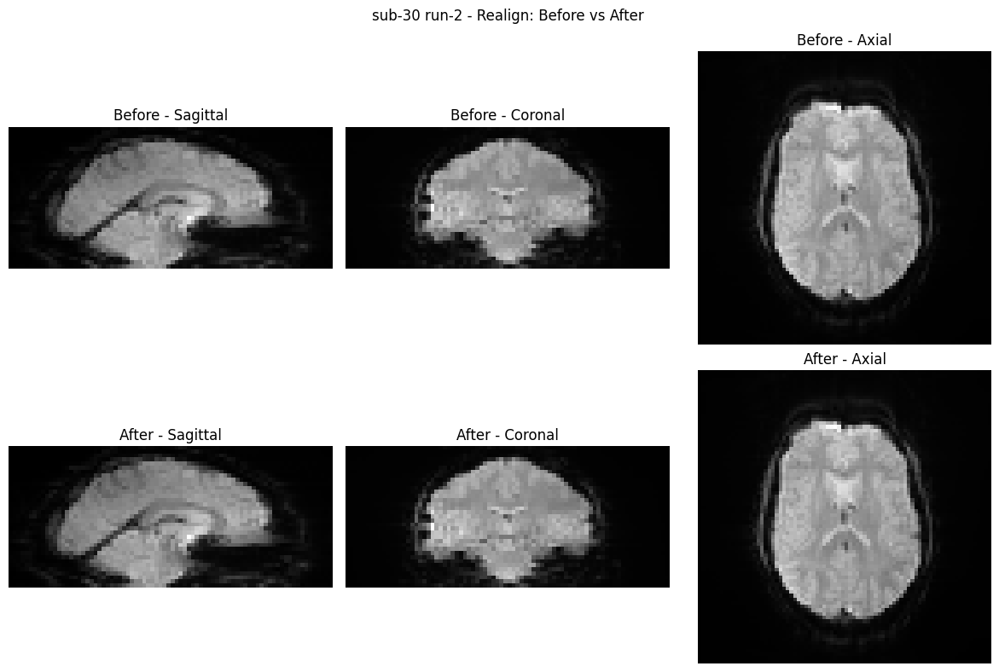

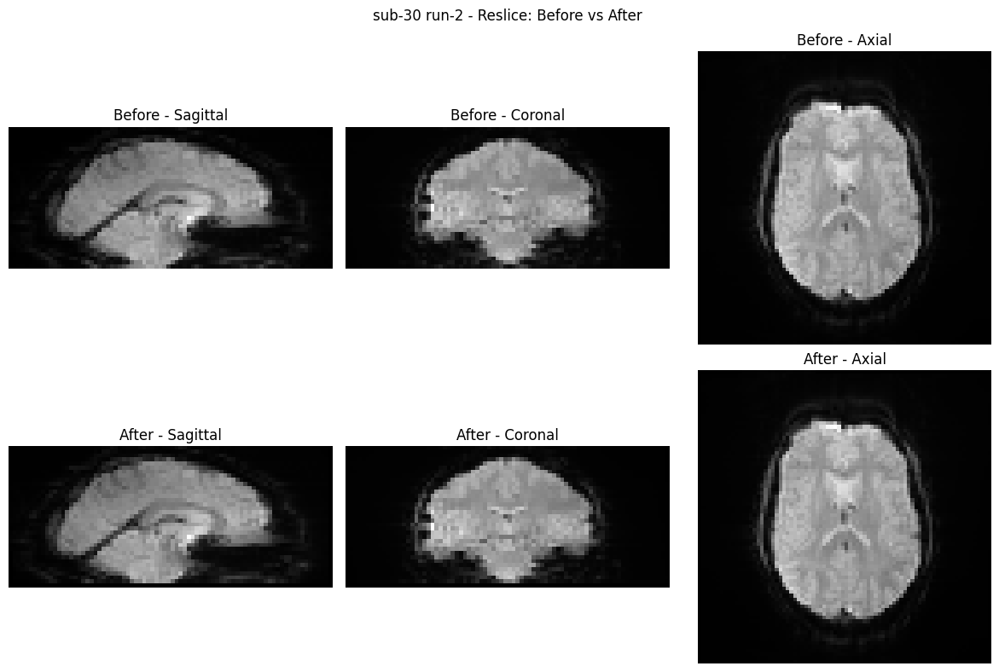

[61/66] sub-31 run-1


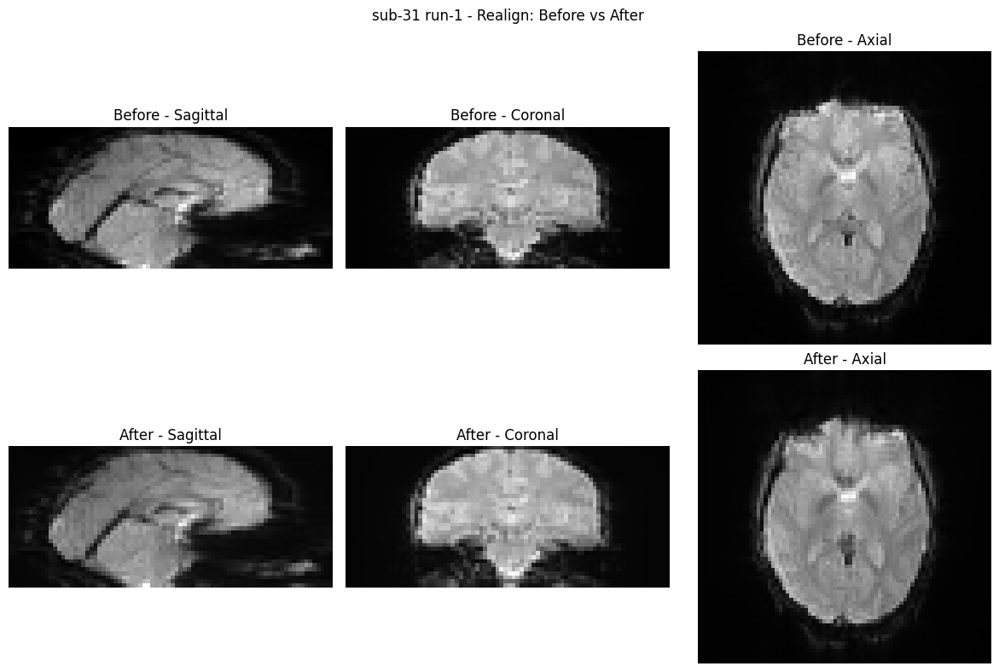

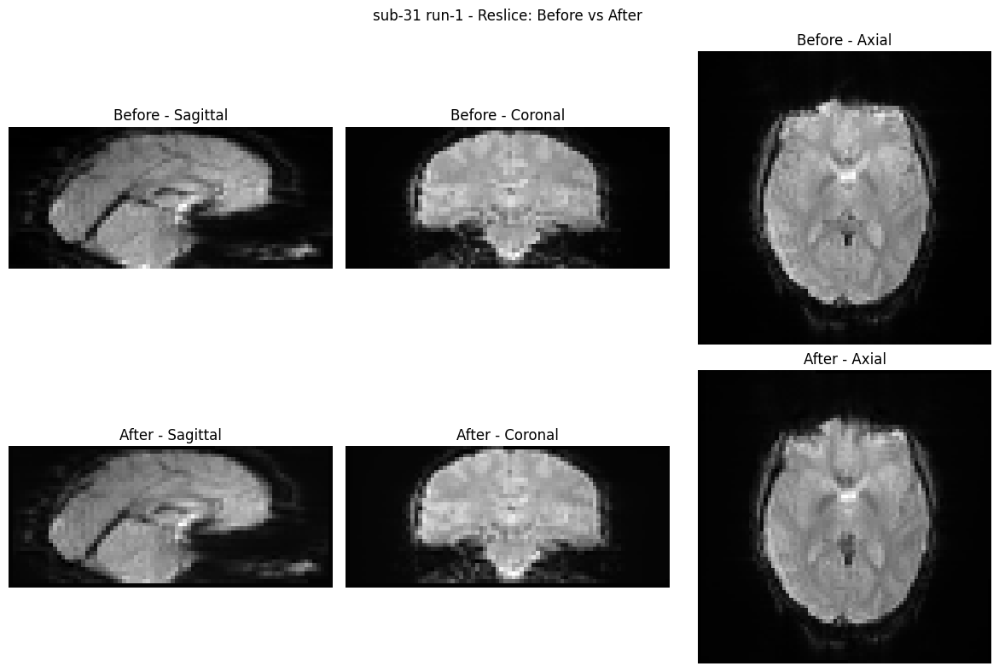

[62/66] sub-31 run-2


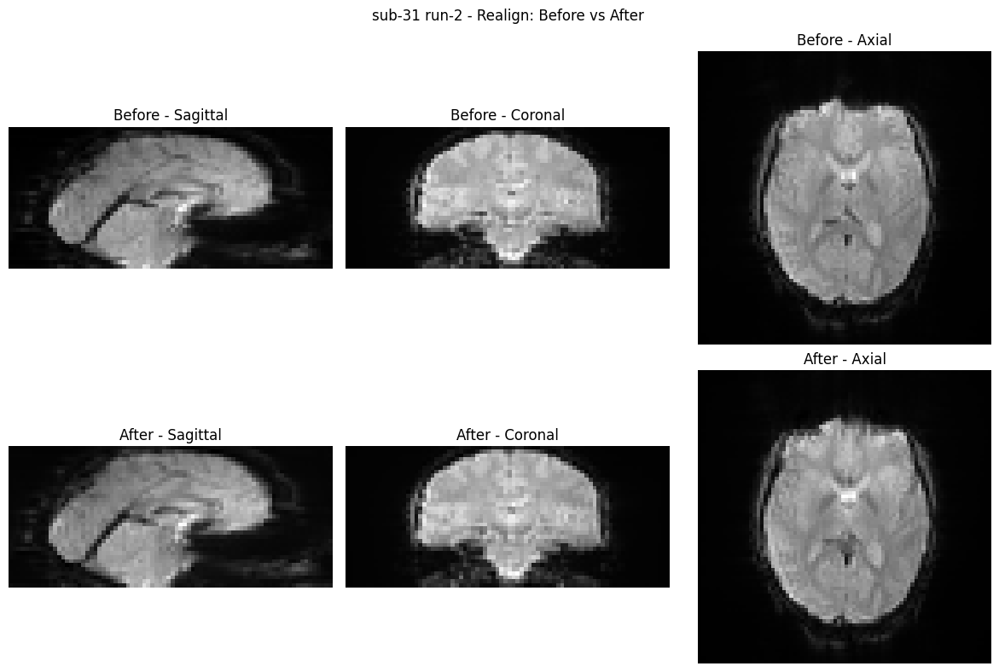

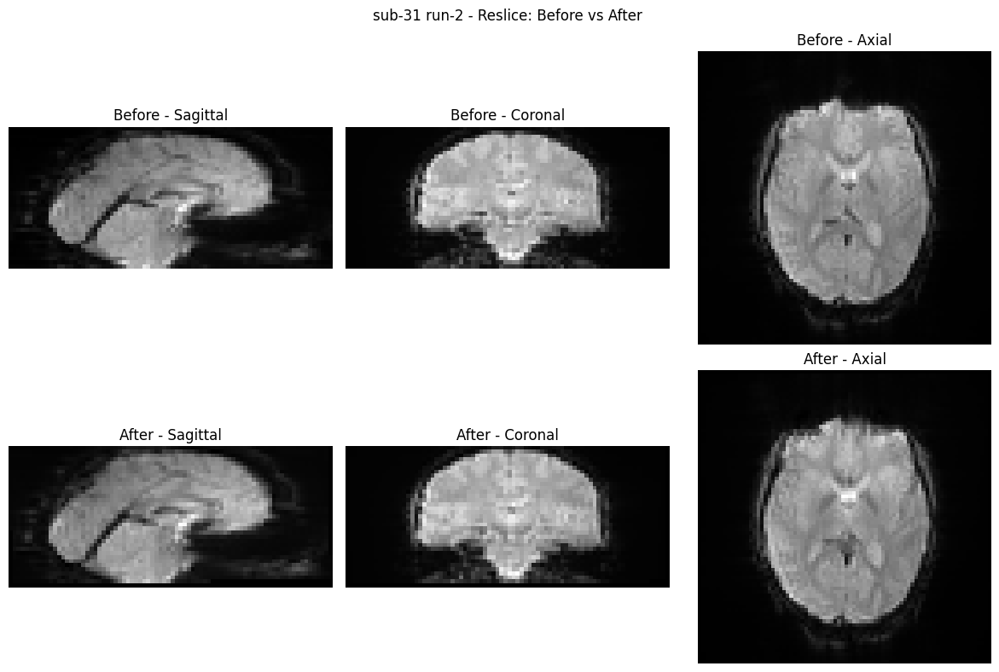

[63/66] sub-32 run-1


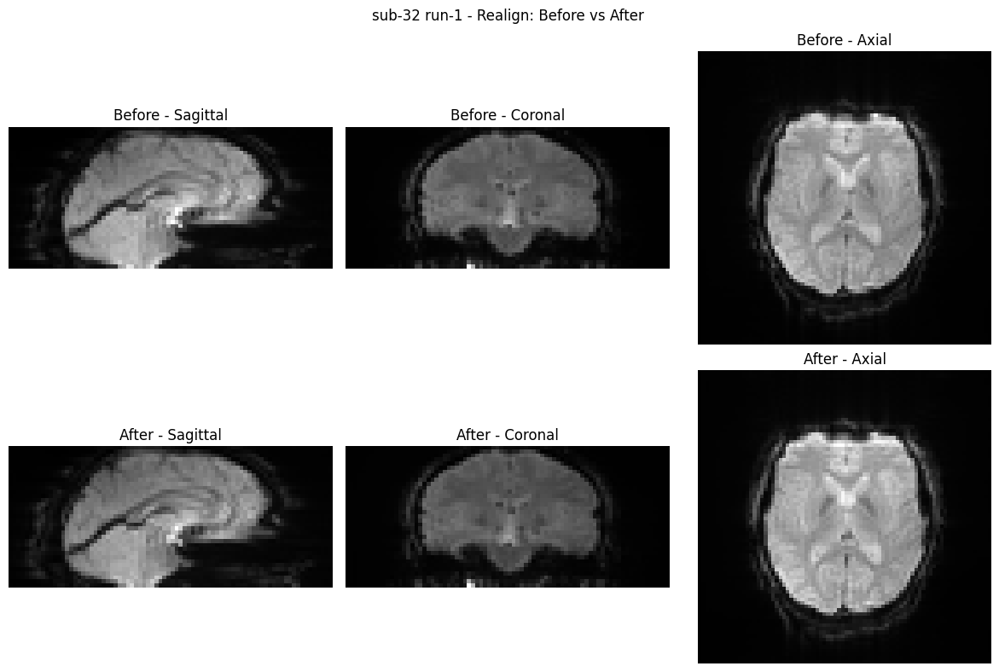

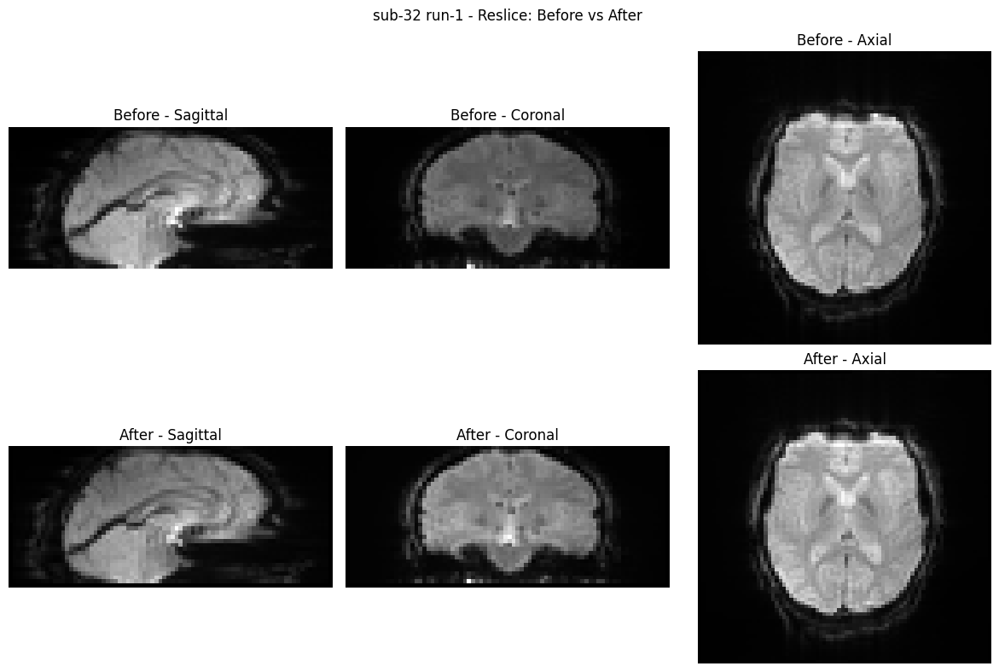

[64/66] sub-32 run-2


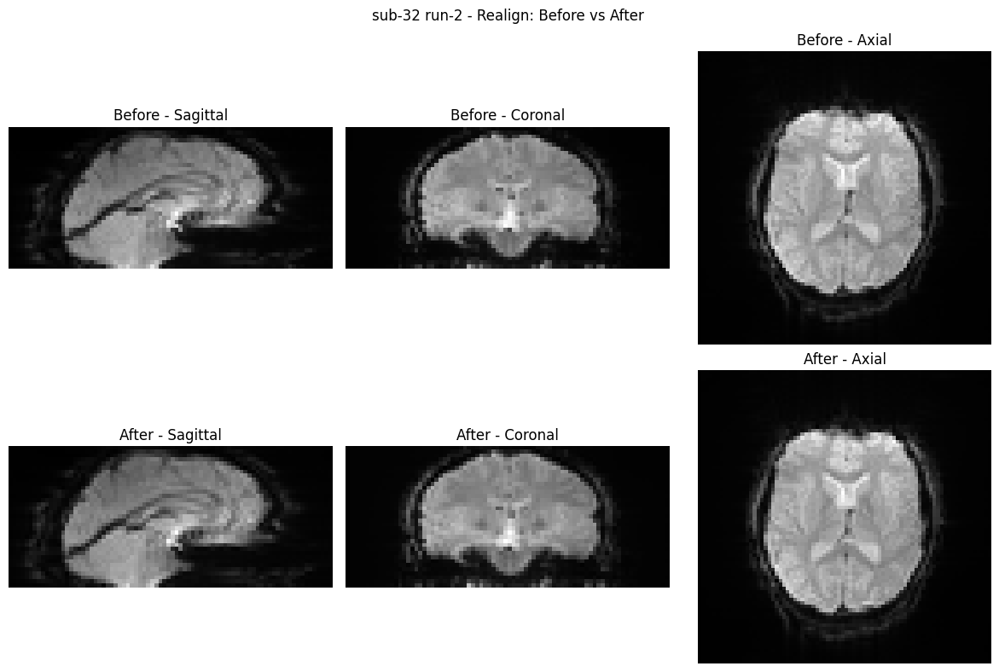

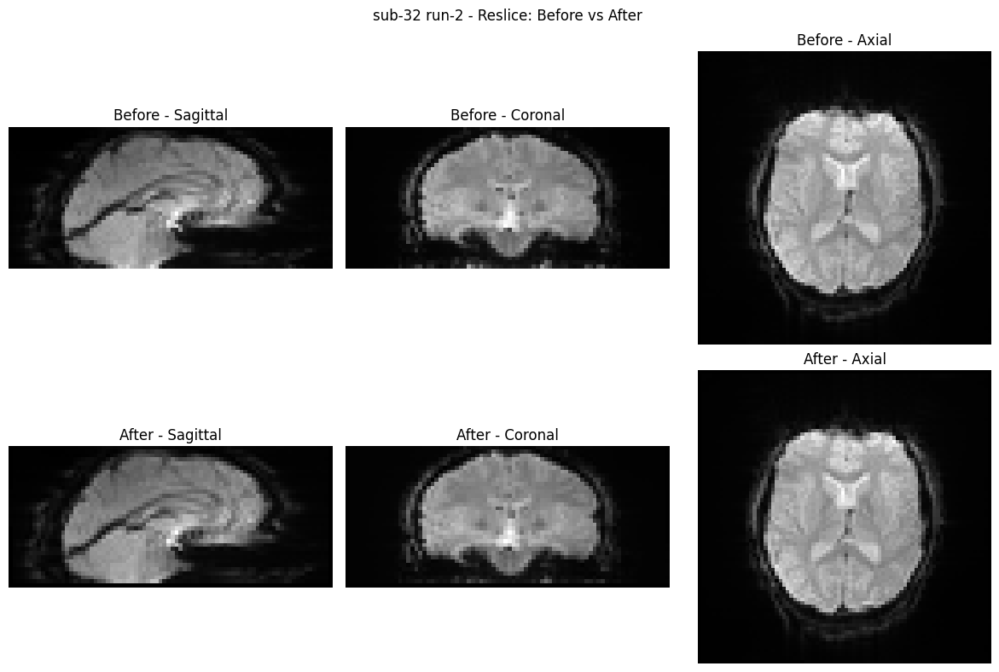

[65/66] sub-33 run-1


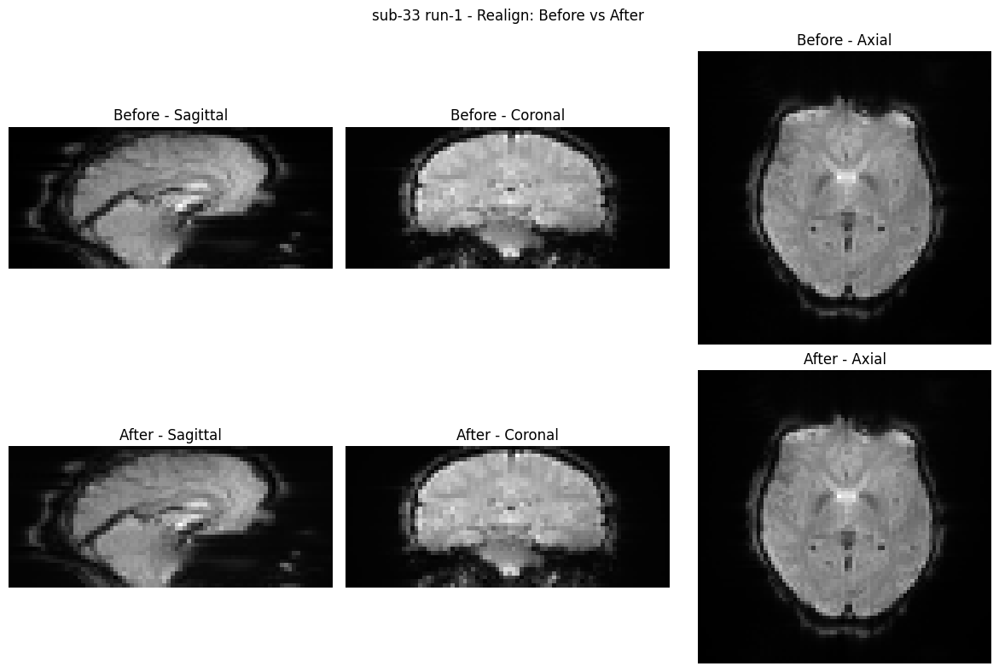

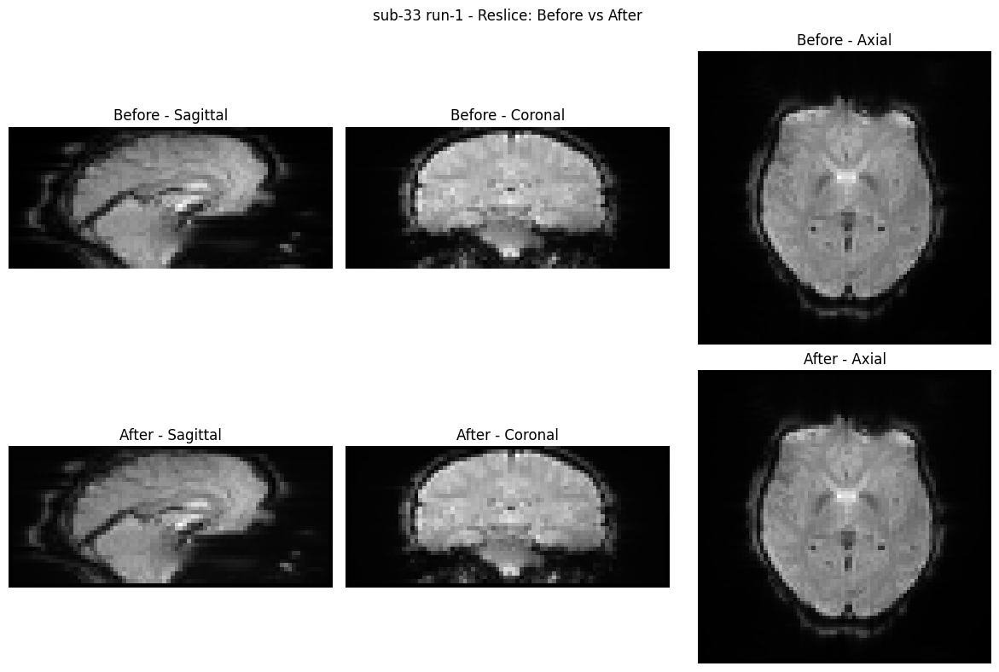

[66/66] sub-33 run-2


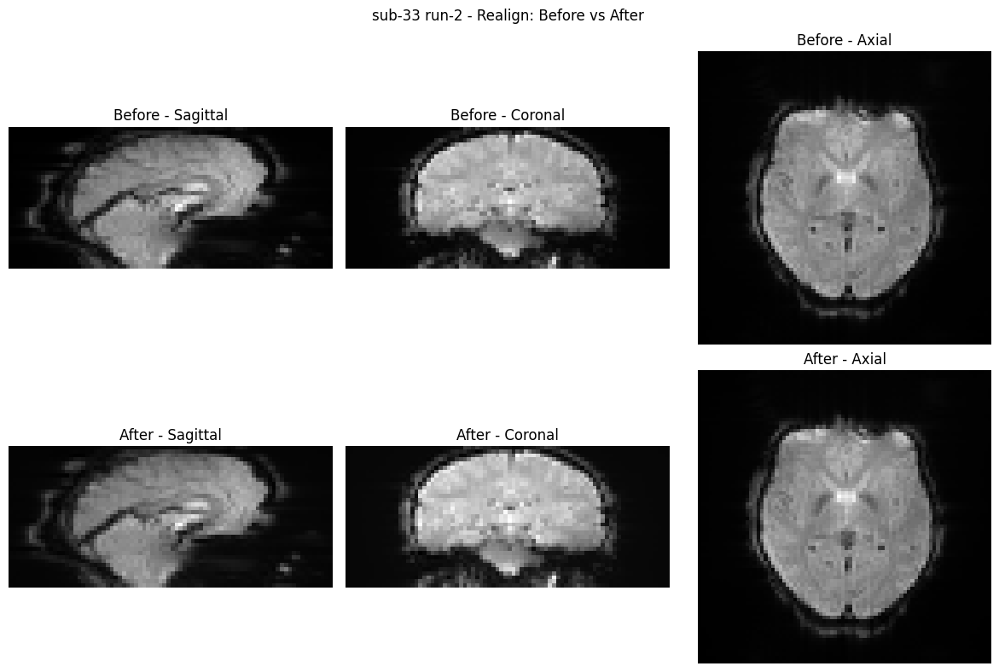

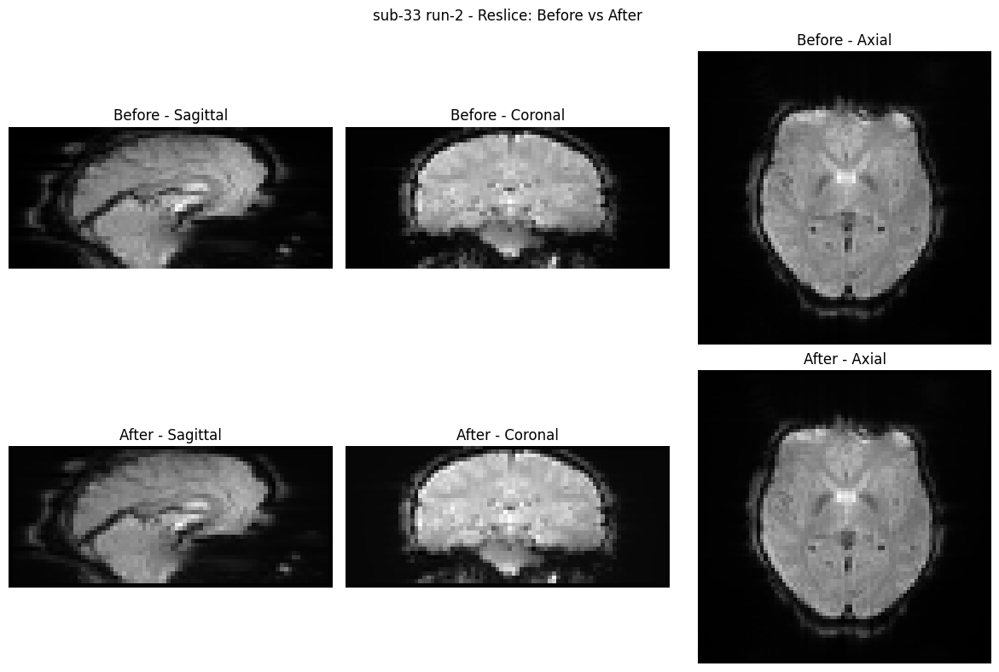

Batch finished.


In [17]:
# Execute to all

batch_results = []

for i, spec in enumerate(all_run_specs, start=1):
    print(f"[{i}/{len(all_run_specs)}] {spec['subject']} {spec['run']}")

    cleanup_spm_run_outputs(spec)

    res = run_spm_realign_trial(
        spec,
        execute=True,
        show_qc=False
    )
    batch_results.append(res)

print("Batch finished.")

In [18]:
batch_summary_rows = []

for res in batch_results:
    gf = res.get("generated_files", {})
    batch_summary_rows.append({
        "subject": res["subject"],
        "run": res["run"],
        "success": res["success"],
        "error": res["error"],
        "n_realigned_files": len(gf.get("realigned_files", [])),
        "n_mean_files": len(gf.get("mean_files", [])),
        "n_motion_txt": len(gf.get("motion_files_txt", [])),
        "motion_n_rows": gf.get("motion_n_rows", None),
        "standard_preproc_bold": gf.get("standard_preproc_bold", None),
        "standard_motion_tsv": gf.get("standard_motion_tsv", None),
        "motion_error": gf.get("motion_error", None),
    })

df_batch_summary = pd.DataFrame(batch_summary_rows)
print(df_batch_summary["success"].value_counts(dropna=False))
df_batch_summary

success
True    66
Name: count, dtype: int64


,subject,run,success,error,n_realigned_files,n_mean_files,n_motion_txt,motion_n_rows,standard_preproc_bold,standard_motion_tsv,motion_error
0,sub-01,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
1,sub-01,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
2,sub-02,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
3,sub-02,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
4,sub-03,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
62,sub-32,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
63,sub-32,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
64,sub-33,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None


In [23]:
# SAVE summary

batch_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_spm_batch_summary.csv"
batch_summary_json = SUMMARY_DIR / f"{WORK_NAME}_spm_batch_summary.json"

df_batch_summary.to_csv(batch_summary_csv, index=False)
save_json(batch_summary_rows, batch_summary_json)

print("Saved:")
print(batch_summary_csv)
print(batch_summary_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_spm_batch_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_spm_batch_summary.json


In [19]:
def compute_fd_power(df_motion, radius_mm=50.0):
    df = df_motion.copy()

    diff = df[["x", "y", "z", "pitch", "roll", "yaw"]].diff().fillna(0.0)

    for col in ["pitch", "roll", "yaw"]:
        diff[col] = diff[col].abs() * radius_mm

    for col in ["x", "y", "z"]:
        diff[col] = diff[col].abs()

    fd = diff.sum(axis=1)
    return fd


motion_summary_rows = []

for spec in all_run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])

    row = {
        "subject": spec["subject"],
        "run": spec["run"],
        "motion_tsv_exists": motion_tsv.exists(),
        "n_frames": None,
        "mean_FD": None,
        "max_FD": None,
        "n_FD_gt_0p2": None,
        "n_FD_gt_0p5": None,
        "max_abs_x": None,
        "max_abs_y": None,
        "max_abs_z": None,
        "max_abs_pitch": None,
        "max_abs_roll": None,
        "max_abs_yaw": None,
    }

    if motion_tsv.exists():
        try:
            df_mot = pd.read_csv(motion_tsv, sep="\t")
            fd = compute_fd_power(df_mot, radius_mm=50.0)

            row.update({
                "n_frames": len(df_mot),
                "mean_FD": float(fd.mean()),
                "max_FD": float(fd.max()),
                "n_FD_gt_0p2": int((fd > 0.2).sum()),
                "n_FD_gt_0p5": int((fd > 0.5).sum()),
                "max_abs_x": float(df_mot["x"].abs().max()),
                "max_abs_y": float(df_mot["y"].abs().max()),
                "max_abs_z": float(df_mot["z"].abs().max()),
                "max_abs_pitch": float(df_mot["pitch"].abs().max()),
                "max_abs_roll": float(df_mot["roll"].abs().max()),
                "max_abs_yaw": float(df_mot["yaw"].abs().max()),
            })
        except Exception as e:
            row["motion_tsv_exists"] = False
            row["read_error"] = str(e)

    motion_summary_rows.append(row)

df_motion_summary = pd.DataFrame(motion_summary_rows)
df_motion_summary

,subject,run,motion_tsv_exists,n_frames,mean_FD,max_FD,n_FD_gt_0p2,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw
0,sub-01,run-1,True,286,0.270301,0.823456,209,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788
1,sub-01,run-2,True,286,0.200071,3.836198,51,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348
2,sub-02,run-1,True,286,0.182337,1.773464,95,4,0.165343,0.551039,1.178026,0.036197,0.007126,0.003837
3,sub-02,run-2,True,286,0.183456,1.173806,73,13,0.146116,0.759470,1.052190,0.019610,0.009226,0.003481
4,sub-03,run-1,True,286,0.319696,1.377659,219,32,0.250564,0.170511,1.024869,0.007306,0.004028,0.004087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,286,0.237863,1.460603,133,14,0.388722,0.369668,3.368110,0.025920,0.009904,0.007992
62,sub-32,run-1,True,286,0.196502,0.852739,110,3,0.551900,0.209701,3.083554,0.006192,0.005226,0.014027
63,sub-32,run-2,True,286,0.189073,2.300308,82,3,0.399291,0.685550,2.107782,0.016410,0.006946,0.002689
64,sub-33,run-1,True,286,0.144998,1.183601,46,4,0.201753,0.427255,1.353460,0.010215,0.004184,0.003021


In [24]:
# SAVE summary
motion_summary_csv = SUMMARY_DIR / f"{WORK_NAME}_motion_summary.csv"
motion_summary_json = SUMMARY_DIR / f"{WORK_NAME}_motion_summary.json"

df_motion_summary.to_csv(motion_summary_csv, index=False)
save_json(motion_summary_rows, motion_summary_json)

print("Saved:")
print(motion_summary_csv)
print(motion_summary_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_motion_summary.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/summary/M01_ds003768_motion_summary.json


In [22]:
print("Batch success rate:")
print(df_batch_summary["success"].value_counts(dropna=False))

print("\nMotion summary availability:")
print(df_motion_summary["motion_tsv_exists"].value_counts(dropna=False))

print("\nRows with failed batch:")
display(df_batch_summary.loc[~df_batch_summary["success"]])

print("\nRows with missing/failed motion summary:")
display(df_motion_summary.loc[~df_motion_summary["motion_tsv_exists"]])

Batch success rate:
success
True    66
Name: count, dtype: int64

Motion summary availability:
motion_tsv_exists
True    66
Name: count, dtype: int64

Rows with failed batch:


,subject,run,success,error,n_realigned_files,n_mean_files,n_motion_txt,motion_n_rows,standard_preproc_bold,standard_motion_tsv,motion_error



Rows with missing/failed motion summary:


,subject,run,motion_tsv_exists,n_frames,mean_FD,max_FD,n_FD_gt_0p2,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw


In [ ]:
# For Manifest processing below

In [25]:
# Manifest for Rapidtide

df_ready = df_batch_summary.loc[
    df_batch_summary["success"] &
    df_batch_summary["standard_preproc_bold"].notna() &
    df_batch_summary["standard_motion_tsv"].notna()
].copy()

ready_manifest_csv = MANIFEST_DIR / f"{WORK_NAME}_ready_for_rapidtide.csv"
df_ready.to_csv(ready_manifest_csv, index=False)

print("Ready-for-rapidtide runs:", len(df_ready))
print(ready_manifest_csv)
df_ready

Ready-for-rapidtide runs: 66
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_ready_for_rapidtide.csv


,subject,run,success,error,n_realigned_files,n_mean_files,n_motion_txt,motion_n_rows,standard_preproc_bold,standard_motion_tsv,motion_error
0,sub-01,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
1,sub-01,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
2,sub-02,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
3,sub-02,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
4,sub-03,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
62,sub-32,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
63,sub-32,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None
64,sub-33,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None


In [26]:
# add(IMG summary)

spec_rows = []

for spec in all_run_specs:
    spec_rows.append({
        "subject": spec["subject"],
        "run": spec["run"],
        "TR": spec["inputs"]["TR"],
        "bold_input": spec["inputs"]["bold_nii"],
        "motion_tsv_from_spec": spec["outputs"]["spm_motion_tsv"],
        "preproc_bold_from_spec": spec["outputs"]["spm_preproc_bold"],
        "rapidtide_run_dir": spec["outputs"]["rapidtide_run_dir"],
        "rapidtide_output_root": spec["outputs"]["rapidtide_output_root"],
        "qc_run_dir": spec["outputs"]["qc_run_dir"],
    })

df_specs_for_merge = pd.DataFrame(spec_rows)

df_ready = df_ready.merge(
    df_specs_for_merge,
    on=["subject", "run"],
    how="left"
)

print(df_ready.shape)
df_ready

(66, 18)


,subject,run,success,error,n_realigned_files,n_mean_files,n_motion_txt,motion_n_rows,standard_preproc_bold,standard_motion_tsv,motion_error,TR,bold_input,motion_tsv_from_spec,preproc_bold_from_spec,rapidtide_run_dir,rapidtide_output_root,qc_run_dir
0,sub-01,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
1,sub-01,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
2,sub-02,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
3,sub-02,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
4,sub-03,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
62,sub-32,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
63,sub-32,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,None,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
64,sub-33,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/

In [27]:
# add(Motion summary)

motion_cols = [
    "subject", "run",
    "n_frames", "mean_FD", "max_FD",
    "n_FD_gt_0p2", "n_FD_gt_0p5",
    "max_abs_x", "max_abs_y", "max_abs_z",
    "max_abs_pitch", "max_abs_roll", "max_abs_yaw"
]
df_ready = df_ready.merge(
    df_motion_summary[motion_cols],
    on=["subject", "run"],
    how="left"
)

print(df_ready.shape)
df_ready

(66, 29)


,subject,run,success,error,n_realigned_files,n_mean_files,n_motion_txt,motion_n_rows,standard_preproc_bold,standard_motion_tsv,...,mean_FD,max_FD,n_FD_gt_0p2,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw
0,sub-01,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.270301,0.823456,209,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788
1,sub-01,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.200071,3.836198,51,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348
2,sub-02,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.182337,1.773464,95,4,0.165343,0.551039,1.178026,0.036197,0.007126,0.003837
3,sub-02,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.183456,1.173806,73,13,0.146116,0.759470,1.052190,0.019610,0.009226,0.003481
4,sub-03,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.319696,1.377659,219,32,0.250564,0.170511,1.024869,0.007306,0.004028,0.004087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.237863,1.460603,133,14,0.388722,0.369668,3.368110,0.025920,0.009904,0.007992
62,sub-32,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.196502,0.852739,110,3,0.551900,0.209701,3.083554,0.006192,0.005226,0.014027
63,sub-32,run-2,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.189073,2.300308,82,3,0.399291,0.685550,2.107782,0.016410,0.006946,0.002689
64,sub-33,run-1,True,None,286,1,1,286,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,...,0.144998,1.183601,46,4,0.201753,0.427255,1.353460,0.010215,0.004184,0.003021


In [28]:
# Final summary for Rapidtide processing

df_rapidtide_manifest = df_ready[[
    "subject",
    "run",
    "TR",
    "standard_preproc_bold",
    "standard_motion_tsv",
    "rapidtide_run_dir",
    "rapidtide_output_root",
    "qc_run_dir",
    "mean_FD",
    "max_FD",
    "n_FD_gt_0p2",
    "n_FD_gt_0p5",
    "max_abs_x",
    "max_abs_y",
    "max_abs_z",
    "max_abs_pitch",
    "max_abs_roll",
    "max_abs_yaw",
]].copy()

df_rapidtide_manifest = df_rapidtide_manifest.rename(columns={
    "standard_preproc_bold": "preproc_bold",
    "standard_motion_tsv": "motion_tsv",
})

df_rapidtide_manifest = df_rapidtide_manifest.sort_values(
    ["subject", "run"]
).reset_index(drop=True)

print(df_rapidtide_manifest.shape)
df_rapidtide_manifest

(66, 18)


,subject,run,TR,preproc_bold,motion_tsv,rapidtide_run_dir,rapidtide_output_root,qc_run_dir,mean_FD,max_FD,n_FD_gt_0p2,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.270301,0.823456,209,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.200071,3.836198,51,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.182337,1.773464,95,4,0.165343,0.551039,1.178026,0.036197,0.007126,0.003837
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.183456,1.173806,73,13,0.146116,0.759470,1.052190,0.019610,0.009226,0.003481
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.319696,1.377659,219,32,0.250564,0.170511,1.024869,0.007306,0.004028,0.004087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.237863,1.460603,133,14,0.388722,0.369668,3.368110,0.025920,0.009904,0.007992
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.196502,0.852739,110,3,0.551900,0.209701,3.083554,0.006192,0.005226,0.014027
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.189073,2.300308,82,3,0.399291,0.685550,2.107782,0.016410,0.006946,0.002689
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.144998,1.183601,46,4,0.201753,0.427255,1.353460,0.010215,0.004184,0.003021


In [29]:
df_rapidtide_manifest["preproc_exists"] = df_rapidtide_manifest["preproc_bold"].apply(
    lambda x: Path(x).exists() if pd.notna(x) else False
)
df_rapidtide_manifest["motion_exists"] = df_rapidtide_manifest["motion_tsv"].apply(
    lambda x: Path(x).exists() if pd.notna(x) else False
)
df_rapidtide_manifest["rapidtide_dir_exists"] = df_rapidtide_manifest["rapidtide_run_dir"].apply(
    lambda x: Path(x).exists() if pd.notna(x) else False
)

print(df_rapidtide_manifest[["preproc_exists", "motion_exists", "rapidtide_dir_exists"]].sum())
df_rapidtide_manifest

preproc_exists          66
motion_exists           66
rapidtide_dir_exists    66
dtype: int64


,subject,run,TR,preproc_bold,motion_tsv,rapidtide_run_dir,rapidtide_output_root,qc_run_dir,mean_FD,max_FD,...,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw,preproc_exists,motion_exists,rapidtide_dir_exists
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.270301,0.823456,...,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788,True,True,True
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.200071,3.836198,...,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348,True,True,True
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.182337,1.773464,...,4,0.165343,0.551039,1.178026,0.036197,0.007126,0.003837,True,True,True
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.183456,1.173806,...,13,0.146116,0.759470,1.052190,0.019610,0.009226,0.003481,True,True,True
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.319696,1.377659,...,32,0.250564,0.170511,1.024869,0.007306,0.004028,0.004087,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.237863,1.460603,...,14,0.388722,0.369668,3.368110,0.025920,0.009904,0.007992,True,True,True
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.196502,0.852739,...,3,0.551900,0.209701,3.083554,0.006192,0.005226,0.014027,True,True,True
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.189073,2.300308,...,3,0.399291,0.685550,2.107782,0.016410,0.006946,0.002689,True,True,True
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.144998,1.183601,...,4,0.201753,0.427255,1.353460,0.010215,0.004184,0.003021,True,True,True


In [30]:
# SAVE manifest (.csv / .json)

rapidtide_manifest_csv = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_input_manifest.csv"
rapidtide_manifest_json = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_input_manifest.json"
df_rapidtide_manifest.to_csv(rapidtide_manifest_csv, index=False)
save_json(df_rapidtide_manifest.to_dict(orient="records"), rapidtide_manifest_json)

print("Saved:")
print(rapidtide_manifest_csv)
print(rapidtide_manifest_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_input_manifest.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_input_manifest.json


In [32]:
df_pilot_candidates = df_rapidtide_manifest.sort_values(
    ["mean_FD", "max_FD", "subject", "run"]).reset_index(drop=True)
print("Top pilot candidates:")
print(df_pilot_candidates[["subject", "run", "mean_FD", "max_FD", "preproc_bold"]])
print()
print()
print("Total rapidtide-ready runs:", len(df_rapidtide_manifest))
print("\nColumns:")
print(df_rapidtide_manifest.columns.tolist())
print("\nFirst few rows:")
df_rapidtide_manifest

Top pilot candidates:
   subject    run   mean_FD     max_FD  \
0   sub-11  run-2  0.111118   0.280716   
1   sub-11  run-1  0.114526   1.578257   
2   sub-04  run-1  0.118638   0.602325   
3   sub-25  run-1  0.131882   0.536962   
4   sub-18  run-2  0.132323   1.106845   
..     ...    ...       ...        ...   
61  sub-07  run-2  0.388598   3.562031   
62  sub-07  run-1  0.410960   3.855432   
63  sub-16  run-1  0.461773   8.972761   
64  sub-14  run-2  0.477189   2.548699   
65  sub-09  run-2  0.782572  25.953244   

                                         preproc_bold  
0   /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
1   /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
2   /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
3   /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
4   /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
..                                                ...  
61  /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...  
62  /media/bami/JHA/rsCVR

,subject,run,TR,preproc_bold,motion_tsv,rapidtide_run_dir,rapidtide_output_root,qc_run_dir,mean_FD,max_FD,...,n_FD_gt_0p5,max_abs_x,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw,preproc_exists,motion_exists,rapidtide_dir_exists
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.270301,0.823456,...,4,0.206459,0.317401,0.321533,0.014581,0.016473,0.002788,True,True,True
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.200071,3.836198,...,17,0.630594,2.381688,0.783364,0.015926,0.020389,0.010348,True,True,True
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.182337,1.773464,...,4,0.165343,0.551039,1.178026,0.036197,0.007126,0.003837,True,True,True
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.183456,1.173806,...,13,0.146116,0.759470,1.052190,0.019610,0.009226,0.003481,True,True,True
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.319696,1.377659,...,32,0.250564,0.170511,1.024869,0.007306,0.004028,0.004087,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.237863,1.460603,...,14,0.388722,0.369668,3.368110,0.025920,0.009904,0.007992,True,True,True
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.196502,0.852739,...,3,0.551900,0.209701,3.083554,0.006192,0.005226,0.014027,True,True,True
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.189073,2.300308,...,3,0.399291,0.685550,2.107782,0.016410,0.006946,0.002689,True,True,True
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.144998,1.183601,...,4,0.201753,0.427255,1.353460,0.010215,0.004184,0.003021,True,True,True


In [ ]:
## Detrending / Low-pass filtering

In [36]:
def detrend_and_lowpass_4d_nifti(in_file, out_file, tr
                                 , lowpass_hz=0.1164
                                 , detrend_type="linear"):
    in_file = Path(in_file)
    out_file = Path(out_file)

    img = nib.load(str(in_file))
    data = img.get_fdata(dtype=np.float32)

    if data.ndim != 4:
        raise ValueError(f"Expected 4D BOLD, got shape={data.shape}")

    nx, ny, nz, nt = data.shape
    data2d = data.reshape(-1, nt)

    # 1) linear detrending
    data2d = signal.detrend(data2d, axis=1, type=detrend_type)

    # 2) low-pass filtering
    fs = 1.0 / tr
    nyq = fs / 2.0
    wn = lowpass_hz / nyq

    if wn >= 1.0:
        raise ValueError(f"Invalid cutoff. lowpass_hz={lowpass_hz}, nyquist={nyq}")

    b, a = signal.butter(N=4, Wn=wn, btype="low")
    data2d = signal.filtfilt(b, a, data2d, axis=1)

    data_filt = data2d.reshape(nx, ny, nz, nt)

    out_img = nib.Nifti1Image(data_filt, img.affine, img.header)
    nib.save(out_img, str(out_file))
    return str(out_file)



filtered_rows = []

for spec in all_run_specs:
    subject = spec["subject"]
    run = spec["run"]
    tr = float(spec["inputs"]["TR"])

    in_file = Path(spec["outputs"]["spm_preproc_bold"])
    out_file = Path(spec["outputs"]["spm_run_dir"]) / f"{subject}_{run}_preproc_bold_dt_filt.nii.gz"

    row = {
        "subject": subject,
        "run": run,
        "TR": tr,
        "preproc_bold": str(in_file),
        "filtered_bold": str(out_file),
        "input_exists": in_file.exists(),
        "filtered_exists": False,
        "error": None,
    }

    try:
        if not in_file.exists():
            raise FileNotFoundError(f"Missing preproc_bold: {in_file}")

        detrend_and_lowpass_4d_nifti(
            in_file=in_file,
            out_file=out_file,
            tr=tr,
            lowpass_hz=0.1164,
            detrend_type="linear"
        )

        row["filtered_exists"] = out_file.exists()

    except Exception as e:
        row["error"] = str(e)

    filtered_rows.append(row)

df_filtered_bold = pd.DataFrame(filtered_rows)
df_filtered_bold

,subject,run,TR,preproc_bold,filtered_bold,input_exists,filtered_exists,error
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
...,...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True,True,None


In [37]:
print(df_filtered_bold["filtered_exists"].value_counts(dropna=False))
display(df_filtered_bold.loc[~df_filtered_bold["filtered_exists"]])

filtered_exists
True    66
Name: count, dtype: int64


,subject,run,TR,preproc_bold,filtered_bold,input_exists,filtered_exists,error


In [39]:
# Check filtered file shape()
check_rows = []

for spec in all_run_specs[:5]:
    in_file = Path(spec["outputs"]["spm_preproc_bold"])
    out_file = Path(spec["outputs"]["spm_run_dir"]) / f"{spec['subject']}_{spec['run']}_preproc_bold_dt_filt.nii.gz"

    img_in = nib.load(str(in_file))
    img_out = nib.load(str(out_file))

    check_rows.append({
        "subject": spec["subject"],
        "run": spec["run"],
        "in_shape": img_in.shape,
        "out_shape": img_out.shape,
        "same_shape": img_in.shape == img_out.shape,
    })

pd.DataFrame(check_rows)

,subject,run,in_shape,out_shape,same_shape
0,sub-01,run-1,"(80, 80, 35, 286)","(80, 80, 35, 286)",True
1,sub-01,run-2,"(80, 80, 35, 286)","(80, 80, 35, 286)",True
2,sub-02,run-1,"(80, 80, 35, 286)","(80, 80, 35, 286)",True
3,sub-02,run-2,"(80, 80, 35, 286)","(80, 80, 35, 286)",True
4,sub-03,run-1,"(80, 80, 35, 286)","(80, 80, 35, 286)",True


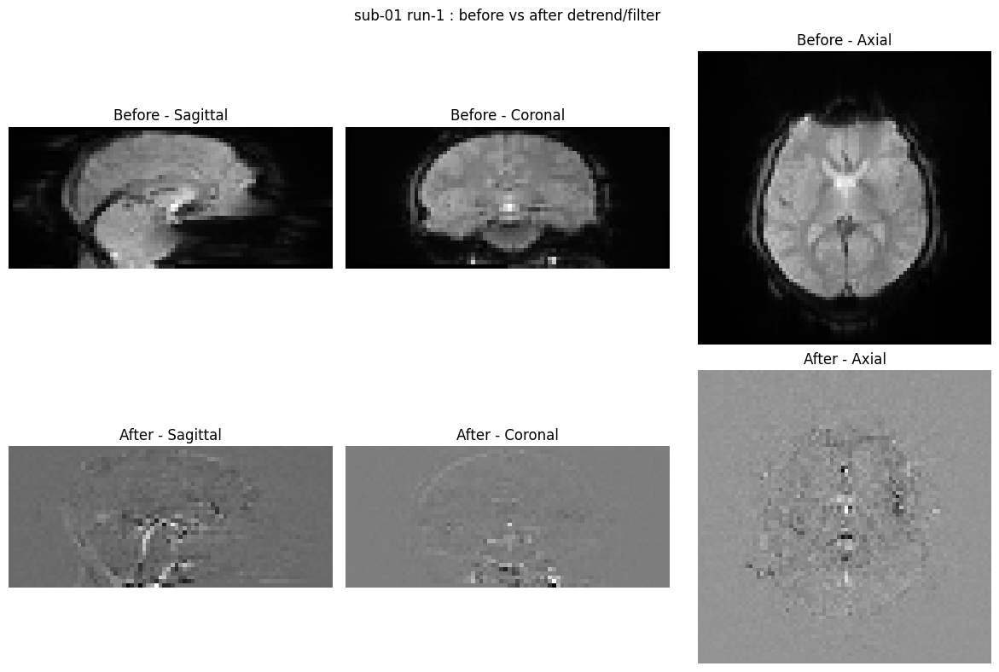

In [40]:
# Check meanBOLD before-after filtering

spec = all_run_specs[0]

in_file = Path(spec["outputs"]["spm_preproc_bold"])
out_file = Path(spec["outputs"]["spm_run_dir"]) / f"{spec['subject']}_{spec['run']}_preproc_bold_dt_filt.nii.gz"

mean_in = Path(spec["outputs"]["spm_run_dir"]) / f"{spec['subject']}_{spec['run']}_mean_preproc_before_dtfilt.nii.gz"
mean_out = Path(spec["outputs"]["spm_run_dir"]) / f"{spec['subject']}_{spec['run']}_mean_preproc_after_dtfilt.nii.gz"

save_mean_bold(in_file, mean_in)
save_mean_bold(out_file, mean_out)

plot_before_after_orthogonal(
    before_img_path=mean_in,
    after_img_path=mean_out,
    title=f"{spec['subject']} {spec['run']} : before vs after detrend/filter"
)

In [41]:
# Attach filtered_bold --to--> rapidtide-ready manifest file

df_rapidtide_manifest = df_rapidtide_manifest.merge(
    df_filtered_bold[["subject", "run", "filtered_bold", "filtered_exists"]],
    on=["subject", "run"],
    how="left"
)

df_rapidtide_manifest["filtered_exists"] = df_rapidtide_manifest["filtered_bold"].apply(
    lambda x: Path(x).exists() if pd.notna(x) else False
)

print(df_rapidtide_manifest["filtered_exists"].value_counts(dropna=False))
df_rapidtide_manifest

filtered_exists
True    66
Name: count, dtype: int64


,subject,run,TR,preproc_bold,motion_tsv,rapidtide_run_dir,rapidtide_output_root,qc_run_dir,mean_FD,max_FD,...,max_abs_y,max_abs_z,max_abs_pitch,max_abs_roll,max_abs_yaw,preproc_exists,motion_exists,rapidtide_dir_exists,filtered_bold,filtered_exists
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.270301,0.823456,...,0.317401,0.321533,0.014581,0.016473,0.002788,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.200071,3.836198,...,2.381688,0.783364,0.015926,0.020389,0.010348,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.182337,1.773464,...,0.551039,1.178026,0.036197,0.007126,0.003837,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.183456,1.173806,...,0.759470,1.052190,0.019610,0.009226,0.003481,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.319696,1.377659,...,0.170511,1.024869,0.007306,0.004028,0.004087,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.237863,1.460603,...,0.369668,3.368110,0.025920,0.009904,0.007992,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.196502,0.852739,...,0.209701,3.083554,0.006192,0.005226,0.014027,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.189073,2.300308,...,0.685550,2.107782,0.016410,0.006946,0.002689,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,0.144998,1.183601,...,0.427255,1.353460,0.010215,0.004184,0.003021,True,True,True,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True


In [42]:
# Save filtered manifest
rapidtide_manifest_filt_csv = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_input_manifest_dt_filt.csv"
rapidtide_manifest_filt_json = MANIFEST_DIR / f"{WORK_NAME}_rapidtide_input_manifest_dt_filt.json"

df_rapidtide_manifest.to_csv(rapidtide_manifest_filt_csv, index=False)
save_json(df_rapidtide_manifest.to_dict(orient="records"), rapidtide_manifest_filt_json)

print("Saved:")
print(rapidtide_manifest_filt_csv)
print(rapidtide_manifest_filt_json)

Saved:
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_input_manifest_dt_filt.csv
/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/manifests/M01_ds003768_rapidtide_input_manifest_dt_filt.json


In [43]:
# Final confirm
print("Total rapidtide-ready runs:", len(df_rapidtide_manifest))

print("\nColumns:")
print(df_rapidtide_manifest.columns.tolist())

print("\nExample rows:")
display(df_rapidtide_manifest[[
    "subject", "run", "TR", "preproc_bold", "filtered_bold",
    "motion_tsv", "filtered_exists"
]])

Total rapidtide-ready runs: 66

Columns:
['subject', 'run', 'TR', 'preproc_bold', 'motion_tsv', 'rapidtide_run_dir', 'rapidtide_output_root', 'qc_run_dir', 'mean_FD', 'max_FD', 'n_FD_gt_0p2', 'n_FD_gt_0p5', 'max_abs_x', 'max_abs_y', 'max_abs_z', 'max_abs_pitch', 'max_abs_roll', 'max_abs_yaw', 'preproc_exists', 'motion_exists', 'rapidtide_dir_exists', 'filtered_bold', 'filtered_exists']

Example rows:


,subject,run,TR,preproc_bold,filtered_bold,motion_tsv,filtered_exists
0,sub-01,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
1,sub-01,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
2,sub-02,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
3,sub-02,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
4,sub-03,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
...,...,...,...,...,...,...,...
61,sub-31,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
62,sub-32,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
63,sub-32,run-2,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
64,sub-33,run-1,2.1,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,True
